# 10 — Vanilla Decision Transformer (kzl gym replicate)

Faithful port of the kzl/decision-transformer **gym** build adapted to the corner-maze yoked dataset. Discrete actions (5: left, right, forward, pickup, pause) → action `Embedding` and CE loss; everything else mirrors the OpenAI Gym MuJoCo version: linear modality embeddings, learned timestep embedding, LayerNorm, GPT2 body with no internal positional embedding, token order `(R, s, a)`.

Reference: https://github.com/kzl/decision-transformer/tree/master/gym

Per-subject training with `N_RUNS` seed replicates per subject. Pretrained on offline yoked data, then evaluated by acting in `CornerMazeEnv` (acquisition sanity-check + probes).

## 0. Colab bootstrap

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ryangrg/corner-maze-rl/blob/main/notebooks/10_vanilla_dt.ipynb)

**Getting started on Colab:**

1. **Click the badge above** to open this notebook in Colab.
2. **Pick a GPU runtime** (training notebooks only): `Runtime → Change runtime type → T4` (free) or `L4` / `A100` (Pro). Required to get the bf16 / `torch.compile` / TF32 speedups; exploration notebooks (01, 02) are fine on CPU.
3. **Drive setup** (one-time, optional but recommended): in My Drive, create a folder called `corner-maze-rl-colab/`. The bootstrap auto-creates `runs/` inside it. Skip this and run artifacts stay ephemeral on the Colab VM disk — download before the runtime disconnects.
4. **Sign into Drive** when prompted by the first run of the bootstrap cell (one click).
5. **Run all** (`Runtime → Run all`). The cell below handles repo clone, package install, Drive mount, and starts a background sync. Nothing else to configure.

---

**How the bootstrap works** (no-op locally; on Colab):

- Clones this repo to `/content/corner-maze-rl` and installs it with `pip install -e .` (deps come from `pyproject.toml`).
- Training writes always go to `data/runs/` on the **Colab VM disk** — a real directory, not a symlink.
- A background daemon thread rsyncs `data/runs/` → `corner-maze-rl-colab/runs/` on Drive every `SYNC_INTERVAL_SEC` seconds (default 120s), plus a final sync on kernel exit.
- If Drive disconnects mid-run, training keeps working. The next sync attempt fails silently and the one after retries. Worst case you lose the last `SYNC_INTERVAL_SEC` seconds of artifacts.

Data inputs (lookups + yoked dataset) come with the cloned repo — no upload required.

**Manual sync any time**: call `sync_runs_to_drive(verbose=True)` from any cell.

In [64]:
# ── Colab bootstrap (no-op locally; local-write + periodic Drive sync) ─
import sys
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    import os, subprocess, threading, atexit
    from pathlib import Path

    # ── Customise for your setup ──────────────────────────────────────
    REPO_URL          = 'https://github.com/ryangrg/corner-maze-rl.git'
    REPO_BRANCH       = 'main'
    REPO_DIR          = Path('/content/corner-maze-rl')
    USE_DRIVE         = True   # set False to skip Drive entirely
    DRIVE_ROOT        = Path('/content/drive/MyDrive/corner-maze-rl-colab')
    SYNC_INTERVAL_SEC = 120    # background rsync cadence
    # ──────────────────────────────────────────────────────────────────

    # 1. Clone repo (brings lookups + yoked dataset; both are committed)
    if not REPO_DIR.exists():
        subprocess.check_call(['git', 'clone', '--depth=1',
                               '-b', REPO_BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f'  repo already at {REPO_DIR}')

    # 2. Install package into the KERNEL's Python (sys.executable, not PATH pip —
    #    on Colab those can differ and PATH-pip installs are invisible to the kernel).
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(REPO_DIR)])

    # 3. Editable installs add a .pth entry, but the kernel's sys.path was built at
    #    startup and doesn't re-scan .pth files. Add the src dir manually so `import
    #    corner_maze_rl` works without a runtime restart.
    src_dir = str(REPO_DIR / 'src')
    if src_dir not in sys.path:
        sys.path.insert(0, src_dir)

    # 4. data/runs is ALWAYS a real local dir on the VM disk — never a symlink.
    #    This keeps writes resilient to mid-run Drive disconnects.
    local_runs = REPO_DIR / 'data' / 'runs'
    local_runs.mkdir(parents=True, exist_ok=True)

    # 5. Try Drive mount; failure just disables sync (training still works).
    drive_runs   = None
    drive_status = 'skipped (USE_DRIVE=False)'
    if USE_DRIVE:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            if not DRIVE_ROOT.exists():
                drive_status = f'mounted, but {DRIVE_ROOT} missing — sync disabled'
            else:
                drive_runs = DRIVE_ROOT / 'runs'
                drive_runs.mkdir(exist_ok=True)
                drive_status = f'mounted at {DRIVE_ROOT}'
        except Exception as e:
            drive_status = f'mount failed ({type(e).__name__}) — sync disabled'

    # 6. Public sync helper — call from any cell with verbose=True for feedback.
    _sync_lock = threading.Lock()

    def sync_runs_to_drive(verbose: bool = False) -> tuple[bool, str]:
        """rsync local data/runs/ → Drive corner-maze-rl-colab/runs/.

        Returns (ok, message). Skips silently if Drive isn't reachable.
        Safe to call concurrently — uses a lock to prevent overlapping rsyncs.
        """
        if drive_runs is None:
            return (False, 'no drive target')
        if not _sync_lock.acquire(blocking=False):
            return (False, 'sync already in flight')
        try:
            result = subprocess.run(
                ['rsync', '-a', '--update',
                 str(local_runs) + '/', str(drive_runs) + '/'],
                capture_output=True, text=True, timeout=300,
            )
            ok  = (result.returncode == 0)
            msg = 'synced' if ok else f'rc={result.returncode}: {result.stderr.strip()[:200]}'
            if verbose:
                print(f'  [drive sync] {msg}')
            return (ok, msg)
        except Exception as e:
            if verbose:
                print(f'  [drive sync] {type(e).__name__}: {e}')
            return (False, f'{type(e).__name__}: {e}')
        finally:
            _sync_lock.release()

    # 7. Background sync — daemon thread, silent. Dies with the kernel.
    _sync_stop = threading.Event()
    def _sync_loop():
        while not _sync_stop.wait(SYNC_INTERVAL_SEC):
            sync_runs_to_drive(verbose=False)

    if drive_runs is not None:
        threading.Thread(target=_sync_loop, daemon=True).start()
        # Final sync on kernel exit so the last cycle's writes catch up.
        atexit.register(lambda: (_sync_stop.set(), sync_runs_to_drive(verbose=True)))
        sync_status = f'active (every {SYNC_INTERVAL_SEC}s + final on exit)'
    else:
        sync_status = 'inactive (runs are EPHEMERAL — download before disconnect)'

    # 8. cd into notebooks/ so REPO_ROOT = Path.cwd().parent resolves
    os.chdir(REPO_DIR / 'notebooks')

    print(f'\n✓ Colab bootstrap complete')
    print(f'  repo:    {REPO_DIR}  (branch={REPO_BRANCH})')
    print(f'  cwd:     {Path.cwd()}')
    print(f'  python:  {sys.executable}')
    print(f'  drive:   {drive_status}')
    print(f'  runs:    {local_runs}  (always local; never a symlink)')
    print(f'  sync:    {sync_status}')
    print(f'\n  manual sync any time: sync_runs_to_drive(verbose=True)')
else:
    print('✓ local environment — bootstrap skipped')


✓ local environment — bootstrap skipped


## 1. Configuration

In [65]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import torch

# ── Experiment identity ─────────────────────────────────────
RUN_NAME         = 'dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5'
EXPERIMENT_NOTES = """
Testing report and scoring changes
"""

# ── Subject / group / session sequence ──────────────────────────
TRAINING_GROUP = 'vc'                          # 'pi' | 'pi_vc' | 'vc'
SUBJECTS       = ['CM044']                     # data sources (≥1 rat); see POOL_SUBJECTS
POOL_SUBJECTS  = False                         # False = N independent models (one per subject)
                                               # True  = ONE model trained on pooled data
# Env paradigm strings for PI probes (see src/corner_maze_rl/env/corner_maze_env.py:1157).
# ── Configuration ──────────────────────────────
# Valid session_type values:
#   'exposure', 'exposure_b',
#   'PI+VC f2 single trial', 'PI+VC f2 acquisition', 'PI+VC f2 novel route',
#   'PI+VC f2 no cue', 'PI+VC f2 rotate', 'PI+VC f2 reversal',
#   'PI+VC f1 acquisition', 'PI+VC f1 novel route', 'PI+VC f1 no cue',
#   'PI+VC f1 rotate', 'PI+VC f1 reversal',
#   'PI acquisition', 'PI novel route no cue', 'PI novel route cue',
#   'PI reversal no cue', 'PI reversal cue',
#   'VC acquisition', 'VC novel route fixed', 'VC novel route rotate',
#   'VC reversal fixed', 'VC reversal rotate'
SESSION_TYPES  = [
    'VC acquisition', 'VC novel route fixed', 'VC novel route rotate',
    'VC reversal fixed', 'VC reversal rotate'
]
ACQ_INFERENCE_TRIALS = 32                      # one full acquisition session (env paradigms use 8-trial chunks;
                                               # PI/PI+VC f2 acq = 4 chunks = 32 trials). 32 trials → meaningful
                                               # distributional comparison vs rat's late-acq baseline.

# ── Seed sweep ────────────────────────────────────────────
N_RUNS = 1                                     # seeds per training unit (smoke=2, iter=10, headline=30)

# ── Reward / cost — LOCKED across train + eval (part of run identity) ──
@dataclass(frozen=True)
class CostConfig:
    terminal_reward: float = 1.0
    step_cost: float       = 0.001
COST = CostConfig()

# ── Inference-only RTG conditioning ───────────────────────────
# EXPECTED_OPT_LEN = median trial-start actions_to_reward over the trailing
# LAST_N_ACQ_FOR_RTG acquisition sessions of each subject. These are the rat's
# late-acquisition sessions that earned graduation to probes (≥72% correct
# first-goal choice is implicit in the dataset selection — every rat in this
# dataset has it on the last 2 acq sessions by construction).
LAST_N_ACQ_FOR_RTG = 2                         # trailing acquisition sessions per subject
EXPECTED_OPT_LEN   = None                      # filled in by Cell 3
INFERENCE_RTG      = None                      # = R - c * EXPECTED_OPT_LEN, filled in by Cell 3

# ── Windowing ─────────────────────────────────────────────
K = 128                                        # context length (kzl gym default is 20; we want long memory)

# ── State encoder ──────────────────────────────────────────
# Encoder choice picks which lookup table feeds the state stream:
#   'pose_visual' → data/lookups/pose_visual.npz   pretrained CNN embeddings (295, 60) float32,
#                                                  indirected by pose_labels (4536 strs) → pose_to_idx.
#                                                  Used as frozen nn.Embedding in the model — no live CNN forward pass.
#   'grid_cell'   → data/lookups/grid_cells_60d.npz  vectors (484, 60) float32,
#                                                  indexed by ((x-1)*11 + (y-1))*4 + d  (verified matches `keys`)
#   'image_cnn'   → data/lookups/minigrid_views.npz  views (5212, 21, 21, 3) uint8,
#                                                  indexed by pose_label string → row.
#                                                  Requires a CNN module in Cell 5 (no pretrained checkpoint available
#                                                  — trains end-to-end with the DT).
ENCODER_TYPE   = 'grid_cell'                 # start with precomputed CNN embeddings (fast, frozen)
ENCODER_DIM    = 60                            # 60D embedding for pose_visual & grid_cell; image_cnn produces 60D via trained CNN
FREEZE_ENCODER = True                          # frozen for precomputed; ignored for 'image_cnn'
# CNN_CHECKPOINT = Path('data/encoders/minigrid_cnn.pt')   # no checkpoint exists; image_cnn currently trains end-to-end

# ── DT architecture (kzl gym defaults, embed_dim aligned to 60D encoder) ───
HIDDEN_DIM   = 60                              # kzl default 128; matched to encoder dim
N_LAYERS     = 3                               # kzl default
N_HEADS      = 4                               # 60 / 4 = 15-dim heads
DROPOUT      = 0.1                             # kzl default
MAX_EP_LEN   = None                            # learned timestep embedding size; filled in by Cell 3
                                               # (max TRIAL length + buffer; embed_t resets per trial — deviates
                                               #  from kzl, see Cell 3 markdown for why)
NUM_ACTIONS  = 5                               # left, right, forward, pickup, pause (no mask at inference)
ACTION_MASK_INFERENCE = False                  # model is expected to learn pickup-in-corner constraint

# ── Training ────────────────────────────────────────────────
N_EPOCHS              = 50 #50
BATCH_SIZE            = 64                     # kzl default
LEARNING_RATE         = 1e-4                   # kzl default
WEIGHT_DECAY          = 1e-4                   # kzl default
WARMUP_STEPS          = None                   # filled in by Cell 3 (~5% of total opt steps, capped at 10000)
GRAD_CLIP             = 0.25                   # kzl default
EARLY_STOP_PATIENCE   = 5 #5                   # epochs of no val improvement
VAL_FRAC              = 0.15                   # held-out window fraction for val (random split, kzl-style)
NUM_WORKERS           = 0                      # DataLoader workers; 0 keeps things simple for small datasets

# ── Logging / output toggles ─────────────────────────────────
SHOW_TQDM                = True                # per-epoch tqdm progress bars (train + val)
PRINT_EVERY_N_BATCHES    = 0                   # 0 = off; e.g. 20 = print running loss every N batches (extra to tqdm)
SAVE_PER_BATCH_LOSS      = False               # write per-batch loss to seed_dir/per_batch_loss.parquet
SAVE_ATTENTION_PER_EPOCH = False               # save attention from one val batch at each new best epoch

# ── Probe / eval ────────────────────────────────────────────
EVAL_EPISODES_PER_PROBE = 1
FROZEN_DETERMINISTIC    = False                # sample at inference
SAVE_PROBE_ATTENTION    = True                 # store per-step attention tensors

# ── Pipeline gating ─────────────────────────────────────────
# Cell 10 runs acq sanity check first; probes only run if at least one
# acq inference rollout (across all temps × repeats) completes this many
# trials. Default 24/32 (~75% completion). Below this, probes are skipped
# for that seed — the model didn't learn the task well enough to interpret.
ACQ_PASS_COMPLETED_TRIALS = 24

# ── Misc ─────────────────────────────────────────────────────
FORCE_CPU = False
if FORCE_CPU:
    DEVICE = 'cpu'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

REPO_ROOT     = Path.cwd().parent
ARTIFACT_ROOT = REPO_ROOT / 'data' / 'runs' / RUN_NAME

print(f"RUN_NAME      = {RUN_NAME}")
print(f"SUBJECTS      = {SUBJECTS}  (group={TRAINING_GROUP}, pool={POOL_SUBJECTS})")
print(f"N_RUNS        = {N_RUNS}    K={K}    encoder={ENCODER_TYPE}/{ENCODER_DIM}D")
print(f"DT            = h={HIDDEN_DIM} L={N_LAYERS} H={N_HEADS} dropout={DROPOUT}")
print(f"COST          = R={COST.terminal_reward}, c={COST.step_cost}  (locked across train+eval)")
print(f"DEVICE        = {DEVICE}")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT}")


RUN_NAME      = dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5
SUBJECTS      = ['CM044']  (group=vc, pool=False)
N_RUNS        = 1    K=128    encoder=grid_cell/60D
DT            = h=60 L=3 H=4 dropout=0.1
COST          = R=1.0, c=0.001  (locked across train+eval)
DEVICE        = mps
ARTIFACT_ROOT = /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5


## 2. Subject ↔ group validation + training units + paths

For each subject in `SUBJECTS`, look up its training group in `subjects.parquet` and assert it matches `TRAINING_GROUP`.

Then materialize `TRAINING_UNITS` — the actual loop axis for cells 3-10:

- `POOL_SUBJECTS=False` → one unit per subject (`subject_CM023`, `subject_CM024`, …); each becomes an independent model.
- `POOL_SUBJECTS=True`  → one unit (`pooled_pi_vc`) whose dataset is built from all `SUBJECTS`; one model.

Per-unit layout:
```
data/runs/{RUN_NAME}_{timestamp}/
    {unit_label}/                          # subject_CM023 OR pooled_pi_vc
        seed_{N}/
            run_config.json
            curves.parquet
            model_best.pt
            acq_inference.parquet
            episode_data.parquet
            trial_metrics.parquet
            attention/                     (if SAVE_PROBE_ATTENTION)
```

In [66]:
from datetime import datetime, timezone
import pandas as pd

from corner_maze_rl.data.session_types import assert_subject_group_match

# Map our short codes → labels stored in subjects.parquet's training_group column.
GROUP_ALIASES = {'pi': 'PI', 'pi_vc': 'PI+VC', 'vc': 'VC', 'pi_vc_f1': 'PI+VC_f1'}
assert TRAINING_GROUP in GROUP_ALIASES, f"Unknown TRAINING_GROUP={TRAINING_GROUP!r}"
assert len(SUBJECTS) >= 1, "SUBJECTS must contain at least one subject"

subjects_path = REPO_ROOT / 'data' / 'yoked' / 'dataset' / 'subjects.parquet'
subjects_df   = pd.read_parquet(subjects_path)

for subj in SUBJECTS:
    row = subjects_df[subjects_df['subject_name'] == subj]
    if row.empty:
        raise ValueError(f'SUBJECT={subj!r} not found in {subjects_path}')
    subj_group = row.iloc[0].get('training_group') or row.iloc[0].get('group')
    assert_subject_group_match(
        training_group=GROUP_ALIASES[TRAINING_GROUP],
        subject_training_group=subj_group,
    )
    print(f'  ✓ {subj:10s}  group={subj_group}  → matches TRAINING_GROUP={TRAINING_GROUP}')

# ── Build TRAINING_UNITS — the loop axis for cells 3-10 ────────────────
@dataclass(frozen=True)
class TrainingUnit:
    label:    str          # 'subject_CM023' or 'pooled_pi_vc'
    subjects: tuple[str, ...]  # which subjects' yoked data feed this unit's dataset

if POOL_SUBJECTS:
    TRAINING_UNITS = [TrainingUnit(label=f'pooled_{TRAINING_GROUP}', subjects=tuple(SUBJECTS))]
else:
    TRAINING_UNITS = [TrainingUnit(label=f'subject_{s}', subjects=(s,)) for s in SUBJECTS]

# ── Output paths ─────────────────────────────────────────
TIMESTAMP = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
RUN_ROOT  = ARTIFACT_ROOT.with_name(f'{RUN_NAME}_{TIMESTAMP}')
RUN_ROOT.mkdir(parents=True, exist_ok=True)

def unit_dir(unit: TrainingUnit) -> Path:
    d = RUN_ROOT / unit.label
    d.mkdir(parents=True, exist_ok=True)
    return d

def seed_dir(unit: TrainingUnit, seed: int) -> Path:
    d = unit_dir(unit) / f'seed_{seed}'
    d.mkdir(parents=True, exist_ok=True)
    if SAVE_PROBE_ATTENTION:
        (d / 'attention').mkdir(exist_ok=True)
    return d

print()
print(f'RUN_ROOT       = {RUN_ROOT}')
print(f'TRAINING_UNITS = {len(TRAINING_UNITS)}  (pool={POOL_SUBJECTS})')
for u in TRAINING_UNITS:
    print(f'  - {u.label:24s}  subjects={list(u.subjects)}')
print('session sequence (probes):')
for st in SESSION_TYPES:
    print(f'  - {st}')


  ✓ CM044       group=VC  → matches TRAINING_GROUP=vc

RUN_ROOT       = /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740
TRAINING_UNITS = 1  (pool=False)
  - subject_CM044             subjects=['CM044']
session sequence (probes):
  - VC acquisition
  - VC novel route fixed
  - VC novel route rotate
  - VC reversal fixed
  - VC reversal rotate


## 3. Load yoked data + compute RTG + derive run-level constants

Four things, in order:

**(a) State lookup table.** Branches on `ENCODER_TYPE` — each npz has a different schema and indexing convention:

| `ENCODER_TYPE` | npz file | rows | what each row stores | per-step index |
|---|---|---|---|---|
| `pose_visual` | `pose_visual.npz` | 295 | 60D float32 image embedding | `pose_to_idx[pose_labels.index(label)]` (4536→295 indirection) |
| `grid_cell`   | `grid_cells_60d.npz` | 484 | 60D float32 grid-cell vector | `((x-1)*11 + (y-1))*4 + d` (verified matches the npz `keys` ordering) |
| `image_cnn`   | `minigrid_views.npz` | 5212 | 21×21×3 uint8 view | `pose_labels.index(label)` (1-to-1) |

Per-step state is stored as `int32 state_idx`, and the model expands it via `STATE_LOOKUP` at batch time. RAM-cheap, GPU-friendly.

**(b) Subject filter via join.** `actions_real_pretrial.parquet` has only `session_id` — no `subject_name`. Join path: `actions.session_id → sessions.subject_id → subjects.subject_name`.

**(c) Canonical-frame rotation (PI/PI+VC).** PI and PI+VC subjects are rotated so the cue lands at North in every session, matching the rat's internal (path-integration) frame. Per-session rotation count = cue index of the first trial (`0=N → 0 rotations, 1=E → 1, 2=S → 2, 3=W → 3`). VC subjects skip rotation — rotating cue **is** the VC training signal.

The rotation is built into the pipeline unconditionally (skipping only for VC) so the encoder choice doesn't have to know about it. By encoder:
| Encoder | Effect of rotation on DT input stream |
|---|---|
| `pose_visual` | **No-op** — `pose_visual.npz`'s 4536→295 collapse already encodes 4-fold rotational symmetry. Rotated and unrotated labels map to identical embedding rows (verified across 491K rows of PI/PI+VC acq data). |
| `image_cnn`   | **No-op** — `minigrid_views.npz` views are byte-identical across rotational equivalents (verified by sampling). |
| `grid_cell`   | **Substantive** — vectors are indexed by absolute `(x, y, d)`, so rotation moves to a different cell with a different 60D vector. Rotation is essential for this encoder mode. |

**Direction formula correction**: legacy `rotate_to_canonical.py:62` uses `(d + n) % 4` for direction rotation, which is **wrong** for `n ∈ {1, 3}` (accidentally correct for `n=2` due to 180° symmetry). Empirical trace: agent at (8, 6) facing E (d=0) walking forward to (9, 6) — after 1 CCW rotation, positions map (8,6)→(6,4) and (9,6)→(6,3), a step in −y direction = N (d=3). Legacy gives `(0+1)%4 = 1 = S` (180° wrong). We use the corrected formula `(d − n) % 4`. The legacy bug stayed buried because their validation only checked rewarded positions, never directions.

**Multi-cue defensive**: if a PI/PI+VC session has cue varying within the session (shouldn't happen for canonical scope; 0 observed in our dataset), we drop it with a warning rather than guessing a rotation.

**(d) `trial_timestep` — deviation from kzl.** kzl's `embed_t` indexes by step *within episode* (their MuJoCo episodes are ≤1000 steps). We use `embed_t` indexed by step *within trial*. Rationale:
- Our sessions are 2-3× longer than kzl's episodes (~2000-3000 steps).
- Our dataset is 2-3 orders of magnitude smaller (5-6 sessions/rat vs ~1000 episodes per D4RL split).
- A per-session signal puts almost zero samples on high-position embeddings (only sessions long enough to reach step 1500 train `embed_t[1500]`).
- A per-trial signal puts ~32 trials/session × N sessions ≈ 100s of samples on every `embed_t[i]` for `i < typical_trial_len`.
- `MAX_EP_LEN` shrinks from ~3000 to ~250, cutting the learned timestep embedding table by ~12×.

The trial-level signal is also more meaningful for the task: `embed_t[5]` consistently means "5 steps into a trial," not "5 steps into wherever this session happened to start."

**(e) Derive globals.** Fill in the four constants left as `None` in Cell 1:

| Constant | Derived from |
|---|---|
| `EXPECTED_OPT_LEN` | `median(trial_start_a2r)` over `LAST_N_ACQ_FOR_RTG` late-acq sessions per subject |
| `INFERENCE_RTG` | `R − c · EXPECTED_OPT_LEN` |
| `MAX_EP_LEN` | `max(trial_length)` rounded up to next 50 — sets the learned timestep embedding size (per-trial, not per-session) |
| `WARMUP_STEPS` | `~5%` of total optimizer steps, clamped to `[100, 10000]` |

Trial-start rule: a step `t` starts a trial iff `t == 0` OR `actions_to_reward[t] > actions_to_reward[t-1]` (the count "resets up" at trial start, decreases monotonically to 0 at reward).

In [67]:
import math
import json
import numpy as np

# ── Paths ─────────────────────────────────────────────────
YOKED_PARQUET    = REPO_ROOT / 'data' / 'yoked' / 'dataset' / 'actions_real_pretrial.parquet'
SESSIONS_PARQUET = REPO_ROOT / 'data' / 'yoked' / 'dataset' / 'sessions.parquet'
LOOKUPS_DIR      = REPO_ROOT / 'data' / 'lookups'

# Grid-cell indexing convention (matches the .npz `keys` ordering — verified).
N_X, N_Y, N_D = 11, 11, 4

# ── Canonical-frame rotation helpers ──────────────────────────
# Single CCW rotation (visually CCW in screen coordinates, y-down):
#   position: (x, y) → (y, 12 − x)  — maps cue at E (11,6) → cue at N (6,1)
#   direction: (d − n) % 4          — CORRECTED from legacy `(d + n)` which is wrong
#                                     for n ∈ {1, 3} and only accidentally right at n=2.
#   letter (arm/cue): n → w → s → e → n
#   goal corner:     ne → nw → sw → se → ne
# pose_label format: {phase}_{arm}_{cue}_{goal_or_xx}_{x}_{y}_{d}
ARM_CUE_CCW = {'n': 'w', 'w': 's', 's': 'e', 'e': 'n', 'x': 'x'}
GOAL_CCW    = {'ne': 'nw', 'nw': 'sw', 'sw': 'se', 'se': 'ne', 'xx': 'xx'}

def _rotate_letter(c: str, n: int, table: dict) -> str:
    for _ in range(n % 4):
        c = table[c]
    return c

def _rotate_pos_scalar(x: int, y: int, n: int) -> tuple[int, int]:
    for _ in range(n % 4):
        x, y = y, 12 - x
    return x, y

def _rotate_pos_vec(x: np.ndarray, y: np.ndarray, n: int) -> tuple[np.ndarray, np.ndarray]:
    rx, ry = x.copy(), y.copy()
    for _ in range(n % 4):
        rx, ry = ry.copy(), 12 - rx
    return rx, ry

def rotate_pose_label(label: str, n: int) -> str:
    """Rotate a pose_label by n CCW rotations. Exposure phases unchanged (no anchoring)."""
    parts = label.split('_')
    if parts[0] in ('expa', 'expb') or len(parts) < 7:
        return label
    phase, arm, cue, goal, xs, ys, ds = parts[:7]
    nx, ny = _rotate_pos_scalar(int(xs), int(ys), n)
    return (f'{phase}_{_rotate_letter(arm, n, ARM_CUE_CCW)}'
            f'_{_rotate_letter(cue, n, ARM_CUE_CCW)}'
            f'_{_rotate_letter(goal, n, GOAL_CCW)}'
            f'_{nx}_{ny}_{(int(ds) - n) % 4}')

ROTATE_TO_CANONICAL = GROUP_ALIASES[TRAINING_GROUP] in ('PI', 'PI+VC', 'PI+VC_f1')
print(f'rotate_to_canonical = {ROTATE_TO_CANONICAL}  (training_group={GROUP_ALIASES[TRAINING_GROUP]})')

# ── State lookup table — branches on ENCODER_TYPE ────────────────
if ENCODER_TYPE == 'pose_visual':
    npz = np.load(LOOKUPS_DIR / 'pose_visual.npz')
    pose_labels  = npz['pose_labels']
    pose_to_idx  = npz['pose_to_idx'].astype(np.int32)
    STATE_LOOKUP = npz['embeddings'].astype(np.float32)            # (295, 60)
    label_to_row = dict(zip(pose_labels.tolist(), pose_to_idx.tolist()))
    assert len(label_to_row) == len(pose_labels), 'duplicate pose_labels in pose_visual.npz'
elif ENCODER_TYPE == 'image_cnn':
    npz = np.load(LOOKUPS_DIR / 'minigrid_views.npz')
    pose_labels  = npz['pose_labels']
    STATE_LOOKUP = npz['views']                                    # (5212, 21, 21, 3) uint8
    label_to_row = {lbl: i for i, lbl in enumerate(pose_labels.tolist())}
elif ENCODER_TYPE == 'grid_cell':
    npz = np.load(LOOKUPS_DIR / 'grid_cells_60d.npz')
    STATE_LOOKUP = npz['vectors'].astype(np.float32)               # (484, 60)
    label_to_row = None                                            # uses (x, y, d) instead of pose_label
else:
    raise ValueError(f"Unknown ENCODER_TYPE={ENCODER_TYPE!r}")

STATE_LOOKUP_SIZE = STATE_LOOKUP.shape[0]
print(f'STATE_LOOKUP[{ENCODER_TYPE}]  shape={STATE_LOOKUP.shape}  dtype={STATE_LOOKUP.dtype}')

# ── Resolve SUBJECTS → session_ids via subject join ───────────────
sessions_df_full = pd.read_parquet(SESSIONS_PARQUET)
subj_ids = subjects_df.loc[subjects_df['subject_name'].isin(SUBJECTS), 'subject_id'].tolist()
target_sessions = sessions_df_full[sessions_df_full['subject_id'].isin(subj_ids)].copy()
id_to_name = dict(zip(subjects_df['subject_id'].tolist(), subjects_df['subject_name'].tolist()))
target_sessions['subject_name'] = target_sessions['subject_id'].map(id_to_name)
sid_to_subject = dict(zip(target_sessions['session_id'].tolist(),
                          target_sessions['subject_name'].tolist()))
sid_to_phase   = dict(zip(target_sessions['session_id'].tolist(),
                          target_sessions['session_phase'].tolist()))
sid_to_snum    = dict(zip(target_sessions['session_id'].tolist(),
                          target_sessions['session_number'].tolist()))
print(f'subject session_ids: {sorted(target_sessions["session_id"].tolist())}')

# ── Per-session n_rotations + drop multi-cue PI/PI+VC sessions ─────
def _compute_n_rotations(target_sessions_df: pd.DataFrame) -> dict[int, int]:
    """Map session_id → n_rotations.
       0 for VC subjects; cue_index of first trial for PI/PI+VC.
       Drops multi-cue PI/PI+VC sessions (defensive; 0 observed in scope)."""
    out, dropped = {}, []
    for _, row in target_sessions_df.iterrows():
        sid = int(row['session_id'])
        if not ROTATE_TO_CANONICAL:
            out[sid] = 0
            continue
        tc_json = row.get('trial_configs')
        if tc_json is None or (isinstance(tc_json, float) and np.isnan(tc_json)):
            out[sid] = 0
            continue
        try:
            tc = json.loads(tc_json) if isinstance(tc_json, str) else list(tc_json)
        except Exception:
            out[sid] = 0
            continue
        if not tc:
            out[sid] = 0
            continue
        cues = set(t[1] for t in tc)
        if len(cues) > 1:
            dropped.append(sid)
            continue
        out[sid] = int(list(cues)[0])
    if dropped:
        print(f'  [warn] dropping {len(dropped)} multi-cue session(s) (PI/PI+VC scope): {dropped}')
    return out

sid_to_nrot = _compute_n_rotations(target_sessions)
print(f'n_rotations per session: {dict(sorted(sid_to_nrot.items()))}')

# ── Load yoked rows filtered to (target_sessions minus dropped) ──
df = pd.read_parquet(YOKED_PARQUET)
df = df[df['session_id'].isin(sid_to_nrot.keys())].reset_index(drop=True)
df['subject_name'] = df['session_id'].map(sid_to_subject)
df['n_rot']        = df['session_id'].map(sid_to_nrot).astype(np.int32)
print(f'rows={len(df):,}  sessions={df["session_id"].nunique()}  subjects={df["subject_name"].nunique()}')
print(f'n_rotations distribution across rows: {dict(df["n_rot"].value_counts().sort_index())}')

# ── Schema check ──────────────────────────────────────────
required_cols = {'session_id', 'step', 'action', 'actions_to_reward', 'pose_label',
                 'grid_x', 'grid_y', 'direction'}
missing = required_cols - set(df.columns)
assert not missing, f'parquet is missing required columns: {missing}'
assert pd.api.types.is_string_dtype(df['pose_label']), f"pose_label is {df['pose_label'].dtype}, expected a string dtype"

# ── Apply rotation: produce rotated_x, rotated_y, rotated_direction, rotated_pose_label ──
rotated_x_all = np.empty(len(df), dtype=np.int32)
rotated_y_all = np.empty(len(df), dtype=np.int32)
for n_val in sorted(df['n_rot'].unique()):
    mask = (df['n_rot'].values == n_val)
    rx, ry = _rotate_pos_vec(df.loc[mask, 'grid_x'].to_numpy(np.int32),
                             df.loc[mask, 'grid_y'].to_numpy(np.int32), int(n_val))
    rotated_x_all[mask] = rx
    rotated_y_all[mask] = ry
df['rotated_x']          = rotated_x_all
df['rotated_y']          = rotated_y_all
df['rotated_direction']  = (df['direction'].to_numpy(np.int32) - df['n_rot'].to_numpy(np.int32)) % 4
# Per-row pose_label rotation (string-based; few-K unique labels so memoize)
_label_rot_cache: dict[tuple[str, int], str] = {}
def _rot_label_cached(lbl, n):
    key = (lbl, int(n))
    out = _label_rot_cache.get(key)
    if out is None:
        out = rotate_pose_label(lbl, int(n))
        _label_rot_cache[key] = out
    return out
df['rotated_pose_label'] = [
    _rot_label_cached(lbl, n) for lbl, n in zip(df['pose_label'].values, df['n_rot'].values)
]

# ── Per-session arrays ────────────────────────────────────
def _state_idx_for(grp: pd.DataFrame) -> np.ndarray:
    """Per-step int32 index into STATE_LOOKUP[ENCODER_TYPE], using ROTATED coords."""
    if ENCODER_TYPE == 'grid_cell':
        x = grp['rotated_x'].to_numpy(np.int32)
        y = grp['rotated_y'].to_numpy(np.int32)
        d = grp['rotated_direction'].to_numpy(np.int32)
        return (((x - 1) * N_Y + (y - 1)) * N_D + d).astype(np.int32)
    labels = grp['rotated_pose_label'].to_numpy()
    return np.fromiter((label_to_row[l] for l in labels),
                       dtype=np.int32, count=len(labels))

def build_sessions(df_subset: pd.DataFrame) -> list[dict]:
    out = []
    for (subj, sid), grp in df_subset.groupby(['subject_name', 'session_id'], sort=False):
        grp = grp.sort_values('step').reset_index(drop=True)
        L   = len(grp)
        a2r = grp['actions_to_reward'].to_numpy(np.int32)
        rtg = (COST.terminal_reward - COST.step_cost * a2r.astype(np.float32)).astype(np.float32)
        trial_start_mask = np.concatenate([[True], a2r[1:] > a2r[:-1]])

        trial_id = (np.cumsum(trial_start_mask) - 1).astype(np.int32)
        trial_start_positions = np.where(trial_start_mask)[0].astype(np.int32)
        trial_timestep = (np.arange(L, dtype=np.int32) - trial_start_positions[trial_id]).astype(np.int32)

        out.append({
            'subject':           subj,
            'session_id':        int(sid),
            'session_number':    sid_to_snum[sid],
            'session_phase':     sid_to_phase[sid],
            'n_rotations':       int(grp['n_rot'].iloc[0]),
            'state_idx':         _state_idx_for(grp),               # int32, in [0, STATE_LOOKUP_SIZE)
            'action':            grp['action'].to_numpy(np.int64),
            'actions_to_reward': a2r,
            'rtg':               rtg,
            'trial_id':          trial_id,                          # int32, 0..n_trials-1
            'trial_timestep':    trial_timestep,                    # int32, 0..L_trial-1, RESETS per trial
            'trial_start_mask':  trial_start_mask,
            'length':            L,
            # Diagnostics: keep raw and canonical for replay / debugging
            'pose_label_raw':       grp['pose_label'].to_numpy(),
            'pose_label_canonical': grp['rotated_pose_label'].to_numpy(),
            'grid_x_raw':           grp['grid_x'].to_numpy(np.int32),
            'grid_y_raw':           grp['grid_y'].to_numpy(np.int32),
            'direction_raw':        grp['direction'].to_numpy(np.int32),
            'grid_x_canonical':     grp['rotated_x'].to_numpy(np.int32),
            'grid_y_canonical':     grp['rotated_y'].to_numpy(np.int32),
            'direction_canonical':  grp['rotated_direction'].to_numpy(np.int32),
        })
    return out

ALL_SESSIONS = build_sessions(df)
print(f'ALL_SESSIONS = {len(ALL_SESSIONS)} session dicts')

# Sanity: index ranges
max_state_idx     = int(max(s['state_idx'].max() for s in ALL_SESSIONS))
max_trial_timestep = int(max(s['trial_timestep'].max() for s in ALL_SESSIONS))
assert max_state_idx < STATE_LOOKUP_SIZE, \
    f'state_idx max={max_state_idx} exceeds STATE_LOOKUP_SIZE={STATE_LOOKUP_SIZE}'

# Rotation validation: post-rotation trial-phase cue is always 'n' for PI/PI+VC
if ROTATE_TO_CANONICAL:
    cue_violations = 0
    for s in ALL_SESSIONS:
        for lbl in s['pose_label_canonical']:
            parts = lbl.split('_')
            if parts[0] == 'trl' and parts[2] != 'n':
                cue_violations += 1
                if cue_violations <= 3:
                    print(f'  [bug] session {s["session_id"]} trl pose has cue!="n": {lbl}')
    assert cue_violations == 0, f'rotation failed: {cue_violations} trial-phase rows still have non-n cue'
    print(f'  ✓ post-rotation trial-phase cue is always "n" (canonical N-anchored frame)')
else:
    print(f'  (rotation skipped — TRAINING_GROUP is VC-type; cue varies by design)')

def sessions_for(subjects: tuple[str, ...]) -> list[dict]:
    """Filter the master pool to the named subjects (used by Cell 4 / Cell 10)."""
    keep = set(subjects)
    return [s for s in ALL_SESSIONS if s['subject'] in keep]

# ── Pick trailing acquisition sessions per subject for EXPECTED_OPT_LEN ──
# By dataset construction, every rat's last 2 acquisition sessions hit ≥72% correct
# first-goal choice (that's how they graduated to probes), so no eligibility check.
def _last_n_acq_per_subject(sessions: list[dict], n: int) -> list[dict]:
    out = []
    for subj in sorted({s['subject'] for s in sessions}):
        acq = [s for s in sessions if s['subject'] == subj and s['session_phase'] == 'Acquisition']
        acq.sort(key=lambda s: (int(''.join(c for c in s['session_number'] if c.isdigit()) or 0),
                                s['session_number']))
        out.extend(acq[-n:])
    return out

late_acq = _last_n_acq_per_subject(ALL_SESSIONS, LAST_N_ACQ_FOR_RTG)
assert late_acq, f'No acquisition sessions found for {SUBJECTS}'
print(f'late_acq sessions: ' + ', '.join(
    f'{s["subject"]}#{s["session_number"]}(sid={s["session_id"]})' for s in late_acq))

late_acq_starts = np.concatenate([
    s['actions_to_reward'][s['trial_start_mask']] for s in late_acq
]).astype(np.int64)
EXPECTED_OPT_LEN = int(np.median(late_acq_starts))
INFERENCE_RTG    = float(COST.terminal_reward - COST.step_cost * EXPECTED_OPT_LEN)

# ── Other derived constants — MAX_EP_LEN sized by trial length, not session length ──
session_lens     = np.array([s['length'] for s in ALL_SESSIONS], dtype=np.int64)
all_trial_starts = np.concatenate([
    s['actions_to_reward'][s['trial_start_mask']] for s in ALL_SESSIONS
]).astype(np.int64)
MAX_EP_LEN = int(math.ceil((max_trial_timestep + 2) / 50.0) * 50)

n_windows_total   = int(sum(max(s['length'] - K + 1, 0) for s in ALL_SESSIONS))
steps_per_epoch   = max(n_windows_total // BATCH_SIZE, 1)
total_train_steps = N_EPOCHS * steps_per_epoch
WARMUP_STEPS      = min(10000, max(100, int(0.05 * total_train_steps)))

print()
print('── Derived constants ──')
print(f'  session_lens         : min={session_lens.min()}  median={int(np.median(session_lens))}  max={session_lens.max()}')
print(f'  trial_starts (all)   : min={all_trial_starts.min()}  median={int(np.median(all_trial_starts))}  max={all_trial_starts.max()}')
print(f'  trial_starts (lateAQ): min={late_acq_starts.min()}  median={int(np.median(late_acq_starts))}  max={late_acq_starts.max()}    ← used for EXPECTED_OPT_LEN')
print(f'  max_state_idx        = {max_state_idx}  (of {STATE_LOOKUP_SIZE})')
print(f'  max_trial_timestep   = {max_trial_timestep}  ← sizes MAX_EP_LEN')
print(f'  EXPECTED_OPT_LEN     = {EXPECTED_OPT_LEN}')
print(f'  INFERENCE_RTG        = {INFERENCE_RTG:.4f}   (= R - c · {EXPECTED_OPT_LEN})')
print(f'  MAX_EP_LEN           = {MAX_EP_LEN}          (per-trial reset)')
print(f'  n_windows_total      = {n_windows_total:,}   (K={K}, BATCH_SIZE={BATCH_SIZE})')
print(f'  total_train_steps    ≈ {total_train_steps:,} → WARMUP_STEPS = {WARMUP_STEPS}')


rotate_to_canonical = False  (training_group=VC)
STATE_LOOKUP[grid_cell]  shape=(484, 60)  dtype=float32
subject session_ids: [1869, 1879, 1884, 1891, 1895, 1899, 1904]
n_rotations per session: {1869: 0, 1879: 0, 1884: 0, 1891: 0, 1895: 0, 1899: 0, 1904: 0}
rows=12,115  sessions=5  subjects=1
n_rotations distribution across rows: {0: np.int64(12115)}
ALL_SESSIONS = 5 session dicts
  (rotation skipped — TRAINING_GROUP is VC-type; cue varies by design)
late_acq sessions: CM044#4(sid=1899), CM044#5(sid=1904)

── Derived constants ──
  session_lens         : min=1850  median=2605  max=2901
  trial_starts (all)   : min=32  median=61  max=237
  trial_starts (lateAQ): min=38  median=54  max=155    ← used for EXPECTED_OPT_LEN
  max_state_idx        = 483  (of 484)
  max_trial_timestep   = 237  ← sizes MAX_EP_LEN
  EXPECTED_OPT_LEN     = 54
  INFERENCE_RTG        = 0.9460   (= R - c · 54)
  MAX_EP_LEN           = 250          (per-trial reset)
  n_windows_total      = 11,480   (K=128, BATCH_SIZ

## 4. `RatWindowDataset` + DataLoaders

Slides a length-`K` window over each session's per-step arrays. A session of length `L` yields `L − K + 1` windows. Windows **never cross session boundaries** — that's enforced by construction (each window is sampled from a single session's arrays).

Within a window, multiple trials can appear (a K=128 window typically spans 1-3 trials). That's the point: the DT learns to handle RTG resets and `trial_timestep` resets that occur mid-window.

**What each batch element looks like:**

```
state_idx       : (K,)  int64  — index into STATE_LOOKUP (expanded in the model)
action          : (K,)  int64  — action id ∈ [0, NUM_ACTIONS)
rtg             : (K,)  float32 — return-to-go signal
trial_timestep  : (K,)  int64  — per-trial step counter (feeds embed_t)
```

The state lookup expansion happens **in the model**, not here. The dataset stays small: it stores int32 indices, not 60D vectors per step.

**Train/val split** — random window split (kzl-style):
- Build all valid windows across all sessions for the unit.
- Random 85/15 split (`VAL_FRAC=0.15`), seeded so it's reproducible per training-unit-seed.
- Note: window-level split means train and val windows from the same session can overlap by `K−1` steps. The val metric measures next-action prediction in a region the model has nearly seen — useful for hyperparameter tuning and overfitting detection, but not a true held-out benchmark. The honest generalization signal comes from the env-side probes in Cell 9.

**`make_loaders(unit, seed)`** — the per-unit-per-seed entrypoint Cell 10 will call.

In [68]:
from torch.utils.data import Dataset, DataLoader, random_split

class RatWindowDataset(Dataset):
    """Sliding-window dataset over per-session arrays.

    Each window is a length-K slice within a single session — never crosses
    session boundaries. Consecutive windows from the same session overlap by K-1
    steps (intentional, matches the kzl gym build).
    """
    def __init__(self, sessions: list[dict], K: int):
        self.K = K
        self.sessions = sessions
        # Pre-compute (session_idx, start_step) for every valid window position.
        self.index: list[tuple[int, int]] = []
        for i, s in enumerate(sessions):
            n_win = max(0, s['length'] - K + 1)
            self.index.extend((i, start) for start in range(n_win))

    def __len__(self) -> int:
        return len(self.index)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        sess_i, start = self.index[i]
        sess = self.sessions[sess_i]
        end = start + self.K
        return {
            'state_idx':      torch.from_numpy(sess['state_idx'     ][start:end]).long(),
            'action':         torch.from_numpy(sess['action'        ][start:end]).long(),
            'rtg':            torch.from_numpy(sess['rtg'           ][start:end]),         # float32
            'trial_timestep': torch.from_numpy(sess['trial_timestep'][start:end]).long(),
        }


def make_loaders(unit: TrainingUnit, seed: int) -> tuple[DataLoader, DataLoader, RatWindowDataset]:
    """Build (train_loader, val_loader, full_dataset) for one (unit, seed) pair.

    full_dataset is returned for downstream diagnostics (Cell 13). Both the train/val
    split AND the per-epoch shuffle are seeded from `seed`, so (unit, seed) fully
    reproduces the data pipeline.
    """
    sessions = sessions_for(unit.subjects)
    # Drop sessions too short to yield any windows
    usable   = [s for s in sessions if s['length'] >= K]
    dropped  = [s for s in sessions if s['length'] <  K]
    if dropped:
        print(f"  [warn] dropping {len(dropped)} session(s) shorter than K={K}: "
              + ', '.join(f"sid={s['session_id']}(L={s['length']})" for s in dropped))

    full_ds = RatWindowDataset(usable, K)
    n_total = len(full_ds)
    n_val   = max(1, int(n_total * VAL_FRAC))
    n_train = n_total - n_val
    # Split RNG and shuffle RNG seeded from the same `seed` but with distinct offsets
    # so the split decision and the in-epoch shuffle order are both reproducible.
    g_split   = torch.Generator().manual_seed(seed)
    g_shuffle = torch.Generator().manual_seed(seed + 10_000)
    train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=g_split)

    pin = DEVICE in ('cuda', 'mps')
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              drop_last=True,  num_workers=NUM_WORKERS,
                              pin_memory=pin, generator=g_shuffle)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              drop_last=False, num_workers=NUM_WORKERS, pin_memory=pin)
    return train_loader, val_loader, full_ds


# ── Smoke test on TRAINING_UNITS[0] / seed=0 ──────────────────
_unit = TRAINING_UNITS[0]
_train, _val, _full = make_loaders(_unit, seed=0)
print(f"\nunit={_unit.label}  seed=0")
print(f"  full windows : {len(_full):,}")
print(f"  train windows: {len(_train.dataset):,}  ({len(_train)} batches @ batch_size={BATCH_SIZE})")
print(f"  val windows  : {len(_val.dataset):,}    ({len(_val)} batches)")

# Inspect one batch shape + dtype
_batch = next(iter(_train))
print(f"\nfirst train batch:")
for k, v in _batch.items():
    print(f"  {k:14s} shape={tuple(v.shape)}  dtype={v.dtype}  "
          f"min={v.min().item():.4f}  max={v.max().item():.4f}")

# Sanity 1: trial_timestep resets within window when crossing trial boundaries
_first_win = _full[0]
_tt = _first_win['trial_timestep'].numpy()
_resets = int((_tt[1:] < _tt[:-1]).sum())
print(f"\nwindow 0 trial_timestep[:20] = {_tt[:20].tolist()}  (resets within full K window: {_resets})")

# Sanity 2: state_idx expansion shape matches model input expectations
_states = STATE_LOOKUP[_batch['state_idx'].numpy()]
print(f"state expansion check: state_idx{tuple(_batch['state_idx'].shape)} → STATE_LOOKUP → {_states.shape}")

# Sanity 3: reproducibility — same (unit, seed) gives same first batch
_first_b1 = next(iter(make_loaders(_unit, seed=0)[0]))
_first_b2 = next(iter(make_loaders(_unit, seed=0)[0]))
_reproducible = torch.equal(_first_b1['state_idx'], _first_b2['state_idx'])
print(f"reproducibility (unit, seed=0): {_reproducible}")



unit=subject_CM044  seed=0
  full windows : 11,480
  train windows: 9,758  (152 batches @ batch_size=64)
  val windows  : 1,722    (27 batches)

first train batch:
  state_idx      shape=(64, 128)  dtype=torch.int64  min=0.0000  max=483.0000
  action         shape=(64, 128)  dtype=torch.int64  min=0.0000  max=4.0000
  rtg            shape=(64, 128)  dtype=torch.float32  min=0.7820  max=1.0000
  trial_timestep shape=(64, 128)  dtype=torch.int64  min=0.0000  max=237.0000

window 0 trial_timestep[:20] = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]  (resets within full K window: 1)
state expansion check: state_idx(64, 128) → STATE_LOOKUP → (64, 128, 60)
reproducibility (unit, seed=0): True


/Users/ryangrgurich/venvs/ai-venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## 5. Build DT model (kzl-faithful port)

Three components composed:

**1. `DTEmbedding`** — per-modality projections + shared `embed_t` + LayerNorm.

```
rtg(B,K)    ─ Linear(1,H)      ─┐
state(B,K)  ─ state_encoder    ─┤    + embed_t(trial_timestep)  →  LayerNorm  →  stack interleaved
action(B,K) ─ Embedding(A,H)   ─┘                                                ↓
                                                                          (B, 3K, H) sequence:
                                                                          [R₀,s₀,a₀, R₁,s₁,a₁, ...]
```

The state encoder is a factory:
| `ENCODER_TYPE` | encoder |
|---|---|
| `pose_visual` | frozen `nn.Embedding.from_pretrained(STATE_LOOKUP)` — 295×60 |
| `grid_cell`   | frozen `nn.Embedding.from_pretrained(STATE_LOOKUP)` — 484×60 |
| `image_cnn`   | trainable `ImageCNNEncoder` (3→16 conv + flatten + Linear → 60D) |

**2. `GPT2Body`** — N-layer transformer with causal self-attention. Custom rather than HF so attention weights can be returned cleanly for Cell 13 analysis. **No internal positional embedding** — position info enters only via `embed_t` in step 1.

Each block: `LayerNorm → CausalSelfAttention → +residual → LayerNorm → MLP(4×) → +residual`. GELU activation. Dropout on attention weights and on residual outputs.

**3. Action head** — `Linear(H, NUM_ACTIONS)` applied at the **state token positions** (indices `1, 4, 7, ...` in the 3K sequence). With the causal mask, the state token at step k has seen `R[0..k], s[0..k], a[0..k-1]` — exactly the right context for predicting `a[k]`.

**Output shape**: `(B, K, NUM_ACTIONS)` action logits. CE loss in Cell 6 compares against `action(B,K)`.

In [69]:
import torch.nn as nn
import torch.nn.functional as F


# ── State encoder factory ─────────────────────────────────────
class ImageCNNEncoder(nn.Module):
    """Trainable CNN for 21×21×3 minigrid views; mirrors MinigridFeaturesExtractor."""
    def __init__(self, image_lookup_uint8: np.ndarray, hidden_dim: int):
        super().__init__()
        # (N, 21, 21, 3) uint8 → (N, 3, 21, 21) float in [0,1]
        imgs = torch.from_numpy(image_lookup_uint8).float().div_(255.0).permute(0, 3, 1, 2).contiguous()
        self.register_buffer('images', imgs, persistent=False)
        # 3→16 conv, 3×3, ReLU, flatten, Linear → hidden_dim
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3),
            nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            n_flat = self.cnn(imgs[:1]).shape[1]
        self.proj = nn.Sequential(nn.Linear(n_flat, hidden_dim), nn.ReLU())

    def forward(self, state_idx: torch.Tensor) -> torch.Tensor:
        # state_idx: (B, K) → (B, K, hidden_dim)
        B, K = state_idx.shape
        imgs = self.images[state_idx.reshape(-1)]              # (B*K, 3, 21, 21)
        h    = self.proj(self.cnn(imgs))                       # (B*K, H)
        return h.view(B, K, -1)


def make_state_encoder(encoder_type: str, state_lookup: np.ndarray,
                       hidden_dim: int, freeze: bool) -> nn.Module:
    if encoder_type in ('pose_visual', 'grid_cell'):
        # (N, H) float32 — frozen lookup
        assert state_lookup.ndim == 2 and state_lookup.shape[1] == hidden_dim, \
            f'{encoder_type}: expected (N, {hidden_dim}), got {state_lookup.shape}'
        # .clone() decouples the Parameter's storage from STATE_LOOKUP so that
        # FREEZE_ENCODER=False updates don't bleed across seeds via the shared numpy buffer.
        w = torch.from_numpy(state_lookup).float().clone()
        return nn.Embedding.from_pretrained(w, freeze=freeze)
    elif encoder_type == 'image_cnn':
        return ImageCNNEncoder(state_lookup, hidden_dim)
    else:
        raise ValueError(f'Unknown ENCODER_TYPE={encoder_type!r}')


# ── Transformer primitives ─────────────────────────────────────
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0, f'd_model={d_model} not divisible by n_heads={n_heads}'
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.qkv      = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)                          # each (B, T, C)
        # (B, n_heads, T, d_head)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / (self.d_head ** 0.5)       # (B, H, T, T)
        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
        )
        scores = scores.masked_fill(causal_mask, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)     # (B, T, C)
        out = self.resid_drop(self.out_proj(out))
        return (out, attn) if return_attn else (out, None)


class GPT2Block(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float, mlp_expand: int = 4):
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln_2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_expand * d_model),
            nn.GELU(),
            nn.Linear(mlp_expand * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        a, attn = self.attn(self.ln_1(x), return_attn=return_attn)
        x = x + a
        x = x + self.mlp(self.ln_2(x))
        return x, attn


class GPT2Body(nn.Module):
    """Stack of GPT2Blocks + final LayerNorm. No internal positional embedding."""
    def __init__(self, d_model: int, n_layers: int, n_heads: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([
            GPT2Block(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        attns = []
        for blk in self.blocks:
            x, a = blk(x, return_attn=return_attn)
            if return_attn:
                attns.append(a)
        return self.ln_f(x), attns


# ── DT embedding + full model ─────────────────────────────────
class DTEmbedding(nn.Module):
    """Modality embeddings + per-trial timestep + LayerNorm; interleave to (R, s, a, ...)."""
    def __init__(self, state_encoder: nn.Module, hidden_dim: int,
                 num_actions: int, max_ep_len: int, dropout: float = 0.0):
        super().__init__()
        self.state_encoder = state_encoder
        self.embed_R  = nn.Linear(1, hidden_dim)
        self.embed_a  = nn.Embedding(num_actions, hidden_dim)
        self.embed_t  = nn.Embedding(max_ep_len, hidden_dim)
        self.embed_ln = nn.LayerNorm(hidden_dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, rtg, state_idx, action, trial_timestep):
        # rtg:           (B, K) float32
        # state_idx:     (B, K) int64
        # action:        (B, K) int64
        # trial_timestep:(B, K) int64
        B, K = rtg.shape
        t_e = self.embed_t(trial_timestep)                                  # (B, K, H)
        r_e = self.embed_R(rtg.unsqueeze(-1)) + t_e                          # (B, K, H)
        s_e = self.state_encoder(state_idx)  + t_e                           # (B, K, H)
        a_e = self.embed_a(action)           + t_e                           # (B, K, H)
        # Interleave along a new axis, then flatten the (K, 3) pair → 3K positions.
        # Order is (R, s, a) per step — matches kzl.
        stacked = torch.stack([r_e, s_e, a_e], dim=2)                        # (B, K, 3, H)
        stacked = stacked.reshape(B, 3 * K, -1)                              # (B, 3K, H)
        return self.drop(self.embed_ln(stacked))


class DecisionTransformer(nn.Module):
    def __init__(self, encoder_type: str, state_lookup: np.ndarray,
                 hidden_dim: int, n_layers: int, n_heads: int,
                 num_actions: int, max_ep_len: int, dropout: float,
                 freeze_encoder: bool):
        super().__init__()
        self.K = None  # set by forward (only used for shape introspection)
        state_encoder = make_state_encoder(encoder_type, state_lookup, hidden_dim, freeze_encoder)
        self.embedding   = DTEmbedding(state_encoder, hidden_dim, num_actions, max_ep_len, dropout)
        self.body        = GPT2Body(hidden_dim, n_layers, n_heads, dropout)
        self.action_head = nn.Linear(hidden_dim, num_actions)

    def forward(self, rtg, state_idx, action, trial_timestep, return_attn: bool = False):
        x = self.embedding(rtg, state_idx, action, trial_timestep)           # (B, 3K, H)
        x, attns = self.body(x, return_attn=return_attn)                     # (B, 3K, H)
        # Action prediction reads from state-token positions (indices 1, 4, 7, ...).
        x_state = x[:, 1::3, :]                                              # (B, K, H)
        logits  = self.action_head(x_state)                                  # (B, K, num_actions)
        return (logits, attns) if return_attn else logits


def make_dt(seed: int | None = None) -> DecisionTransformer:
    """Instantiate a DT with the current Cell 1 knobs. Optionally seed weight init."""
    if seed is not None:
        torch.manual_seed(seed)
    dt = DecisionTransformer(
        encoder_type   = ENCODER_TYPE,
        state_lookup   = STATE_LOOKUP,
        hidden_dim     = HIDDEN_DIM,
        n_layers       = N_LAYERS,
        n_heads        = N_HEADS,
        num_actions    = NUM_ACTIONS,
        max_ep_len     = MAX_EP_LEN,
        dropout        = DROPOUT,
        freeze_encoder = FREEZE_ENCODER,
    )
    return dt.to(DEVICE)


# ── Smoke test ─────────────────────────────────────────────────
_dt = make_dt(seed=0)

# Param accounting
_total   = sum(p.numel() for p in _dt.parameters())
_trainable = sum(p.numel() for p in _dt.parameters() if p.requires_grad)
_frozen  = _total - _trainable
print(f"DecisionTransformer instantiated on {DEVICE}")
print(f"  total params     = {_total:,}")
print(f"  trainable params = {_trainable:,}")
print(f"  frozen params    = {_frozen:,}  (state encoder)")
print(f"  approx model size = {_total * 4 / 1024:.1f} KB (fp32)")

# Forward pass on one real batch
_batch = next(iter(_train))
_batch = {k: v.to(DEVICE) for k, v in _batch.items()}
with torch.no_grad():
    _logits = _dt(
        rtg=_batch['rtg'],
        state_idx=_batch['state_idx'],
        action=_batch['action'],
        trial_timestep=_batch['trial_timestep'],
    )
print(f"\nforward pass:")
print(f"  input  batch={tuple(_batch['rtg'].shape)}  (B, K)")
print(f"  output logits={tuple(_logits.shape)}  (B, K, NUM_ACTIONS)")
assert _logits.shape == (_batch['rtg'].shape[0], _batch['rtg'].shape[1], NUM_ACTIONS)

# Forward with return_attn=True — verify attention shape
with torch.no_grad():
    _logits2, _attns = _dt(
        rtg=_batch['rtg'],
        state_idx=_batch['state_idx'],
        action=_batch['action'],
        trial_timestep=_batch['trial_timestep'],
        return_attn=True,
    )
assert len(_attns) == N_LAYERS, f'expected {N_LAYERS} attn tensors, got {len(_attns)}'
print(f"  attention      ={tuple(_attns[0].shape)}  per layer  (B, n_heads, 3K, 3K)  × {len(_attns)} layers")


DecisionTransformer instantiated on mps
  total params     = 176,945
  trainable params = 147,905
  frozen params    = 29,040  (state encoder)
  approx model size = 691.2 KB (fp32)

forward pass:
  input  batch=(64, 128)  (B, K)
  output logits=(64, 128, 5)  (B, K, NUM_ACTIONS)
  attention      =(64, 4, 384, 384)  per layer  (B, n_heads, 3K, 3K)  × 3 layers


## 6. Training loop

`train_one_unit(unit, seed, train_loader, val_loader, full_ds, seed_dir, n_epochs=None)` — runs the full train+val+early-stop loop for one (unit, seed). Returns `(model, history_df)`.

**Per-batch step:**
1. Forward DT → action logits `(B, K, NUM_ACTIONS)`.
2. CE loss against rat's actions over all K positions in the window. Both the per-action token's prediction and the surrounding context contribute — the autoregressive structure means token k's loss is supervised by `action[k]`, and gradients flow back through the (R,s,a) history before it.
3. Backward. Clip grad norm at `GRAD_CLIP=0.25`. AdamW step. LR scheduler step (linear warmup).

**Per-epoch:**
- Train loop over all train batches (tqdm bar if `SHOW_TQDM`).
- Val loop in `torch.no_grad()` over all val batches.
- Compute aggregate train/val loss + accuracy across the epoch.
- If `val_loss` improved, save `model_best.pt`. Reset patience counter.
- Append row to `history`. Save `curves.parquet` incrementally (crash-safe).
- Print one-line summary.
- Early stop check: `EARLY_STOP_PATIENCE` epochs without improvement → break.

**Artifacts written to `seed_dir/`:**

| File | Contents | Always |
|---|---|---|
| `run_config.json` | Frozen hparams + data shapes + run identity | ✓ |
| `curves.parquet` | One row per epoch: train/val loss+acc, lr, grad_norm, epoch_sec, is_best | ✓ |
| `model_best.pt` | state_dict at lowest val_loss epoch | ✓ |
| `per_batch_loss.parquet` | One row per optimizer step | if `SAVE_PER_BATCH_LOSS` |
| `attention/epoch_NNN_best.pt` | val-batch attention tensors at each new-best epoch | if `SAVE_ATTENTION_PER_EPOCH` |

**Smoke test at the bottom**: runs 2 epochs to verify the loop end-to-end. The full run happens in Cell 10.

In [70]:
import json
import time
from tqdm.auto import tqdm


def _run_config_dict(unit: TrainingUnit, seed: int, n_train: int, n_val: int) -> dict:
    """Snapshot of all hparams + run identity for run_config.json."""
    return {
        'run_name':           RUN_NAME,
        'timestamp':          TIMESTAMP,
        'unit_label':         unit.label,
        'subjects':           list(unit.subjects),
        'seed':               seed,
        'training_group':     TRAINING_GROUP,
        'pool_subjects':      POOL_SUBJECTS,
        'session_types':      list(SESSION_TYPES),
        'encoder': {
            'type':           ENCODER_TYPE,
            'dim':            ENCODER_DIM,
            'frozen':         FREEZE_ENCODER,
            'lookup_size':    STATE_LOOKUP_SIZE,
        },
        'cost': {
            'terminal_reward': COST.terminal_reward,
            'step_cost':       COST.step_cost,
        },
        'inference': {
            'expected_opt_len': EXPECTED_OPT_LEN,
            'inference_rtg':    INFERENCE_RTG,
            'acq_trials':       ACQ_INFERENCE_TRIALS,
            'eval_episodes_per_probe': EVAL_EPISODES_PER_PROBE,
        },
        'model': {
            'K':              K,
            'hidden_dim':     HIDDEN_DIM,
            'n_layers':       N_LAYERS,
            'n_heads':        N_HEADS,
            'dropout':        DROPOUT,
            'max_ep_len':     MAX_EP_LEN,
            'num_actions':    NUM_ACTIONS,
        },
        'training': {
            'n_epochs':       N_EPOCHS,
            'batch_size':     BATCH_SIZE,
            'learning_rate':  LEARNING_RATE,
            'weight_decay':   WEIGHT_DECAY,
            'warmup_steps':   WARMUP_STEPS,
            'grad_clip':      GRAD_CLIP,
            'early_stop_patience': EARLY_STOP_PATIENCE,
            'val_frac':       VAL_FRAC,
        },
        'data': {
            'n_train_windows': n_train,
            'n_val_windows':   n_val,
        },
        'device':             DEVICE,
    }


def train_one_unit(
    unit: TrainingUnit,
    seed: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    full_ds: RatWindowDataset,
    seed_dir_path: Path,
    n_epochs: int | None = None,
) -> tuple[DecisionTransformer, pd.DataFrame]:
    """Train a DT for one (unit, seed) pair. Returns (model, history_df).

    n_epochs override only affects this call — Cell 10 lets it default to N_EPOCHS.
    """
    n_epochs = n_epochs if n_epochs is not None else N_EPOCHS

    # Snapshot run_config up-front
    cfg = _run_config_dict(unit, seed, len(train_loader.dataset), len(val_loader.dataset))
    (seed_dir_path / 'run_config.json').write_text(json.dumps(cfg, indent=2, default=str))

    model = make_dt(seed=seed)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda step: min((step + 1) / max(WARMUP_STEPS, 1), 1.0),
    )

    print(f"\n=== training {unit.label} seed={seed} on {DEVICE} ===")
    print(f"  n_train={len(train_loader.dataset):,}  n_val={len(val_loader.dataset):,}")
    print(f"  batches/epoch: train={len(train_loader)}  val={len(val_loader)}")
    print(f"  trainable params: {sum(p.numel() for p in trainable):,}")

    history = []
    per_batch_log = [] if SAVE_PER_BATCH_LOSS else None
    best_val_loss = float('inf')
    best_epoch    = -1
    patience      = 0
    global_step   = 0
    t_run_start   = time.time()

    for epoch in range(1, n_epochs + 1):
        t_ep = time.time()

        # ── Train ─────────────────────────────────────────
        model.train()
        tr_loss_sum, tr_correct, tr_tokens, last_grad = 0.0, 0, 0, 0.0
        it = tqdm(train_loader, desc=f"ep {epoch:3d}/{n_epochs} train",
                  leave=False, disable=not SHOW_TQDM)
        for batch_idx, batch in enumerate(it):
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            logits = model(
                rtg=batch['rtg'],
                state_idx=batch['state_idx'],
                action=batch['action'],
                trial_timestep=batch['trial_timestep'],
            )
            loss = F.cross_entropy(logits.reshape(-1, NUM_ACTIONS), batch['action'].reshape(-1))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            last_grad = torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP).item()
            optimizer.step()
            scheduler.step()
            global_step += 1

            n_tok = batch['action'].numel()
            tr_loss_sum += loss.item() * n_tok
            with torch.no_grad():
                tr_correct += (logits.argmax(dim=-1) == batch['action']).sum().item()
            tr_tokens += n_tok

            if SAVE_PER_BATCH_LOSS:
                per_batch_log.append({
                    'unit_label': unit.label,
                    'seed':       seed,
                    'epoch': epoch, 'step': global_step,
                    'loss': float(loss.item()), 'grad_norm': float(last_grad),
                    'lr': float(scheduler.get_last_lr()[0]),
                })

            if SHOW_TQDM:
                it.set_postfix(loss=f"{tr_loss_sum/tr_tokens:.4f}",
                               acc=f"{tr_correct/tr_tokens:.3f}")
            if PRINT_EVERY_N_BATCHES and (batch_idx + 1) % PRINT_EVERY_N_BATCHES == 0:
                print(f"  ep {epoch:3d} batch {batch_idx+1:3d}/{len(train_loader)}  "
                      f"loss={tr_loss_sum/tr_tokens:.4f} acc={tr_correct/tr_tokens:.3f}  "
                      f"grad={last_grad:.2f}")

        train_loss = tr_loss_sum / max(tr_tokens, 1)
        train_acc  = tr_correct  / max(tr_tokens, 1)

        # ── Val ───────────────────────────────────────────
        model.eval()
        v_loss_sum, v_correct, v_tokens = 0.0, 0, 0
        it = tqdm(val_loader, desc=f"ep {epoch:3d}/{n_epochs} val  ",
                  leave=False, disable=not SHOW_TQDM)
        with torch.no_grad():
            for batch in it:
                batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
                logits = model(
                    rtg=batch['rtg'],
                    state_idx=batch['state_idx'],
                    action=batch['action'],
                    trial_timestep=batch['trial_timestep'],
                )
                loss = F.cross_entropy(logits.reshape(-1, NUM_ACTIONS), batch['action'].reshape(-1))
                n_tok = batch['action'].numel()
                v_loss_sum += loss.item() * n_tok
                v_correct  += (logits.argmax(dim=-1) == batch['action']).sum().item()
                v_tokens   += n_tok
                if SHOW_TQDM:
                    it.set_postfix(loss=f"{v_loss_sum/v_tokens:.4f}",
                                   acc=f"{v_correct/v_tokens:.3f}")
        val_loss = v_loss_sum / max(v_tokens, 1)
        val_acc  = v_correct  / max(v_tokens, 1)

        # ── Best ckpt + early stop ────────────────────────
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            best_epoch    = epoch
            patience      = 0
            torch.save({
                'state_dict': model.state_dict(),
                'unit_label': unit.label,
                'seed':       seed,
                'epoch':      epoch,
                'val_loss':   val_loss,
                'val_acc':    val_acc,
            }, seed_dir_path / 'model_best.pt')

            if SAVE_ATTENTION_PER_EPOCH:
                sb = next(iter(val_loader))
                sb = {k: v.to(DEVICE) for k, v in sb.items()}
                with torch.no_grad():
                    _, attns = model(
                        rtg=sb['rtg'], state_idx=sb['state_idx'],
                        action=sb['action'], trial_timestep=sb['trial_timestep'],
                        return_attn=True,
                    )
                torch.save(
                    {'unit_label': unit.label, 'seed': seed,
                     'epoch': epoch, 'attns': [a.cpu() for a in attns]},
                    seed_dir_path / 'attention' / f'epoch_{epoch:03d}_best.pt',
                )
        else:
            patience += 1

        ep_sec = time.time() - t_ep
        cur_lr = scheduler.get_last_lr()[0]
        history.append({
            'unit_label': unit.label,
            'seed':       seed,
            'epoch':      epoch,
            'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss':   val_loss,   'val_acc':   val_acc,
            'lr': cur_lr, 'grad_norm': last_grad,
            'epoch_sec': ep_sec, 'is_best': is_best,
        })
        # Crash-safe: rewrite curves.parquet every epoch
        pd.DataFrame(history).to_parquet(seed_dir_path / 'curves.parquet', index=False)

        marker = "  → new best val_loss, saved → model_best.pt" if is_best else ""
        print(f"[epoch {epoch:3d}/{n_epochs}] "
              f"train loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.3f} | "
              f"lr={cur_lr:.1e} | grad={last_grad:.2f} | {ep_sec:.1f}s{marker}")

        if patience >= EARLY_STOP_PATIENCE:
            print(f"[epoch {epoch:3d}/{n_epochs}] early stop: "
                  f"{EARLY_STOP_PATIENCE} epochs no val improvement "
                  f"(best at ep {best_epoch}, val_loss={best_val_loss:.4f})")
            break

    if SAVE_PER_BATCH_LOSS and per_batch_log:
        pd.DataFrame(per_batch_log).to_parquet(seed_dir_path / 'per_batch_loss.parquet', index=False)

    total_sec = time.time() - t_run_start
    print(f"=== done {unit.label} seed={seed} in {total_sec:.0f}s "
          f"(best val_loss={best_val_loss:.4f} at ep {best_epoch}) ===")
    return model, pd.DataFrame(history)


# ── Smoke test: 2-epoch sanity run on TRAINING_UNITS[0] seed=0 ──
_unit          = TRAINING_UNITS[0]
_smoke_seed    = 0
_train, _val, _full = make_loaders(_unit, seed=_smoke_seed)
_smoke_seed_dir = seed_dir(_unit, _smoke_seed)
_smoke_model, _smoke_hist = train_one_unit(
    _unit, _smoke_seed, _train, _val, _full, _smoke_seed_dir, n_epochs=2,
)
print(f"\nsmoke-test history (2 epochs):")
print(_smoke_hist[['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'lr', 'grad_norm', 'epoch_sec']].to_string(index=False))
print(f"\nartifacts under {_smoke_seed_dir}:")
for p in sorted(_smoke_seed_dir.iterdir()):
    if p.is_file():
        print(f"  {p.name}  ({p.stat().st_size:,} bytes)")



=== training subject_CM044 seed=0 on mps ===
  n_train=9,758  n_val=1,722
  batches/epoch: train=152  val=27
  trainable params: 147,905


ep   1/2 train:   0%|          | 0/152 [00:00<?, ?it/s]

ep   1/2 val  :   0%|          | 0/27 [00:00<?, ?it/s]

[epoch   1/2] train loss=1.5148 acc=0.371 | val loss=1.2202 acc=0.594 | lr=3.4e-05 | grad=0.46 | 14.0s  → new best val_loss, saved → model_best.pt


ep   2/2 train:   0%|          | 0/152 [00:00<?, ?it/s]

ep   2/2 val  :   0%|          | 0/27 [00:00<?, ?it/s]

[epoch   2/2] train loss=1.1164 acc=0.607 | val loss=1.0119 acc=0.629 | lr=6.8e-05 | grad=0.16 | 14.0s  → new best val_loss, saved → model_best.pt
=== done subject_CM044 seed=0 in 28s (best val_loss=1.0119 at ep 2) ===

smoke-test history (2 epochs):
 epoch  train_loss  train_acc  val_loss  val_acc       lr  grad_norm  epoch_sec
     1    1.514817   0.371233  1.220201 0.594127 0.000034   0.457961  14.043848
     2    1.116368   0.606628  1.011912 0.628661 0.000068   0.163989  13.981494

artifacts under /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/subject_CM044/seed_0:
  curves.parquet  (6,673 bytes)
  model_best.pt  (723,509 bytes)
  run_config.json  (1,155 bytes)


## 7. Env-side autoregressive inference helper

`run_dt_episode(model, session_type, target_rtg, ...)` — runs one episode of `CornerMazeEnv` with the trained DT as policy. Used by Cell 8 (acquisition sanity-check) and Cell 9 (probes loop).

**Loop structure, per step `t`**:
1. **Encode state** from `env.get_pose_label()` → `state_idx` via the same `label_to_row` we built in Cell 3. (For `grid_cell` mode: compute the index from `env.agent_pos` + `env.agent_dir` directly.)
2. **Build a (1, ctx_K) batch** of the rolling buffers — last `K` (or all if fewer) of `(rtg, state_idx, action, trial_timestep)`. The current step's action gets a placeholder (`0`); the model only reads action-positions up to `t-1` thanks to the causal mask.
3. **Forward DT** → action logits at the last state-token position. Sample (multinomial on softmax) or take argmax based on `deterministic`.
4. **Step env** → `(obs, reward, terminated, truncated, info)`.
5. **Append to buffers** and compute the next-step `rtg` and `trial_timestep`:
   - If `info['trial_count']` incremented this step → trial boundary. Re-anchor: `next_rtg = target_rtg`, `next_trial_timestep = 0`.
   - Else → within-trial smooth climb: `next_rtg = current_rtg + COST.step_cost`, `next_trial_timestep += 1`.
6. **Stop** when `terminated`, `truncated`, or `max_steps` hit.

**RTG management — why we ignore env reward**: Training `rtg = R − c·actions_to_reward` is an *analytical* signal scoped per trial, **not** sum-of-future-rewards. The env emits real rewards (`-0.0005` to `-0.001` per step, `+1.061` at goal) that don't match this analytical shape — using kzl's `next_rtg = rtg − reward` rule would drift the RTG signal off the training distribution. Re-anchoring at trial boundaries and smooth-climbing within trials keeps the input distribution aligned with what the DT was trained on.

**State idx for grid_cell mode**: `((x-1)*11 + (y-1))*4 + d` where `x, y = env.agent_pos` and `d = env.agent_dir`.

**Returns** a dict with full trajectory + summary metrics (see `run_dt_episode` docstring).

In [71]:
from corner_maze_rl.env.corner_maze_env import CornerMazeEnv
from corner_maze_rl.env.constants import WELL_LOCATIONS

# Strict-correct accounting: a trial counts as correct only if the agent
# reaches the goal well without ever entering a non-goal well during the
# trial phase. Corner cells are well objects always, so ITI/pretrial
# traversal of them is filtered by checking pose_label.startswith('trl_').
_ROLLOUT_WELL_LOCS = {tuple(map(int, loc)) for loc in WELL_LOCATIONS}


def _trained_goal_for_subject(subject: str) -> str:
    """Parse the trained-goal corner from a subject's cue_goal_orientation.

    cue_goal_orientation = 'N/X' means "when cue is at N, goal is at X" — the
    rat's learned rotational pairing. Setting `start_goal_location = X` in the
    env makes gli land on X's index, which makes the env place cue at N — the
    canonical (training-time) frame.

    For non-rotate paradigms this anchors the cue to N (matches training).
    For rotate paradigms it's a harmless first-trial anchor; the env's rotate
    generators ignore gli and iterate cue through all 4 positions internally.
    """
    ori = _SUBJECT_META[subject]['cue_goal_orientation']
    return ori.split('/')[1]


def _env_state_idx(env: 'CornerMazeEnv') -> int:
    """State index for the env's current pose, matching the training STATE_LOOKUP."""
    if ENCODER_TYPE == 'grid_cell':
        x, y = env.agent_pos
        d    = env.agent_dir
        return int(((x - 1) * N_Y + (y - 1)) * N_D + d)
    # pose_visual or image_cnn: use the pose_label string the env exposes
    return int(label_to_row[env.get_pose_label()])


# Per-subject metadata (cue/goal orientation) for env construction
_SUBJECT_META = {
    row['subject_name']: {
        'cue_goal_orientation': row['cue_goal_orientation'],
    }
    for _, row in subjects_df.iterrows()
}


@torch.no_grad()
def run_dt_episode(
    model: 'DecisionTransformer',
    session_type: str,
    subject: str | None = None,
    *,
    target_rtg: float | None = None,
    max_steps: int = 4000,
    deterministic: bool = False,
    save_attention: bool = False,
    trial_configs: list | None = None,
    seed: int | None = None,
    cue_goal_orientation: str | None = None,
    start_goal_location: str | None = None,
    max_trials: int | None = None,
    temperature: float = 1.0,
) -> dict:
    """Run one episode of CornerMazeEnv with the trained DT as policy.

    Cue-anchoring contract (critical for PI/PI+VC subjects on non-rotate paradigms):
      The rat's training data is canonicalized to a cue-at-N frame. To preserve that
      frame at inference, the env's gli (goal_location_index) must match the rat's
      trained goal. We derive this from `cue_goal_orientation` and pass it as
      `start_goal_location` if the caller didn't override.

      For rotate paradigms (`*rotate*` session_type), gli is ignored by the env's
      rotate generators — cue iterates through all 4 positions across trials by
      design. The default anchor is still passed (harmless first-trial seed).

    Args:
        model: trained DecisionTransformer (will be put into eval mode).
        session_type: env paradigm string (see Cell 1's valid list).
        subject: subject_name — used to look up cue_goal_orientation if not passed.
        target_rtg: initial / re-anchor RTG value. Defaults to INFERENCE_RTG.
        max_steps: hard cap on env.step() calls.
        deterministic: True = argmax actions; False = sample from softmax.
        save_attention: if True, cache last-layer attention at each step.
        trial_configs: explicit per-trial [arm, cue, goal, tag] list. None = env default.
        seed: env.reset(seed=...).
        cue_goal_orientation: override the looked-up value (rare; for ablations).
        start_goal_location: override the cue-anchor (rare; mainly for rotate ablations).
        max_trials: if set, end the rollout after this many trials have completed
            (i.e., when info['trial_count'] reaches this value). Used by Cell 8's
            acquisition sanity-check to avoid playing out a full 32-trial session.
        temperature: softmax temperature for sampled inference (ignored if
            deterministic=True, since argmax is invariant to T). T<1 sharpens,
            T>1 flattens. Paper default for discrete actions is T=1.

    Returns:
        dict with full trajectory + summary metrics.
    """
    if target_rtg is None:
        assert INFERENCE_RTG is not None, "INFERENCE_RTG is None (run Cell 3 first)"
        target_rtg = INFERENCE_RTG
    if cue_goal_orientation is None and subject is not None:
        cue_goal_orientation = _SUBJECT_META[subject]['cue_goal_orientation']
    if start_goal_location is None and subject is not None:
        # Default to the rat's trained goal → anchors cue to N for non-rotate paradigms.
        start_goal_location = _trained_goal_for_subject(subject)

    env = CornerMazeEnv(
        max_steps=max_steps,
        session_type=session_type,
        agent_cue_goal_orientation=cue_goal_orientation,
        start_goal_location=start_goal_location,
        obs_mode='view',                 # we use env.get_pose_label() not the obs
        trial_configs=trial_configs,
    )
    obs, info = env.reset(seed=seed)
    model.eval()

    # Rolling buffers (lists; we slice the last K each forward).
    rtg_buf:      list[float] = [float(target_rtg)]
    state_buf:    list[int]   = [_env_state_idx(env)]
    action_buf:   list[int]   = []                  # length = t after step t
    tt_buf:       list[int]   = [0]                 # trial_timestep
    pose_labels:  list[str]   = [env.get_pose_label()]

    log = {
        'states': [], 'actions': [], 'env_rewards': [],
        'rtg': [float(target_rtg)], 'trial_timesteps': [0], 'trial_ids': [],
        'pose_labels': [],
        'trial_correct': [],   # one bool per completed trial; True = no wrong-well visit
        'attention': [] if save_attention else None,
        'cue_goal_orientation': cue_goal_orientation,
        'start_goal_location': start_goal_location,
        'session_type': session_type,
        'env_trial_configs': list(env.trial_configs) if env.trial_configs else [],
    }
    n_trials = 0
    prev_trial_count = info.get('trial_count', 0) or 0
    terminated = truncated = False
    _trial_wrong_well = False   # per-trial flag; set True if a non-goal well is entered
    _prev_at_well     = False   # tracks well occupancy across consecutive trial-phase steps

    for t in range(max_steps):
        ctx_K = min(len(rtg_buf), K)
        rtg_w   = rtg_buf[-ctx_K:]
        state_w = state_buf[-ctx_K:]
        tt_w    = tt_buf[-ctx_K:]
        a_real  = action_buf[-(ctx_K - 1):] if ctx_K > 1 else []
        a_w     = a_real + [0]                              # placeholder at current position
        assert len(a_w) == ctx_K

        rtg_t   = torch.tensor(rtg_w,   dtype=torch.float32, device=DEVICE).unsqueeze(0)
        state_t = torch.tensor(state_w, dtype=torch.long,    device=DEVICE).unsqueeze(0)
        action_t= torch.tensor(a_w,     dtype=torch.long,    device=DEVICE).unsqueeze(0)
        tt_t    = torch.tensor(tt_w,    dtype=torch.long,    device=DEVICE).unsqueeze(0)

        if save_attention:
            logits, attns = model(rtg_t, state_t, action_t, tt_t, return_attn=True)
            last_state_row = 3 * ctx_K - 2  # state token at index 3k+1; last k = ctx_K-1
            log['attention'].append(attns[-1][0, :, last_state_row, :].detach().cpu())
        else:
            logits = model(rtg_t, state_t, action_t, tt_t)

        last_logits = logits[0, -1, :]
        if deterministic:
            action = int(last_logits.argmax().item())
        else:
            probs  = torch.softmax(last_logits / temperature, dim=-1)
            action = int(torch.multinomial(probs, num_samples=1).item())

        log['states'].append(state_buf[-1])
        log['actions'].append(action)
        log['trial_ids'].append(n_trials)
        log['pose_labels'].append(pose_labels[-1])

        obs, reward, terminated, truncated, info = env.step(action)
        log['env_rewards'].append(float(reward))

        # Strict-correct tracking: flag wrong-well entries during the trial phase.
        # The post-step pose tells us which phase the agent landed in. On goal-well
        # entry the env has already advanced to ITI, so the post-step pose is iti_*
        # — those steps are skipped here, and the trial counts as correct unless an
        # earlier trial-phase step already set _trial_wrong_well.
        _post_pose = env.get_pose_label()
        _post_x, _post_y = env.agent_pos
        if str(_post_pose).startswith('trl_'):
            _cur_at_well = (int(_post_x), int(_post_y)) in _ROLLOUT_WELL_LOCS
            if _cur_at_well and not _prev_at_well and reward < 0.5:
                _trial_wrong_well = True
            _prev_at_well = _cur_at_well

        new_trial_count = info.get('trial_count', prev_trial_count) or prev_trial_count
        trial_just_ended = new_trial_count > prev_trial_count
        if trial_just_ended:
            log['trial_correct'].append(not _trial_wrong_well)
            _trial_wrong_well = False
            _prev_at_well     = False
            n_trials  += 1
            next_rtg   = float(target_rtg)
            next_tt    = 0
        else:
            next_rtg   = rtg_buf[-1] + COST.step_cost
            next_tt    = min(tt_buf[-1] + 1, MAX_EP_LEN - 1)
        prev_trial_count = new_trial_count

        if terminated or truncated or (max_trials is not None and n_trials >= max_trials):
            log['rtg'].append(next_rtg)
            log['trial_timesteps'].append(next_tt)
            break

        next_state_idx = _env_state_idx(env)
        next_pose      = _post_pose

        rtg_buf.append(next_rtg)
        state_buf.append(next_state_idx)
        action_buf.append(action)
        tt_buf.append(next_tt)
        pose_labels.append(next_pose)
        log['rtg'].append(next_rtg)
        log['trial_timesteps'].append(next_tt)

    env.close()
    log['n_trials_completed'] = n_trials
    log['n_trials_correct']   = int(sum(log['trial_correct']))
    log['total_steps']        = len(log['actions'])
    log['env_total_reward']   = float(sum(log['env_rewards']))
    log['terminated']         = bool(terminated)
    log['truncated']          = bool(truncated)
    return log


# ── Smoke test: short rollout with the freshly-trained smoke model ──
_smoke_subject = _unit.subjects[0]
print(f"\nrunning short rollout: session_type='PI+VC f2 acquisition', subject={_smoke_subject}")
print(f"  trained-goal anchor: {_trained_goal_for_subject(_smoke_subject)} "
      f"(from cue_goal_orientation={_SUBJECT_META[_smoke_subject]['cue_goal_orientation']})")
_smoke_episode = run_dt_episode(
    _smoke_model,
    session_type='PI+VC f2 acquisition',
    subject=_smoke_subject,
    max_steps=200,
    deterministic=False,
    seed=0,
)
print(f"\nepisode result:")
print(f"  total_steps         = {_smoke_episode['total_steps']}")
print(f"  n_trials_completed  = {_smoke_episode['n_trials_completed']}")
print(f"  n_trials_correct    = {_smoke_episode['n_trials_correct']}  (strict; no wrong-well visits)")
print(f"  env_total_reward    = {_smoke_episode['env_total_reward']:.4f}")
print(f"  cue_goal_orientation= {_smoke_episode['cue_goal_orientation']}")
print(f"  start_goal_location = {_smoke_episode['start_goal_location']}  ← anchors cue at N")
print(f"  rtg[0..4]           = {[f'{x:.4f}' for x in _smoke_episode['rtg'][:5]]}")
print(f"  action_distribution = {[(a, _smoke_episode['actions'].count(a)) for a in range(NUM_ACTIONS)]}")
print(f"  first pose: {_smoke_episode['pose_labels'][0]}  (should be in cue-N frame)")


def _parse_xyz_from_pose_label(label: str) -> tuple[int | None, int | None, int | None]:
    """Parse the trailing `_x_y_d` from a pose_label string. Returns (None,None,None) on failure.

    All env-emitted pose_labels (including the fallback) end with `_x_y_d`. Format:
       `{phase}_{arm}_{cue}_{goal_or_xx}_{x}_{y}_{d}`  or  `x_x_x_xx_{x}_{y}_{d}` (fallback).
    """
    parts = label.split('_')
    if len(parts) < 3:
        return (None, None, None)
    try:
        return (int(parts[-3]), int(parts[-2]), int(parts[-1]))
    except ValueError:
        return (None, None, None)


def _episode_to_step_rows(episode: dict, provenance: dict) -> list[dict]:
    """Flatten one episode log into per-step rows for a trajectory parquet.

    `provenance` is merged into each row (e.g. probe_session_type, temp_label,
    repeat_idx, subject, seed). The episode's per-step lists are:
       states, actions, env_rewards         — length T (one entry per env.step call)
       rtg, trial_timesteps                  — length T+1 (initial + per-step)
       trial_ids, pose_labels                — length T
    We use rtg[t] and trial_timesteps[t] as the values BEFORE action t was taken.
    `trial_tag` is looked up from env_trial_configs[trial_id].
    """
    T = len(episode.get('actions', []))
    if T == 0:
        return []
    tags = [tc[3] for tc in episode.get('env_trial_configs', [])]
    rows = []
    for t in range(T):
        tid       = int(episode['trial_ids'][t])
        pose      = episode['pose_labels'][t]
        x, y, d   = _parse_xyz_from_pose_label(pose)
        rows.append({
            **provenance,
            'step':              t,
            'pose_label':        pose,
            'grid_x':            x,
            'grid_y':            y,
            'direction':         d,
            'state_idx':         int(episode['states'][t]),
            'action':            int(episode['actions'][t]),
            'env_reward':        float(episode['env_rewards'][t]),
            'rtg_before_action': float(episode['rtg'][t]),
            'trial_id':          tid,
            'trial_timestep':    int(episode['trial_timesteps'][t]),
            'trial_tag':         tags[tid] if tid < len(tags) else 'unknown',
        })
    return rows




running short rollout: session_type='PI+VC f2 acquisition', subject=CM044
  trained-goal anchor: SE (from cue_goal_orientation=N/SE)

episode result:
  total_steps         = 200
  n_trials_completed  = 0
  n_trials_correct    = 0  (strict; no wrong-well visits)
  env_total_reward    = -0.1275
  cue_goal_orientation= N/SE
  start_goal_location = SE  ← anchors cue at N
  rtg[0..4]           = ['0.9460', '0.9470', '0.9480', '0.9490', '0.9500']
  action_distribution = [(0, 32), (1, 23), (2, 125), (3, 5), (4, 15)]
  first pose: pre_e_n_xx_9_6_2  (should be in cue-N frame)


## 8. Acquisition sanity-check (canonical-frame trials, temp sweep + repeats)

Sanity-test the trained DT on the acquisition task at one or more inference temperatures, with repeats for sampled inference so we can build a distribution.

For each (unit, seed):
1. For each `temp` in `ACQ_INFERENCE_TEMPS`:
   - If `temp is None` → 1 rollout via deterministic argmax (argmax is deterministic; repeats add no info).
   - Else → `ACQ_INFERENCE_PROBA_REPEATS` rollouts via softmax sampling at that temperature (each with a different env seed so the action distribution is explored).
2. Each rollout: env auto-generates a canonical-frame acquisition session (cue=N anchored by `start_goal_location = trained_goal`), DT plays through `ACQ_INFERENCE_TRIALS` trials via `max_trials` cap.
3. Per-trial step counts compared against the rat's **late-acquisition trial-length distribution** (computed in Cell 3 from `late_acq_starts`).

**Knobs at top of code cell**:
- `ACQ_INFERENCE_TEMPS` — list of inference modes. `None` = argmax, float = sampled at that T.
- `ACQ_INFERENCE_PROBA_REPEATS` — # repeats per sampled temp (default 5).

Cost scales as `1 + (n_sampled_temps × n_repeats)` rollouts per (unit, seed). Default `[None, 1.0]` × 5 repeats = 6 rollouts.

**Output**: `acq_inference.parquet` — one row per (temp × repeat × trial):

| column | meaning |
|---|---|
| `temp_label` | `'det'` for argmax; `'T1.0'`, `'T0.5'`, etc. for sampled |
| `temperature` | `None` if deterministic, float otherwise |
| `deterministic` | bool flag |
| `repeat_idx` | 0 for argmax; 0..(N-1) for sampled |
| `rep_seed` | env seed used for this repeat = `seed * 1000 + repeat_idx` |
| `trial_idx` | 0..n_trials-1 within this rollout |
| `subject`, `unit_label`, `seed`, `paradigm` | provenance |
| `dt_completed` | True if DT reached the goal on this trial |
| `dt_steps` | step count for this DT trial (populated for completed trials) |
| `dt_total_reward_in_trial` | env reward summed over this trial's steps |
| `in_rat_iqr` | True if `dt_steps ∈ [rat_p25, rat_p75]` |
| `rat_*_trial_steps` | rat's late-acq distribution (min/p25/median/p75/max), constant per row |

**Pass/fail heuristic**: deterministic (argmax) trials inside `[rat_p25, rat_p75]` = strong "DT learned acquisition" signal. Sampled-temp distributions overlapping the rat's = naturalistic stochastic policy behaving like the rat.

In [72]:
# ── Inference temperature sweep + per-temp repeat count ────────
# ACQ_INFERENCE_TEMPS: each entry triggers one independent rollout per repeat.
#   None  → deterministic argmax (always 1 repeat — argmax is deterministic)
#   float → sampled at that temperature (ACQ_INFERENCE_PROBA_REPEATS repeats)
# Examples:
#   [None]                       — argmax only, 1 rollout
#   [1.0]                        — sampled at T=1, N rollouts
#   [None, 0.5, 1.0, 2.0]        — argmax + 3 sampled temps × N each
ACQ_INFERENCE_TEMPS         = [None, 1.0]
ACQ_INFERENCE_PROBA_REPEATS = 5    # repeats per sampled (non-deterministic) temperature


def _temp_label(temp: float | None) -> str:
    """Short stable label for a temperature value (used in DataFrame rows + prints)."""
    if temp is None:
        return 'det'
    return f'T{temp:g}'


def run_acquisition_sanity_check(
    model: 'DecisionTransformer',
    unit: 'TrainingUnit',
    seed: int,
    seed_dir_path: Path,
    n_trials: int | None = None,
    temps: list[float | None] | None = None,
    n_repeats: int | None = None,
) -> dict:
    """DT plays N canonical-frame acquisition trials at one or more temperatures.

    Deterministic temps (None) → 1 rollout. Sampled temps (float) → n_repeats rollouts
    each, with varying env seed so the action distribution can be characterised.

    Env paradigm = SESSION_TYPES[0]. Per-subject orientation drives the cue-N anchor
    (set by run_dt_episode's start_goal_location default). max_trials caps at n_trials.

    Output parquet: one row per (temp × repeat × trial). Columns include `temp_label`,
    `temperature`, `deterministic`, `repeat_idx`, `trial_idx`, plus the per-trial metrics.
    """
    if n_trials  is None: n_trials  = ACQ_INFERENCE_TRIALS
    if temps     is None: temps     = ACQ_INFERENCE_TEMPS
    if n_repeats is None: n_repeats = ACQ_INFERENCE_PROBA_REPEATS

    subject      = unit.subjects[0]
    acq_paradigm = SESSION_TYPES[0]

    rat_median = int(np.median(late_acq_starts))
    rat_p25    = int(np.percentile(late_acq_starts, 25))
    rat_p75    = int(np.percentile(late_acq_starts, 75))
    rat_min    = int(late_acq_starts.min())
    rat_max    = int(late_acq_starts.max())

    print(f'\n=== acquisition sanity check: {subject} (seed={seed}) ===')
    print(f'  paradigm : {acq_paradigm}')
    print(f'  rat late-acq trial-len: min={rat_min} p25={rat_p25} median={rat_median} p75={rat_p75} max={rat_max}')
    print(f'  temps    : {[_temp_label(t) for t in temps]}  (sampled temps × {n_repeats} repeats)')

    max_steps = max(n_trials * 400, 600)

    all_rows = []
    all_step_rows: list[dict] = []
    per_temp_episodes: dict[str, list[dict]] = {}
    trial_configs_by_key: dict[str, list] = {}

    for temp in temps:
        is_det     = (temp is None)
        label      = _temp_label(temp)
        eff_temp   = 1.0 if is_det else float(temp)
        reps       = 1 if is_det else n_repeats

        per_temp_episodes[label] = []
        # Aggregate-across-repeats lengths for the print summary
        agg_completed_per_trial = [[] for _ in range(n_trials)]

        for rep in range(reps):
            # Unique seed per rollout across the full pipeline. Encoding (acq vs probes
            # disjoint by construction — see cell 9 for the probe-side scheme):
            #   acq:   seed * 1_000_000 + rep
            #   probe: seed * 1_000_000 + (probe_idx + 1) * 10_000 + rep
            # Within acq we keep temps sharing the seed so the temp sweep is apples-to-apples
            # on the same env trial sequence.
            rep_seed = seed * 1_000_000 + rep
            episode = run_dt_episode(
                model,
                session_type=acq_paradigm,
                subject=subject,
                max_steps=max_steps,
                max_trials=n_trials,
                deterministic=is_det,
                temperature=eff_temp,
                seed=rep_seed,
            )
            per_temp_episodes[label].append(episode)
            trial_configs_by_key[f'{label}__{rep}'] = [list(tc) for tc in episode.get('env_trial_configs', [])]

            dt_trials   = episode['trial_ids']
            dt_rewards  = episode['env_rewards']
            dt_lens     = [int(sum(1 for t in dt_trials if t == tid)) for tid in range(n_trials)]
            dt_rwds     = [float(sum(r for r, t in zip(dt_rewards, dt_trials) if t == tid))
                           for tid in range(n_trials)]
            n_completed     = int(episode['n_trials_completed'])
            trial_correct   = list(episode.get('trial_correct', []))
            in_iqr          = [(i < n_completed and rat_p25 <= dt_lens[i] <= rat_p75)
                               for i in range(n_trials)]

            # Per-step trajectory rows for this rollout
            all_step_rows.extend(_episode_to_step_rows(episode, provenance={
                'temp_label':    label,
                'temperature':   None if is_det else float(temp),
                'deterministic': bool(is_det),
                'repeat_idx':    rep,
                'rep_seed':      rep_seed,
                'subject':       subject,
                'unit_label':    unit.label,
                'seed':          seed,
                'paradigm':      acq_paradigm,
                'source':        'acq',
            }))

            for i in range(n_trials):
                completed = (i < n_completed)
                correct   = bool(trial_correct[i]) if i < len(trial_correct) else False
                if completed:
                    agg_completed_per_trial[i].append(dt_lens[i])
                all_rows.append({
                    'temp_label':                label,
                    'temperature':               None if is_det else float(temp),
                    'deterministic':             bool(is_det),
                    'repeat_idx':                rep,
                    'trial_idx':                 i,
                    'subject':                   subject,
                    'unit_label':                unit.label,
                    'seed':                      seed,
                    'rep_seed':                  rep_seed,
                    'paradigm':                  acq_paradigm,
                    'dt_completed':              bool(completed),
                    'dt_correct':                correct,
                    'dt_steps':                  int(dt_lens[i]) if completed else None,
                    'dt_steps_truncated':        int(dt_lens[i]) if (not completed and i < len(dt_lens)) else None,
                    'dt_total_reward_in_trial':  dt_rwds[i],
                    'in_rat_iqr':                bool(in_iqr[i]),
                    'rat_median_trial_steps':    rat_median,
                    'rat_p25_trial_steps':       rat_p25,
                    'rat_p75_trial_steps':       rat_p75,
                    'rat_min_trial_steps':       rat_min,
                    'rat_max_trial_steps':       rat_max,
                })

        # Per-temp summary print
        if reps == 1:
            ep = per_temp_episodes[label][0]
            n_c   = int(ep['n_trials_completed'])
            n_cor = int(ep.get('n_trials_correct', 0))
            print(f'  [{label:6s}] {n_cor}/{n_trials} correct  ({n_c} completed), '
                  f'env_total_reward = {ep["env_total_reward"]:+.4f}')
        else:
            n_completes = [int(e['n_trials_completed']) for e in per_temp_episodes[label]]
            n_corrects  = [int(e.get('n_trials_correct', 0)) for e in per_temp_episodes[label]]
            mean_correct  = float(np.mean(n_corrects))
            mean_complete = float(np.mean(n_completes))
            # aggregate trial lengths (across repeats) for completed trials
            all_lens = [l for trial_lens in agg_completed_per_trial for l in trial_lens]
            if all_lens:
                lens_med, lens_p25, lens_p75 = int(np.median(all_lens)), int(np.percentile(all_lens, 25)), int(np.percentile(all_lens, 75))
                print(f'  [{label:6s}] {n_repeats} repeats: correct = {n_corrects} (mean {mean_correct:.1f}/{n_trials}), '
                      f'completed = {n_completes} (mean {mean_complete:.1f}/{n_trials});  '
                      f'completed trial lengths p25/med/p75 = {lens_p25}/{lens_med}/{lens_p75}')
            else:
                print(f'  [{label:6s}] {n_repeats} repeats: correct = {n_corrects}, completed = {n_completes}  (no trials completed across any repeat)')

    summary_df = pd.DataFrame(all_rows)
    summary_df.to_parquet(seed_dir_path / 'acq_inference.parquet', index=False)
    trajectory_df = pd.DataFrame(all_step_rows)
    trajectory_df.to_parquet(seed_dir_path / 'acq_trajectory.parquet', index=False)
    with open(seed_dir_path / 'acq_trial_configs.json', 'w') as _f:
        json.dump(trial_configs_by_key, _f)
    print(f'  wrote acq_inference.parquet ({len(summary_df)} rows) + acq_trajectory.parquet ({len(trajectory_df):,} per-step rows) + acq_trial_configs.json ({len(trial_configs_by_key)} rollouts)')

    return {
        'subject':           subject,
        'paradigm':          acq_paradigm,
        'temps':             temps,
        'n_repeats':         n_repeats,
        'per_temp_episodes': per_temp_episodes,
        'summary_df':        summary_df,
        'rat_distribution':  {'min': rat_min, 'p25': rat_p25, 'median': rat_median,
                              'p75': rat_p75, 'max': rat_max},
        'trajectory_df':    trajectory_df,
    }


# ── Smoke test on the freshly-trained smoke model ──
_smoke_acq = run_acquisition_sanity_check(
    _smoke_model, _unit, _smoke_seed, _smoke_seed_dir,
    n_trials=ACQ_INFERENCE_TRIALS,
    temps=ACQ_INFERENCE_TEMPS,
    n_repeats=ACQ_INFERENCE_PROBA_REPEATS,
)
print(f'\nartifacts under {_smoke_seed_dir}:')
for p in sorted(_smoke_seed_dir.iterdir()):
    if p.is_file():
        print(f'  {p.name}  ({p.stat().st_size:,} bytes)')





=== acquisition sanity check: CM044 (seed=0) ===
  paradigm : VC acquisition
  rat late-acq trial-len: min=38 p25=43 median=54 p75=62 max=155
  temps    : ['det', 'T1']  (sampled temps × 5 repeats)
  [det   ] 0/32 correct  (0 completed), env_total_reward = -6.4000
  [T1    ] 5 repeats: correct = [3, 0, 2, 0, 3] (mean 1.6/32), completed = [6, 5, 5, 2, 12] (mean 6.0/32);  completed trial lengths p25/med/p75 = 446/805/3524
  wrote acq_inference.parquet (192 rows) + acq_trajectory.parquet (76,800 per-step rows) + acq_trial_configs.json (6 rollouts)

artifacts under /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/subject_CM044/seed_0:
  acq_inference.parquet  (13,592 bytes)
  acq_trajectory.parquet  (619,174 bytes)
  acq_trial_configs.json  (4,291 bytes)
  curves.parquet  (6,673 bytes)
  model_best.pt  (723,509 bytes)
  run_config.json  (1,155 bytes)


## 9. Probes loop (per probe × temp × repeat)

Run the trained DT through each probe paradigm in `SESSION_TYPES[1:]`, mirroring Cell 8's structure. Each probe session contains a mix of trial types (tagged `trained` / `probe_trained` / `novel` / `reversal`) — per-tag aggregation is the headline metric for "did the DT generalize?"

For each (unit, seed):
1. For each `probe_session_type` in `SESSION_TYPES[1:]`:
   - For each `temp` in `PROBE_INFERENCE_TEMPS`:
     - If `temp is None` → 1 deterministic argmax rollout.
     - Else → `PROBE_INFERENCE_PROBA_REPEATS` sampled rollouts at that temperature.
   - Each rollout runs the env to natural termination (full probe session, typically 8-32 trials).

**Knobs at top of code cell**:
- `PROBE_INFERENCE_TEMPS` — list of inference modes. `None`=argmax, float=sampled at T.
- `PROBE_INFERENCE_PROBA_REPEATS` — # repeats per sampled temp.

**Trial tags**: pulled from the env's trial_configs via Cell 7's `log['env_trial_configs']` (added in this revision). For 'PI+VC f2 novel route', the env produces a mix:
- `trained` + `probe_trained` trials = baseline (same conditions DT was trained on; should still succeed)
- `novel` trials = generalization test (new conditions; the probe question)

Per-tag success rate is the headline. If `trained` succeeds but `novel` fails, the DT memorized routes rather than learning navigation.

**Output**: `probes.parquet` — one row per (probe × temp × repeat × trial):

| column | meaning |
|---|---|
| `probe_session_type` | env paradigm string |
| `temp_label`, `temperature`, `deterministic`, `repeat_idx`, `rep_seed` | inference config |
| `trial_idx` | within this rollout |
| `trial_tag` | `'trained'` \| `'probe_trained'` \| `'novel'` \| `'reversal'` |
| `dt_completed` | True if DT reached the goal on this trial |
| `dt_steps`, `dt_steps_truncated` | step counts (one populated, the other None) |
| `dt_total_reward_in_trial` | env reward summed over this trial's steps |
| `subject`, `unit_label`, `seed` | provenance |

**Attention**: when `SAVE_PROBE_ATTENTION=True`, attention tensors are saved **only for deterministic rollouts** (sampled rollouts have rollout-specific noise that makes per-step attention less analyzable). Per-(probe × det-temp): one `attention/probe_<paradigm>_temp_<label>.pt` file with the full attention trajectory.

In [73]:
# ── Probes temperature sweep + per-temp repeat count ─────────────
PROBE_INFERENCE_TEMPS         = [None, 1.0]
PROBE_INFERENCE_PROBA_REPEATS = 5    # repeats per sampled (non-deterministic) temperature


def run_probes(
    model: 'DecisionTransformer',
    unit: 'TrainingUnit',
    seed: int,
    seed_dir_path: Path,
    probe_session_types: list[str] | None = None,
    temps: list[float | None] | None = None,
    n_repeats: int | None = None,
    save_attention: bool | None = None,
    max_steps: int = 4000,
) -> dict:
    """Run trained DT through each probe paradigm in SESSION_TYPES[1:].

    For each probe × temp:
      - Deterministic (None) temps → 1 rollout via argmax.
      - Sampled (float) temps → n_repeats rollouts at that T, each with rep_seed.
    Each rollout plays out the full env-generated probe session.

    Per-trial outputs (including trial_tag) are written to probes.parquet.
    Attention tensors saved for deterministic rollouts only (when save_attention=True).
    """
    if probe_session_types is None:
        probe_session_types = SESSION_TYPES[1:]            # skip the acq paradigm at index 0
    if temps          is None: temps          = PROBE_INFERENCE_TEMPS
    if n_repeats      is None: n_repeats      = PROBE_INFERENCE_PROBA_REPEATS
    if save_attention is None: save_attention = SAVE_PROBE_ATTENTION

    subject = unit.subjects[0]
    all_rows = []
    all_step_rows: list[dict] = []
    per_probe_episodes: dict[str, dict[str, list[dict]]] = {}
    trial_configs_by_key: dict[str, list] = {}

    print(f'\n=== probes loop: {subject} (seed={seed}) ===')
    print(f'  probe paradigms : {probe_session_types}')
    print(f'  temps           : {[_temp_label(t) for t in temps]}  (sampled × {n_repeats} repeats)')
    print(f'  save attention  : {save_attention} (deterministic rollouts only)')

    for probe_idx, probe_st in enumerate(probe_session_types):
        print(f'\n  ── {probe_st} ──')
        per_probe_episodes[probe_st] = {}

        for temp in temps:
            is_det     = (temp is None)
            label      = _temp_label(temp)
            eff_temp   = 1.0 if is_det else float(temp)
            reps       = 1 if is_det else n_repeats
            save_attn  = save_attention and is_det
            per_probe_episodes[probe_st][label] = []

            for rep in range(reps):
                # Unique seed per rollout across the full pipeline. Within a (probe,
                # seed) the temp sweep shares rep_seed so trial sequences are matched
                # apples-to-apples across temps; probe paradigms are namespaced via
                # probe_idx so cross-probe rollouts get independent env shuffles.
                # Acq sits in the same (seed * 1_000_000) namespace at offset 0; the
                # (probe_idx + 1) * 10_000 offset keeps acq and probes disjoint.
                rep_seed = seed * 1_000_000 + (probe_idx + 1) * 10_000 + rep
                episode = run_dt_episode(
                    model,
                    session_type=probe_st,
                    subject=subject,
                    max_steps=max_steps,
                    deterministic=is_det,
                    temperature=eff_temp,
                    save_attention=save_attn,
                    seed=rep_seed,
                )
                per_probe_episodes[probe_st][label].append(episode)
                trial_configs_by_key[f'{probe_st}__{label}__{rep}'] = [list(tc) for tc in episode.get('env_trial_configs', [])]

                # Per-step trajectory rows for this rollout
                all_step_rows.extend(_episode_to_step_rows(episode, provenance={
                    'probe_session_type': probe_st,
                    'temp_label':         label,
                    'temperature':        None if is_det else float(temp),
                    'deterministic':      bool(is_det),
                    'repeat_idx':         rep,
                    'rep_seed':           rep_seed,
                    'subject':            subject,
                    'unit_label':         unit.label,
                    'seed':               seed,
                    'source':             'probe',
                }))

                # Per-trial extraction with tags
                trial_tags    = [tc[3] for tc in episode.get('env_trial_configs', [])]
                dt_trials     = episode['trial_ids']
                dt_rewards    = episode['env_rewards']
                n_completed   = int(episode['n_trials_completed'])
                trial_correct = list(episode.get('trial_correct', []))
                n_trials_observed = (max(dt_trials) + 1) if dt_trials else 0

                for tid in range(n_trials_observed):
                    in_t   = [r for r, t in zip(dt_rewards, dt_trials) if t == tid]
                    n_steps = len(in_t)
                    if n_steps == 0:
                        continue
                    trial_reward    = float(sum(in_t))
                    trial_completed = (tid < n_completed)
                    trial_correct_i = bool(trial_correct[tid]) if tid < len(trial_correct) else False
                    trial_tag       = trial_tags[tid] if tid < len(trial_tags) else 'unknown'
                    all_rows.append({
                        'probe_session_type':       probe_st,
                        'temp_label':               label,
                        'temperature':              None if is_det else float(temp),
                        'deterministic':            bool(is_det),
                        'repeat_idx':               rep,
                        'rep_seed':                 rep_seed,
                        'trial_idx':                tid,
                        'trial_tag':                trial_tag,
                        'dt_completed':             bool(trial_completed),
                        'dt_correct':               trial_correct_i,
                        'dt_steps':                 int(n_steps) if trial_completed else None,
                        'dt_steps_truncated':       int(n_steps) if not trial_completed else None,
                        'dt_total_reward_in_trial': trial_reward,
                        'subject':                  subject,
                        'unit_label':               unit.label,
                        'seed':                     seed,
                    })

                # Save attention for deterministic rollouts only
                if save_attn and episode.get('attention'):
                    safe_name = probe_st.replace(' ', '_').replace('/', '_')
                    attn_path = seed_dir_path / 'attention' / f'probe_{safe_name}_temp_{label}.pt'
                    torch.save({
                        'unit_label':         unit.label,
                        'seed':               seed,
                        'subject':            subject,
                        'repeat_idx':         rep,
                        'rep_seed':           rep_seed,
                        'probe_session_type': probe_st,
                        'temp_label':         label,
                        'temperature':        temp,
                        'episode_attention':  episode['attention'],
                        'trial_ids':          episode['trial_ids'],
                        'trial_timesteps':    episode['trial_timesteps'],
                        'env_trial_configs':  episode.get('env_trial_configs', []),
                    }, attn_path)

            # Per-(probe, temp) summary print: aggregate per tag across repeats.
            # Uses dt_correct (strict; no wrong-well visits before goal).
            tag_stats: dict[str, dict] = {}
            for ep in per_probe_episodes[probe_st][label]:
                tags = [tc[3] for tc in ep.get('env_trial_configs', [])]
                ep_correct = list(ep.get('trial_correct', []))
                ntot = (max(ep['trial_ids']) + 1) if ep['trial_ids'] else 0
                for tid in range(ntot):
                    tag = tags[tid] if tid < len(tags) else 'unknown'
                    rec = tag_stats.setdefault(tag, {'total': 0, 'correct': 0})
                    rec['total'] += 1
                    if tid < len(ep_correct) and ep_correct[tid]:
                        rec['correct'] += 1
            tag_summary = '  '.join(
                f"{tag}={rec['correct']}/{rec['total']}"
                for tag, rec in sorted(tag_stats.items())
            )
            print(f'    [{label:5s}] {reps} rollout(s): {tag_summary}')

    # Write the parquet
    summary_df = pd.DataFrame(all_rows)
    summary_df.to_parquet(seed_dir_path / 'probes.parquet', index=False)
    trajectory_df = pd.DataFrame(all_step_rows)
    trajectory_df.to_parquet(seed_dir_path / 'probe_trajectory.parquet', index=False)
    with open(seed_dir_path / 'probes_trial_configs.json', 'w') as _f:
        json.dump(trial_configs_by_key, _f)
    print(f'\n  wrote probes.parquet ({len(summary_df)} per-trial rows) + probe_trajectory.parquet ({len(trajectory_df):,} per-step rows) + probes_trial_configs.json ({len(trial_configs_by_key)} rollouts)')

    # Aggregate per-tag strict-correct rate across probes (the headline view)
    if len(summary_df) > 0:
        print('\n  per-(probe, tag) correct rate (across all temps + repeats):')
        agg = summary_df.groupby(['probe_session_type', 'trial_tag'])['dt_correct'].agg(['sum','count']).reset_index()
        agg['rate'] = agg['sum'] / agg['count']
        for _, row in agg.iterrows():
            print(f"    {row['probe_session_type']:30s}  {row['trial_tag']:14s}  "
                  f"{int(row['sum'])}/{int(row['count'])} ({row['rate']:.1%})")

    return {
        'subject':            subject,
        'probe_session_types': probe_session_types,
        'temps':              temps,
        'n_repeats':          n_repeats,
        'per_probe_episodes': per_probe_episodes,
        'summary_df':         summary_df,
        'trajectory_df':      trajectory_df,
    }


# ── Smoke test (cheap: 1 probe, det only) ──
_smoke_probes = run_probes(
    _smoke_model, _unit, _smoke_seed, _smoke_seed_dir,
    probe_session_types=SESSION_TYPES[1:2],     # just the first probe to keep smoke fast
    temps=[None],                                 # det only (no sampled repeats)
    n_repeats=1,
)
print(f'\nartifacts under {_smoke_seed_dir}:')
for p in sorted(_smoke_seed_dir.rglob('*')):
    if p.is_file():
        rel = p.relative_to(_smoke_seed_dir)
        print(f'  {rel}  ({p.stat().st_size:,} bytes)')





=== probes loop: CM044 (seed=0) ===
  probe paradigms : ['VC novel route fixed']
  temps           : ['det']  (sampled × 1 repeats)
  save attention  : True (deterministic rollouts only)

  ── VC novel route fixed ──
    [det  ] 1 rollout(s): trained=0/1

  wrote probes.parquet (1 per-trial rows) + probe_trajectory.parquet (4,000 per-step rows) + probes_trial_configs.json (1 rollouts)

  per-(probe, tag) correct rate (across all temps + repeats):
    VC novel route fixed            trained         0/1 (0.0%)

artifacts under /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/subject_CM044/seed_0:
  acq_inference.parquet  (13,592 bytes)
  acq_trajectory.parquet  (619,174 bytes)
  acq_trial_configs.json  (4,291 bytes)
  attention/probe_VC_novel_route_fixed_temp_det.pt  (25,396,447 bytes)
  curves.parquet  (6,673 bytes)
  model_best.pt  (723,509 bytes)
  probe_trajectory.parquet  (68,504 bytes)
  probes.parquet  (9,

## 10. Per-(unit, seed) full pipeline runner

The production loop. Iterates `TRAINING_UNITS × range(N_RUNS)` and runs all stages for each combo. Auto-executes on cell run (this cell is the action — running it kicks off the full sweep).

**Per-(unit, seed) flow**:
1. Build train/val DataLoaders (`make_loaders`, Cell 4).
2. Train DT (`train_one_unit`, Cell 6) for `N_EPOCHS`. Writes `model_best.pt`, `curves.parquet`, `run_config.json`.
3. Acquisition sanity check (`run_acquisition_sanity_check`, Cell 8). Writes `acq_inference.parquet` + `acq_trajectory.parquet`.
4. **Acq gate**: did any (temp × repeat) rollout (a) run the full `ACQ_INFERENCE_TRIALS`-trial session and (b) achieve ≥ `ACQ_PASS_COMPLETED_TRIALS` (default 24/32) **correct** trials? A correct trial is one in which the agent reaches the goal well without ever entering a non-goal well first (positional check against `WELL_LOCATIONS`). Truncated rollouts are disqualified regardless of their correct count.
   - **Yes** → run probes (`run_probes`, Cell 9). Writes `probes.parquet` + `probe_trajectory.parquet` + attention tensors (det only).
   - **No** → skip probes for this seed; record `probes_ran=False` in the summary.

**Memory pre-check**: before starting, estimates peak training memory analytically and queries available GPU/MPS/CPU memory. Raises `RuntimeError` if estimate exceeds 85% of available, before wasting time on a doomed run.

**Failure policy**: fail-fast. Any exception during training/acq/probes propagates and halts the whole sweep — you'll see the traceback immediately. No silent skips. Re-run after fixing the issue (note: previous seeds' artifacts persist on disk; the sweep will overwrite them on re-run).

**Top-level artifact**: `RUN_ROOT/pipeline_results.parquet` — one row per (unit, seed):

| column | meaning |
|---|---|
| `unit`, `seed`, `seed_dir` | provenance |
| `final_train_loss`, `final_val_loss`, `best_val_loss` | training summary |
| `acq_max_correct` | max strictly-correct trials (no wrong-well entry before goal) across any (temp, repeat) acq rollout |
| `acq_passed` | bool: `acq_max_correct ≥ ACQ_PASS_COMPLETED_TRIALS` |
| `probes_ran` | bool |
| `probes_total_completed` | sum of `dt_completed` across all probe rollouts (None if skipped) |
| `seed_sec` | wall time for this seed |

In [74]:
import time as _time   # alias to avoid shadowing if a downstream cell re-imports time

from corner_maze_rl.env.constants import WELL_LOCATIONS


def _estimate_dt_peak_memory_mb() -> float:
    """Rough analytic estimate of peak DT training memory in MB.

    Dominant cost is per-layer attention scores: B × n_heads × (3K)² × 4 bytes.
    Plus hidden + MLP activations + backward overhead (~1.5×) + params + optimizer + buffer.
    """
    T = 3 * K
    attn_per_layer_mb   = (BATCH_SIZE * N_HEADS * T * T * 4) / (1024 ** 2)
    hidden_per_layer_mb = (BATCH_SIZE * T * HIDDEN_DIM    * 4) / (1024 ** 2)
    mlp_per_layer_mb    = (BATCH_SIZE * T * (HIDDEN_DIM*4)* 4) / (1024 ** 2)
    fwd_act_mb     = N_LAYERS * (attn_per_layer_mb + hidden_per_layer_mb + mlp_per_layer_mb)
    bwd_overhead_mb = fwd_act_mb * 1.5

    # Params: dominated by embed_t and transformer body (12*H^2 per layer for QKV+O+MLP).
    n_params_approx = MAX_EP_LEN * HIDDEN_DIM + N_LAYERS * 12 * HIDDEN_DIM * HIDDEN_DIM
    params_mb    = n_params_approx * 4 / (1024 ** 2)
    optimizer_mb = params_mb * 2   # AdamW = 2 floats per param

    return fwd_act_mb + bwd_overhead_mb + params_mb + optimizer_mb + 100  # +100MB headroom


def _query_available_memory_mb() -> tuple[str, float | None]:
    """Best-effort available memory query for current DEVICE. Returns (label, MB)."""
    if DEVICE == 'cuda':
        free, _ = torch.cuda.mem_get_info()
        return ('cuda free', free / (1024 ** 2))
    if DEVICE == 'mps':
        try:
            recommended = torch.mps.recommended_max_memory()
            current     = torch.mps.current_allocated_memory()
            return ('mps recommended_max - current', (recommended - current) / (1024 ** 2))
        except (AttributeError, RuntimeError):
            return ('mps (query unavailable)', None)
    # CPU
    try:
        import psutil
        return ('cpu available (psutil)', psutil.virtual_memory().available / (1024 ** 2))
    except ImportError:
        return ('cpu (psutil not installed)', None)


def _memory_precheck(safety_margin: float = 0.85) -> None:
    """Estimate peak training memory; raise if it exceeds safety_margin × available."""
    estimated = _estimate_dt_peak_memory_mb()
    label, available = _query_available_memory_mb()
    print(f'  memory estimate : ~{estimated:.0f}MB peak (training)')
    if available is None:
        print(f'  memory available: unknown ({label}) — skipping precheck assertion')
        return
    print(f'  memory available: ~{available:.0f}MB ({label})')
    headroom = available * safety_margin
    if estimated > headroom:
        raise RuntimeError(
            f'Insufficient memory for training: estimated peak ~{estimated:.0f}MB, '
            f'available ~{available:.0f}MB ({label}, with {safety_margin:.0%} safety margin '
            f'= {headroom:.0f}MB headroom). Reduce BATCH_SIZE / K / MAX_EP_LEN, or move to a larger device.'
        )


def _acq_max_correct(seed_dir_path: Path) -> int:
    """Max strictly-correct trials across any (temp, repeat) rollout that ran the full session.

    Only rollouts that entered all ACQ_INFERENCE_TRIALS trials qualify — a rollout that
    truncated early cannot pass the gate even if every started trial was correct.

    A trial counts as correct only if the agent reached the goal well (env_reward > 0.5)
    AND never entered any non-goal well cell earlier in the same trial. Wrong-well visits
    don't appear in env_reward (the env only sets trial_score=0 internally), so we detect
    them positionally against WELL_LOCATIONS in the acq_trajectory parquet. Restricted to
    trial-phase steps (pose_label starts with 'trl_'): corner cells are well objects
    always, and ITI/pretrial traversal of them is not an error.
    """
    traj_path = Path(seed_dir_path) / 'acq_trajectory.parquet'
    if not traj_path.is_file():
        return 0
    traj = pd.read_parquet(traj_path)
    if traj.empty:
        return 0
    well_locs = {tuple(map(int, loc)) for loc in WELL_LOCATIONS}
    best = 0
    for _keys, sub in traj.groupby(['temp_label', 'repeat_idx'], sort=False):
        if int(sub['trial_id'].nunique()) < ACQ_INFERENCE_TRIALS:
            continue  # rollout didn't run the full session — disqualified
        n_correct = 0
        for _tid, trial in sub.groupby('trial_id', sort=False):
            rewards = trial['env_reward'].to_numpy()
            if not (rewards > 0.5).any():
                continue
            xs    = trial['grid_x'].to_numpy()
            ys    = trial['grid_y'].to_numpy()
            poses = trial['pose_label'].to_numpy()
            prev_at_well = False
            wrong = False
            for x, y, r, p in zip(xs, ys, rewards, poses):
                if not str(p).startswith('trl_'):
                    continue
                cur_at_well = (int(x), int(y)) in well_locs
                if cur_at_well and not prev_at_well and r < 0.5:
                    wrong = True
                    break
                prev_at_well = cur_at_well
            if not wrong:
                n_correct += 1
        if n_correct > best:
            best = n_correct
    return int(best)


def run_full_pipeline() -> pd.DataFrame:
    """Per-(unit, seed) train + acq sanity + probes (gated by acq pass).

    All config from Cell 1 globals (no kwargs — to change behavior, edit Cell 1).
    Fail-fast: any exception propagates and halts the sweep.
    """
    print(f'=== full pipeline: {len(TRAINING_UNITS)} unit(s) × {N_RUNS} seed(s) ===')
    print(f'  artifacts → {RUN_ROOT}')
    print()
    _memory_precheck()
    print()

    t_run_start = _time.time()
    results: list[dict] = []

    for unit in TRAINING_UNITS:
        print(f'\n████ unit: {unit.label}  subjects={list(unit.subjects)} ████')
        for seed in range(N_RUNS):
            t_seed = _time.time()
            sd = seed_dir(unit, seed)
            print(f'\n──── seed {seed}/{N_RUNS - 1} ────')
            result: dict = {'unit': unit.label, 'seed': seed, 'seed_dir': str(sd)}

            # Stage 1: training
            train_loader, val_loader, full_ds = make_loaders(unit, seed)
            model, history = train_one_unit(unit, seed, train_loader, val_loader, full_ds, sd)
            result['final_train_loss'] = float(history['train_loss'].iloc[-1])
            result['final_val_loss']   = float(history['val_loss'].iloc[-1])
            result['best_val_loss']    = float(history['val_loss'].min())

            # Stage 2: acquisition sanity check
            acq_result = run_acquisition_sanity_check(model, unit, seed, sd)
            result['acq_max_correct'] = _acq_max_correct(sd)
            result['acq_passed']      = bool(result['acq_max_correct'] >= ACQ_PASS_COMPLETED_TRIALS)

            # Stage 3: probes (gated — only seeds that pass the strict-correct threshold run probes)
            if result['acq_passed']:
                probes_result = run_probes(model, unit, seed, sd)
                result['probes_ran'] = True
                result['probes_total_completed'] = int(probes_result['summary_df']['dt_completed'].sum())
            else:
                print(f'  ⚠ acq gate FAILED: best {result["acq_max_correct"]}/{ACQ_PASS_COMPLETED_TRIALS} '
                      f'correct trials required to trigger probes. Skipping probes for this seed.')
                result['probes_ran'] = False
                result['probes_total_completed'] = None

            result['seed_sec'] = _time.time() - t_seed
            results.append(result)
            print(f'  → seed {seed} done in {result["seed_sec"]:.0f}s')

    total_sec = _time.time() - t_run_start
    results_df = pd.DataFrame(results)
    results_df.to_parquet(RUN_ROOT / 'pipeline_results.parquet', index=False)

    print(f'\n=== pipeline done in {total_sec/60:.1f} min ({len(results)} (unit, seed) combos) ===')
    print(f'  pipeline_results.parquet → {RUN_ROOT}')
    print('\n── summary ──')
    cols = ['unit', 'seed', 'final_val_loss', 'acq_max_correct', 'acq_passed',
            'probes_ran', 'probes_total_completed', 'seed_sec']
    print(results_df[cols].to_string(index=False))

    return results_df


# Auto-execute
PIPELINE_RESULTS = run_full_pipeline()



=== full pipeline: 1 unit(s) × 1 seed(s) ===
  artifacts → /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740

  memory estimate : ~1393MB peak (training)
  memory available: ~28319MB (mps recommended_max - current)


████ unit: subject_CM044  subjects=['CM044'] ████

──── seed 0/0 ────

=== training subject_CM044 seed=0 on mps ===
  n_train=9,758  n_val=1,722
  batches/epoch: train=152  val=27
  trainable params: 147,905


/Users/ryangrgurich/venvs/ai-venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


ep   1/50 train:   0%|          | 0/152 [00:00<?, ?it/s]

ep   1/50 val  :   0%|          | 0/27 [00:00<?, ?it/s]

[epoch   1/50] train loss=1.5148 acc=0.371 | val loss=1.2202 acc=0.594 | lr=3.4e-05 | grad=0.46 | 14.3s  → new best val_loss, saved → model_best.pt


...

ep  49/50 val  :   0%|          | 0/27 [00:00<?, ?it/s]

[epoch  49/50] train loss=0.1960 acc=0.925 | val loss=0.0777 acc=0.975 | lr=1.0e-04 | grad=0.42 | 14.1s  → new best val_loss, saved → model_best.pt


ep  50/50 train:   0%|          | 0/152 [00:00<?, ?it/s]

ep  50/50 val  :   0%|          | 0/27 [00:00<?, ?it/s]

[epoch  50/50] train loss=0.1924 acc=0.927 | val loss=0.0750 acc=0.976 | lr=1.0e-04 | grad=0.46 | 14.1s  → new best val_loss, saved → model_best.pt
=== done subject_CM044 seed=0 in 736s (best val_loss=0.0750 at ep 50) ===

=== acquisition sanity check: CM044 (seed=0) ===
  paradigm : VC acquisition
  rat late-acq trial-len: min=38 p25=43 median=54 p75=62 max=155
  temps    : ['det', 'T1']  (sampled temps × 5 repeats)
  [det   ] 0/32 correct  (0 completed), env_total_reward = -6.4470
  [T1    ] 5 repeats: correct = [0, 0, 4, 2, 4] (mean 2.0/32), completed = [1, 1, 7, 4, 7] (mean 4.0/32);  completed trial lengths p25/med/p75 = 76/129/186
  wrote acq_inference.parquet (192 rows) + acq_trajectory.parquet (76,800 per-step rows) + acq_trial_configs.json (6 rollouts)
  ⚠ acq gate FAILED: best 0/24 correct trials required to trigger probes. Skipping probes for this seed.
  → seed 0 done in 1055s

=== pipeline done in 17.6 min (1 (unit, seed) combos) ===
  pipeline_results.parquet → /Users/ryan

## 11. Cross-run aggregation

Roll the per-seed parquets into per-(unit) summary tables. Reads from `RUN_ROOT/*/seed_*/*.parquet`, writes three aggregates at the top of `RUN_ROOT/`. Doesn't depend on `PIPELINE_RESULTS` global — works on any completed RUN_ROOT including from previous sessions.

**Per-seed → cross-seed pattern**: for each metric, compute per-seed value first, then aggregate across seeds. IQM (interquartile mean — mean of values in `[p25, p75]`) is the central statistic; `p25/p50/p75` give the uncertainty band. Pooled rate (sum of completions / sum of attempts) is also reported as a sanity check — they should be close.

**Aggregates written to `RUN_ROOT/`**:

1. **`probe_aggregate.parquet`** — one row per (unit_label, probe_session_type, trial_tag, temp_label):
   - `n_seeds_contributing`, `n_trials_total`, `n_completed_total`
   - `success_rate_pooled`, `success_rate_iqm`, `success_rate_p25/p50/p75`
   - `median_steps_completed`

2. **`acq_aggregate.parquet`** — one row per (unit_label, temp_label):
   - same shape as probe_aggregate, plus `unit_pass_rate_across_seeds` (fraction of seeds where the unit hit the `ACQ_PASS_COMPLETED_TRIALS` gate)

3. **`training_aggregate.parquet`** — one row per unit_label:
   - `n_seeds`, `best_val_loss_iqm/p25/p50/p75`, `epoch_to_best_iqm/p25/p75`
   - `mean_seed_seconds`, `median_seed_seconds`

**`AGGREGATES` global** is set to `{'probe_aggregate': df, 'acq_aggregate': df, 'training_aggregate': df}` after the cell runs — directly usable by Cell 12 (visualization).

In [75]:
def _iqm(values) -> float:
    """Interquartile mean: mean of values within [p25, p75]. Robust central statistic."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return float('nan')
    q25, q75 = np.percentile(values, [25, 75])
    in_iqr = values[(values >= q25) & (values <= q75)]
    return float(in_iqr.mean()) if len(in_iqr) else float(values.mean())


def _safe_percentile(x, q: float) -> float:
    arr = np.asarray(x, dtype=float)
    return float(np.percentile(arr, q)) if len(arr) else float('nan')


def aggregate_across_seeds(run_root: Path | None = None) -> dict:
    """Aggregate per-seed parquets in run_root into per-unit summary tables.

    Writes:
      RUN_ROOT/probe_aggregate.parquet
      RUN_ROOT/acq_aggregate.parquet
      RUN_ROOT/training_aggregate.parquet

    Returns dict of the three DataFrames (None for any aggregate whose source files were missing).
    """
    if run_root is None:
        run_root = RUN_ROOT
    run_root = Path(run_root)
    print(f'=== aggregating across seeds in {run_root} ===')

    out = {'probe_aggregate': None, 'acq_aggregate': None, 'training_aggregate': None}

    # ── Probes ─────────────────────────────────────────────
    probes_paths = sorted(run_root.glob('*/seed_*/probes.parquet'))
    if probes_paths:
        all_probes = pd.concat([pd.read_parquet(p) for p in probes_paths], ignore_index=True)
        print(f'  loaded {len(probes_paths)} probes.parquet files → {len(all_probes):,} per-trial rows')

        # Per-seed metrics first. success_rate is strict-correct (dt_correct);
        # dt_completed kept alongside for visibility into "reached goal eventually."
        per_seed = (all_probes
            .groupby(['unit_label', 'probe_session_type', 'trial_tag', 'temp_label', 'seed'])
            .agg(n_trials=('dt_correct', 'count'),
                 n_correct=('dt_correct', 'sum'),
                 n_completed=('dt_completed', 'sum'),
                 median_steps=('dt_steps', 'median'))
            .reset_index())
        per_seed['rate'] = per_seed['n_correct'] / per_seed['n_trials']

        probe_agg = (per_seed
            .groupby(['unit_label', 'probe_session_type', 'trial_tag', 'temp_label'])
            .agg(
                n_seeds_contributing=('seed', 'nunique'),
                n_trials_total=('n_trials', 'sum'),
                n_correct_total=('n_correct', 'sum'),
                n_completed_total=('n_completed', 'sum'),
                success_rate_iqm=('rate', _iqm),
                success_rate_p25=('rate', lambda x: _safe_percentile(x, 25)),
                success_rate_p50=('rate', lambda x: _safe_percentile(x, 50)),
                success_rate_p75=('rate', lambda x: _safe_percentile(x, 75)),
                median_steps_completed=('median_steps', lambda x: float(np.nanmedian(x))),
            )
            .reset_index())
        probe_agg['success_rate_pooled'] = probe_agg['n_correct_total'] / probe_agg['n_trials_total']
        probe_agg = probe_agg[[
            'unit_label', 'probe_session_type', 'trial_tag', 'temp_label',
            'n_seeds_contributing', 'n_trials_total', 'n_correct_total', 'n_completed_total',
            'success_rate_pooled', 'success_rate_iqm',
            'success_rate_p25', 'success_rate_p50', 'success_rate_p75',
            'median_steps_completed',
        ]]
        probe_agg.to_parquet(run_root / 'probe_aggregate.parquet', index=False)
        print(f'  wrote probe_aggregate.parquet ({len(probe_agg)} rows)')
        out['probe_aggregate'] = probe_agg
    else:
        print('  no probes.parquet files found — skipping probe aggregation')

    # ── Acq ────────────────────────────────────────────────
    acq_paths = sorted(run_root.glob('*/seed_*/acq_inference.parquet'))
    if acq_paths:
        all_acq = pd.concat([pd.read_parquet(p) for p in acq_paths], ignore_index=True)
        print(f'  loaded {len(acq_paths)} acq_inference.parquet files → {len(all_acq):,} per-trial rows')

        # success_rate is strict-correct (dt_correct); dt_completed kept alongside.
        per_seed = (all_acq
            .groupby(['unit_label', 'temp_label', 'seed'])
            .agg(n_trials=('dt_correct', 'count'),
                 n_correct=('dt_correct', 'sum'),
                 n_completed=('dt_completed', 'sum'),
                 median_steps=('dt_steps', 'median'))
            .reset_index())
        per_seed['rate'] = per_seed['n_correct'] / per_seed['n_trials']

        # Per-seed: did this seed's BEST temp hit ACQ_PASS_COMPLETED_TRIALS strict-correct?
        per_seed_max = (per_seed.groupby(['unit_label', 'seed'])['n_correct']
                        .max().reset_index().rename(columns={'n_correct': 'seed_max_correct'}))
        per_seed_max['seed_passed'] = per_seed_max['seed_max_correct'] >= ACQ_PASS_COMPLETED_TRIALS
        unit_pass = (per_seed_max.groupby('unit_label')['seed_passed'].mean().reset_index()
                     .rename(columns={'seed_passed': 'unit_pass_rate_across_seeds'}))

        acq_agg = (per_seed
            .groupby(['unit_label', 'temp_label'])
            .agg(
                n_seeds_contributing=('seed', 'nunique'),
                n_trials_total=('n_trials', 'sum'),
                n_correct_total=('n_correct', 'sum'),
                n_completed_total=('n_completed', 'sum'),
                success_rate_iqm=('rate', _iqm),
                success_rate_p25=('rate', lambda x: _safe_percentile(x, 25)),
                success_rate_p50=('rate', lambda x: _safe_percentile(x, 50)),
                success_rate_p75=('rate', lambda x: _safe_percentile(x, 75)),
                median_steps_completed=('median_steps', lambda x: float(np.nanmedian(x))),
            )
            .reset_index())
        acq_agg['success_rate_pooled'] = acq_agg['n_correct_total'] / acq_agg['n_trials_total']
        acq_agg = acq_agg.merge(unit_pass, on='unit_label', how='left')
        acq_agg = acq_agg[[
            'unit_label', 'temp_label',
            'n_seeds_contributing', 'n_trials_total', 'n_correct_total', 'n_completed_total',
            'success_rate_pooled', 'success_rate_iqm',
            'success_rate_p25', 'success_rate_p50', 'success_rate_p75',
            'median_steps_completed', 'unit_pass_rate_across_seeds',
        ]]
        acq_agg.to_parquet(run_root / 'acq_aggregate.parquet', index=False)
        print(f'  wrote acq_aggregate.parquet ({len(acq_agg)} rows)')
        out['acq_aggregate'] = acq_agg
    else:
        print('  no acq_inference.parquet files found — skipping acq aggregation')

    # ── Training (curves) ──────────────────────────────────
    curves_paths = sorted(run_root.glob('*/seed_*/curves.parquet'))
    if curves_paths:
        all_curves = pd.concat([pd.read_parquet(p) for p in curves_paths], ignore_index=True)
        print(f'  loaded {len(curves_paths)} curves.parquet files → {len(all_curves):,} per-epoch rows')

        # Per-seed best val_loss + epoch
        idx_best = all_curves.groupby(['unit_label', 'seed'])['val_loss'].idxmin()
        per_seed_best = (all_curves.loc[idx_best, ['unit_label', 'seed', 'epoch', 'val_loss', 'val_acc']]
                         .rename(columns={'epoch':'epoch_to_best',
                                          'val_loss':'best_val_loss',
                                          'val_acc':'best_val_acc'}))
        # Total seconds per seed
        seed_seconds = (all_curves.groupby(['unit_label', 'seed'])['epoch_sec'].sum().reset_index()
                        .rename(columns={'epoch_sec': 'total_train_sec'}))
        per_seed_best = per_seed_best.merge(seed_seconds, on=['unit_label', 'seed'])

        train_agg = (per_seed_best.groupby('unit_label')
            .agg(
                n_seeds=('seed', 'count'),
                best_val_loss_iqm=('best_val_loss', _iqm),
                best_val_loss_p25=('best_val_loss', lambda x: _safe_percentile(x, 25)),
                best_val_loss_p50=('best_val_loss', lambda x: _safe_percentile(x, 50)),
                best_val_loss_p75=('best_val_loss', lambda x: _safe_percentile(x, 75)),
                epoch_to_best_iqm=('epoch_to_best', _iqm),
                epoch_to_best_p25=('epoch_to_best', lambda x: _safe_percentile(x, 25)),
                epoch_to_best_p75=('epoch_to_best', lambda x: _safe_percentile(x, 75)),
                mean_seed_seconds=('total_train_sec', 'mean'),
                median_seed_seconds=('total_train_sec', 'median'),
            )
            .reset_index())
        train_agg.to_parquet(run_root / 'training_aggregate.parquet', index=False)
        print(f'  wrote training_aggregate.parquet ({len(train_agg)} rows)')
        out['training_aggregate'] = train_agg
    else:
        print('  no curves.parquet files found — skipping training aggregation')

    # ── Quick at-a-glance prints ──────────────────────────
    if out['training_aggregate'] is not None:
        print('\n── training summary (per unit, across seeds) ──')
        print(out['training_aggregate'].to_string(index=False))
    if out['acq_aggregate'] is not None:
        print('\n── acq summary (per unit × temp) ──')
        cols = ['unit_label', 'temp_label', 'n_seeds_contributing',
                'success_rate_iqm', 'success_rate_p25', 'success_rate_p75',
                'unit_pass_rate_across_seeds']
        print(out['acq_aggregate'][cols].to_string(index=False))
    if out['probe_aggregate'] is not None:
        print('\n── probe summary (per unit × probe × tag × temp) ──')
        cols = ['unit_label', 'probe_session_type', 'trial_tag', 'temp_label',
                'n_seeds_contributing', 'success_rate_iqm',
                'success_rate_p25', 'success_rate_p75']
        print(out['probe_aggregate'][cols].to_string(index=False))

    return out


# Auto-execute
AGGREGATES = aggregate_across_seeds()



=== aggregating across seeds in /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740 ===
  loaded 1 probes.parquet files → 1 per-trial rows
  wrote probe_aggregate.parquet (1 rows)
  loaded 1 acq_inference.parquet files → 192 per-trial rows
  wrote acq_aggregate.parquet (2 rows)
  loaded 1 curves.parquet files → 50 per-epoch rows
  wrote training_aggregate.parquet (1 rows)

── training summary (per unit, across seeds) ──
   unit_label  n_seeds  best_val_loss_iqm  best_val_loss_p25  best_val_loss_p50  best_val_loss_p75  epoch_to_best_iqm  epoch_to_best_p25  epoch_to_best_p75  mean_seed_seconds  median_seed_seconds
subject_CM044        1           0.075017           0.075017           0.075017           0.075017               50.0               50.0               50.0         735.835164           735.835164

── acq summary (per unit × temp) ──
   unit_label temp_label  n_seeds_contributing  success_rate_iqm  success_r

/Users/ryangrgurich/venvs/ai-venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/qt/zv138w997kq5m4sbp80ysg1h0000gn/T/ipykernel_11103/2830281004.py:61: RuntimeWarning: All-NaN slice encountered
  median_steps_completed=('median_steps', lambda x: float(np.nanmedian(x))),
/var/folders/qt/zv138w997kq5m4sbp80ysg1h0000gn/T/ipykernel_11103/2830281004.py:112: RuntimeWarning: All-NaN slice encountered
  median_steps_completed=('median_steps', lambda x: float(np.nanmedian(x))),


## 12. Visualization (using `rliable`)

Four plots saved to `RUN_ROOT/figures/`, displayed inline:

1. **Training curves** (`training_curves.png`) — train/val loss vs epoch, median + p25/p75 band across seeds. Per-unit lines.

2. **Acquisition sanity** (`acq_sanity.png`) — per-seed completion rate per temp, dots = seeds, bar = mean, red dashed line at the `ACQ_PASS_COMPLETED_TRIALS` gate threshold.

3. **Probe performance** (`probe_performance.png`) — grouped bars per (probe × tag × temp), heights = **rliable IQM**, error bars = **stratified bootstrap 95% CI** across seeds. More honest uncertainty quantification than naive p25/p75 (which is what `probe_aggregate.parquet` from Cell 11 still holds).

4. **Performance profiles** (`performance_profiles.png`) — P(success_rate ≥ τ) curves across all probe-tag tasks, one curve per temp. Distributional view of "how often does the DT exceed threshold X across all conditions." From `rliable.library.create_performance_profile`.

**Why rliable here**: the per-seed × per-condition matrix is exactly what rliable's stratified bootstrap is designed for. With N=5 seeds × many (probe, tag) tasks, naive percentile bands underestimate uncertainty. Stratified bootstrap resamples per-condition, gives tighter, more defensible CIs for small-N evaluation. See Agarwal et al. 2021, "Deep Reinforcement Learning at the Edge of the Statistical Precipice."

Cell 11's hand-rolled `success_rate_iqm` and `p25/p75` columns in `probe_aggregate.parquet` are still produced (useful for quick tabular reads); Cell 12 re-reads the per-seed parquets to drive the rliable plots independently.

=== plotting -> /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures ===
  wrote /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures/training_curves.png


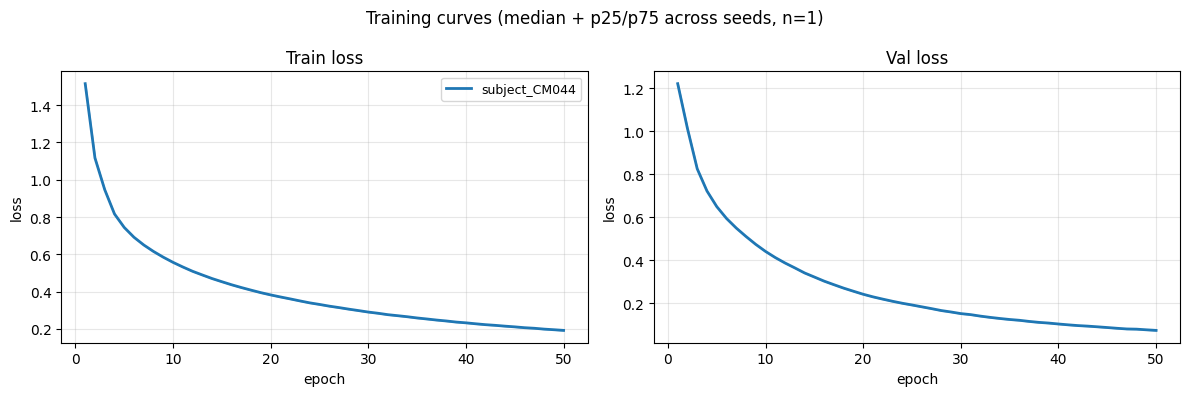

  wrote /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures/acq_sanity.png


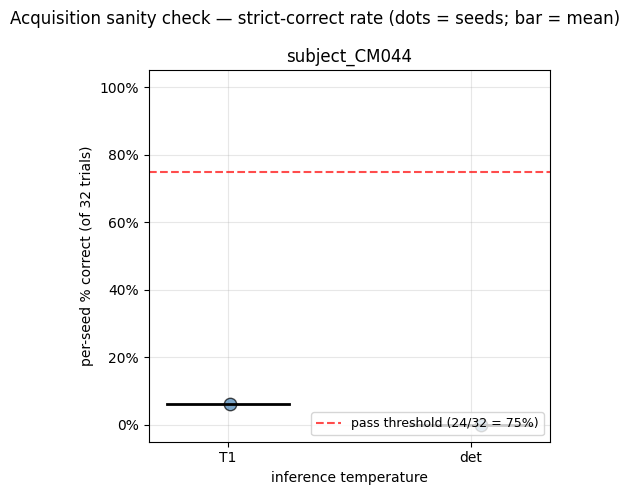

  wrote /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures/probe_performance.png


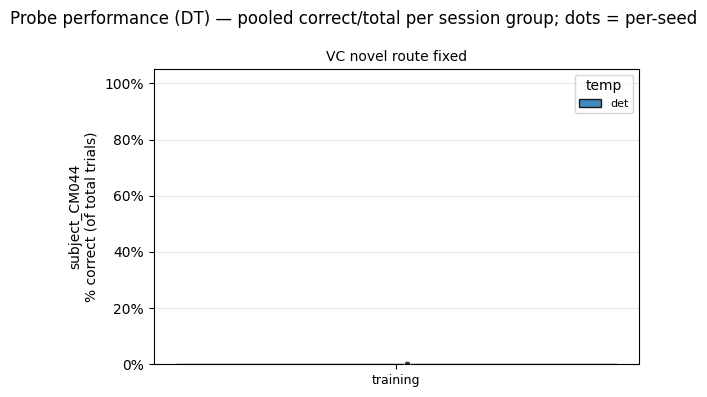

  wrote /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures/performance_profiles.png


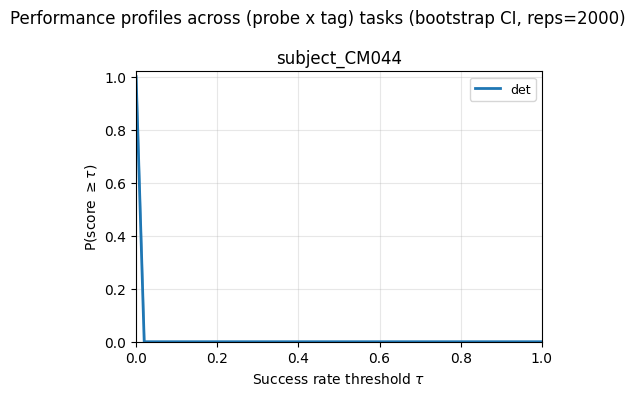

In [76]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

FIGURES_DIR = RUN_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)


# ── numpy replacements for rliable (avoids pandas-3 / arch / statsmodels conflict) ──
def _iqm(arr: np.ndarray) -> float:
    """Interquartile mean: mean of values within [Q1, Q3]."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return float('nan')
    if len(arr) == 1:
        return float(arr[0])
    q1, q3 = np.quantile(arr, [0.25, 0.75])
    keep = arr[(arr >= q1) & (arr <= q3)]
    return float(keep.mean()) if len(keep) else float(arr.mean())


def _iqm_ci(per_seed_scores: np.ndarray, reps: int = 2000,
            seed: int = 0) -> tuple[float, float, float]:
    """IQM + 95% percentile-bootstrap CI from a per-seed score array."""
    arr = np.asarray(per_seed_scores, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return float('nan'), float('nan'), float('nan')
    if len(arr) == 1:
        v = float(arr[0])
        return v, v, v
    rng     = np.random.default_rng(seed)
    n       = len(arr)
    samples = rng.integers(0, n, size=(reps, n))
    boots   = np.array([_iqm(arr[idx]) for idx in samples])
    lo, hi  = np.percentile(boots, [2.5, 97.5])
    return _iqm(arr), float(lo), float(hi)


def _perf_profile(scores_matrix: np.ndarray, tau: np.ndarray,
                  reps: int = 2000, seed: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Performance profile P(score >= tau) over (seeds × tasks) cells.

    Returns (point, ci) where:
      point: shape (len(tau),)
      ci:    shape (2, len(tau)) — [lo, hi] at 95%
    """
    arr = np.asarray(scores_matrix, dtype=float)
    arr = np.nan_to_num(arr, nan=np.nanmean(arr) if np.any(~np.isnan(arr)) else 0.0)
    flat = arr.reshape(-1)
    point = np.array([(flat >= t).mean() for t in tau])

    rng = np.random.default_rng(seed)
    n   = len(flat)
    boots = np.empty((reps, len(tau)))
    for r in range(reps):
        idx        = rng.integers(0, n, size=n)
        resampled  = flat[idx]
        boots[r]   = [(resampled >= t).mean() for t in tau]
    ci = np.percentile(boots, [2.5, 97.5], axis=0)
    return point, ci


def plot_training_curves(run_root: Path | None = None, show: bool = True):
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    curves_paths = sorted(run_root.glob('*/seed_*/curves.parquet'))
    if not curves_paths:
        print('no curves.parquet — skipping plot_training_curves')
        return
    all_curves = pd.concat([pd.read_parquet(p) for p in curves_paths], ignore_index=True)

    units = sorted(all_curves['unit_label'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(units), 1)))

    for unit, color in zip(units, colors):
        sub = all_curves[all_curves['unit_label'] == unit]
        for ax, col, title in zip(axes, ['train_loss', 'val_loss'], ['Train loss', 'Val loss']):
            stats = (sub.groupby('epoch')[col]
                     .agg(median='median',
                          p25=lambda x: x.quantile(0.25),
                          p75=lambda x: x.quantile(0.75))
                     .reset_index())
            ax.plot(stats['epoch'], stats['median'], color=color, label=unit, lw=2)
            ax.fill_between(stats['epoch'], stats['p25'], stats['p75'], alpha=0.25, color=color)
            ax.set_title(title); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
            ax.grid(True, alpha=0.3)
    axes[0].legend(loc='upper right', fontsize=9)
    fig.suptitle(f'Training curves (median + p25/p75 across seeds, n={all_curves["seed"].nunique()})')
    fig.tight_layout()
    out = FIGURES_DIR / 'training_curves.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def plot_acq_sanity(run_root: Path | None = None, show: bool = True):
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    acq_paths = sorted(run_root.glob('*/seed_*/acq_inference.parquet'))
    if not acq_paths:
        print('no acq_inference.parquet — skipping plot_acq_sanity')
        return
    all_acq = pd.concat([pd.read_parquet(p) for p in acq_paths], ignore_index=True)
    per_seed = (all_acq.groupby(['unit_label', 'temp_label', 'seed'])
                .agg(n_correct=('dt_correct', 'sum'),
                     n_trials=('dt_correct', 'count'))
                .reset_index())
    per_seed['rate'] = per_seed['n_correct'] / per_seed['n_trials']

    units = sorted(per_seed['unit_label'].unique())
    temps = sorted(per_seed['temp_label'].unique())
    n_units = len(units)
    fig, axes = plt.subplots(1, n_units, figsize=(max(4 * n_units, 5), 5), sharey=True)
    if n_units == 1: axes = [axes]
    pass_rate = ACQ_PASS_COMPLETED_TRIALS / ACQ_INFERENCE_TRIALS
    rng = np.random.RandomState(0)
    for ax, unit in zip(axes, units):
        sub = per_seed[per_seed['unit_label'] == unit]
        for i, temp in enumerate(temps):
            rates = sub[sub['temp_label'] == temp]['rate'].values
            jitter = rng.uniform(-0.1, 0.1, size=len(rates))
            ax.scatter(np.full(len(rates), i) + jitter, rates,
                       s=80, alpha=0.7, color='steelblue', edgecolors='black', zorder=3)
            if len(rates):
                ax.plot([i - 0.25, i + 0.25], [rates.mean(), rates.mean()],
                        color='black', lw=2, zorder=4)
        ax.axhline(pass_rate, color='red', linestyle='--', alpha=0.7, zorder=2,
                   label=f'pass threshold ({ACQ_PASS_COMPLETED_TRIALS}/{ACQ_INFERENCE_TRIALS} = {pass_rate:.0%})')
        ax.set_xticks(range(len(temps))); ax.set_xticklabels(temps)
        ax.set_ylim(-0.05, 1.05)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
        ax.set_xlabel('inference temperature')
        ax.set_title(unit)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(f'per-seed % correct (of {ACQ_INFERENCE_TRIALS} trials)')
    axes[0].legend(loc='lower right', fontsize=9)
    fig.suptitle('Acquisition sanity check — strict-correct rate (dots = seeds; bar = mean)')
    fig.tight_layout()
    out = FIGURES_DIR / 'acq_sanity.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def _per_seed_probe_scores(run_root: Path) -> pd.DataFrame:
    paths = sorted(run_root.glob('*/seed_*/probes.parquet'))
    if not paths:
        return pd.DataFrame()
    all_probes = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    per_seed = (all_probes.groupby(['unit_label', 'probe_session_type', 'trial_tag', 'temp_label', 'seed'])
                .agg(n_trials=('dt_completed', 'count'),
                     n_completed=('dt_completed', 'sum'))
                .reset_index())
    per_seed['rate'] = per_seed['n_completed'] / per_seed['n_trials']
    return per_seed


# Probe-session bucketing: which probe paradigms get a training-vs-probe split
# vs a single overall score. Match by substring on probe_session_type so this
# works regardless of the training-group prefix ("PI+VC f2 novel route", etc.).
_PROBE_SPLIT_KEYWORDS = ('novel route', 'reversal')
_TRAINING_TAGS        = {'trained', 'probe_trained'}
_PROBE_MANIP_TAGS     = {'novel', 'reversal'}


def _probe_session_group(probe_type: str, tag: str) -> str:
    """Classify a probe trial into 'training', 'probe', or 'overall'.

    For probes in _PROBE_SPLIT_KEYWORDS, training-style tags become the in-session
    baseline and manipulation tags become the probe bar. Other probes pool every
    trial into 'overall' so the bar reflects the full session score.
    """
    if any(kw in probe_type for kw in _PROBE_SPLIT_KEYWORDS):
        if tag in _TRAINING_TAGS:    return 'training'
        if tag in _PROBE_MANIP_TAGS: return 'probe'
        return 'other'
    return 'overall'


def plot_probe_performance(run_root: Path | None = None, show: bool = True):
    """Per-(unit, probe) session score: correct trials / total possible trials.

    Bars = pooled correct/total across all seeds + repeats (strict-correct via dt_correct).
    Dots = per-seed correct/total, jittered around each bar so seed-to-seed variability
    stays visible. For 'novel route' and 'reversal' probes the bars split into
    {training, probe} so the probe-manipulation trials can be compared against the
    in-session trained baseline; other probes show a single overall session score.
    """
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    paths = sorted(run_root.glob('*/seed_*/probes.parquet'))
    if not paths:
        print('no probes.parquet — skipping plot_probe_performance')
        return
    all_probes = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    all_probes['group'] = [
        _probe_session_group(pt, tg)
        for pt, tg in zip(all_probes['probe_session_type'], all_probes['trial_tag'])
    ]
    all_probes = all_probes[all_probes['group'] != 'other']

    units   = sorted(all_probes['unit_label'].unique())
    probes  = sorted(all_probes['probe_session_type'].unique())
    temps   = sorted(all_probes['temp_label'].unique())
    palette = dict(zip(temps, plt.cm.tab10(np.linspace(0, 1, max(len(temps), 1)))))

    n_units, n_probes = len(units), len(probes)
    fig, axes = plt.subplots(n_units, n_probes,
                             figsize=(max(4 * n_probes, 6), max(3.8 * n_units, 4)),
                             sharey=True, squeeze=False)

    rng = np.random.RandomState(0)
    for ui, unit in enumerate(units):
        for pi, probe in enumerate(probes):
            ax   = axes[ui, pi]
            cell = all_probes[(all_probes['unit_label'] == unit) &
                              (all_probes['probe_session_type'] == probe)]
            split  = any(kw in probe for kw in _PROBE_SPLIT_KEYWORDS)
            wanted = ['training', 'probe'] if split else ['overall']
            groups_here = [g for g in wanted if (cell['group'] == g).any()]
            if not groups_here:
                ax.set_visible(False)
                continue
            x       = np.arange(len(groups_here))
            n_temps = len(temps)
            width   = 0.8 / max(n_temps, 1)

            for ti, temp in enumerate(temps):
                offset = (ti - (n_temps - 1) / 2) * width
                labeled_temp = False
                for gi, group in enumerate(groups_here):
                    sub = cell[(cell['temp_label'] == temp) & (cell['group'] == group)]
                    if sub.empty:
                        continue
                    # Pooled rate across all seeds + repeats.
                    pooled = float(sub['dt_correct'].sum()) / float(len(sub))
                    ax.bar(x[gi] + offset, pooled, width,
                           color=palette[temp], edgecolor='black', alpha=0.85, zorder=2,
                           label=(temp if not labeled_temp else None))
                    labeled_temp = True
                    # Per-seed dots: correct/total for each seed at this (group, temp).
                    per_seed = (sub.groupby('seed')['dt_correct']
                                .agg(['sum', 'count']).reset_index())
                    per_seed['rate'] = per_seed['sum'] / per_seed['count']
                    jitter = rng.uniform(-width / 4, width / 4, size=len(per_seed))
                    ax.scatter(np.full(len(per_seed), x[gi] + offset) + jitter,
                               per_seed['rate'].values,
                               s=22, alpha=0.75, color='black', edgecolors='white',
                               linewidth=0.5, zorder=3)
            ax.set_xticks(x); ax.set_xticklabels(groups_here, fontsize=9)
            ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3, axis='y')
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
            if ui == 0:
                ax.set_title(probe, fontsize=10)
            if pi == 0:
                ax.set_ylabel(f'{unit}\n% correct (of total trials)')
            if ui == 0 and pi == n_probes - 1:
                ax.legend(loc='upper right', fontsize=8, title='temp')
    fig.suptitle('Probe performance (DT) — pooled correct/total per session group; dots = per-seed')
    fig.tight_layout()
    out = FIGURES_DIR / 'probe_performance.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def plot_performance_profiles(run_root: Path | None = None, show: bool = True, reps: int = 2000):
    """P(success_rate >= tau) across all (probe x tag) tasks, one curve per temp."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    per_seed = _per_seed_probe_scores(run_root)
    if per_seed.empty:
        print('no probes.parquet — skipping plot_performance_profiles')
        return

    units = sorted(per_seed['unit_label'].unique())
    temps = sorted(per_seed['temp_label'].unique())
    tau   = np.linspace(0.0, 1.0, 51)

    fig, axes = plt.subplots(1, len(units), figsize=(max(5 * len(units), 5), 4), sharey=True, squeeze=False)
    axes = axes[0]
    palette = dict(zip(temps, plt.cm.tab10(np.linspace(0, 1, len(temps)))))
    for ax, unit in zip(axes, units):
        sub   = per_seed[per_seed['unit_label'] == unit]
        tasks = sorted({(p, t) for p, t in zip(sub['probe_session_type'], sub['trial_tag'])})
        seeds = sorted(sub['seed'].unique())
        for temp in temps:
            arr = np.full((len(seeds), len(tasks)), np.nan)
            for r, sd in enumerate(seeds):
                for c, (p, t) in enumerate(tasks):
                    cell = sub[(sub['temp_label'] == temp) & (sub['seed'] == sd)
                               & (sub['probe_session_type'] == p) & (sub['trial_tag'] == t)]
                    if len(cell):
                        arr[r, c] = float(cell['rate'].iloc[0])
            pt, ci = _perf_profile(arr, tau, reps=reps)
            color = palette[temp]
            ax.plot(tau, pt, color=color, label=temp, lw=2)
            ax.fill_between(tau, ci[0], ci[1], color=color, alpha=0.25)
        ax.set_title(unit); ax.grid(True, alpha=0.3)
        ax.set_xlabel(r'Success rate threshold $\tau$')
        ax.set_ylabel(r'P(score $\geq\tau$)')
        ax.set_ylim(0, 1.02); ax.set_xlim(0, 1)
        ax.legend(loc='upper right', fontsize=9)

    fig.suptitle(f'Performance profiles across (probe x tag) tasks (bootstrap CI, reps={reps})')
    fig.tight_layout()
    out = FIGURES_DIR / 'performance_profiles.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


# Auto-execute
print(f'=== plotting -> {FIGURES_DIR} ===')
plot_training_curves()
plot_acq_sanity()
plot_probe_performance()
plot_performance_profiles()





## 13. DT diagnostics — paths + attention

Drill-down visualizations that go beyond Cell 12's aggregates. Three plots, auto-execute:

1. **Path replay** (`path_replay.png`) — one DT trial on the 13×13 maze. Default: first completed trial of seed 0's first probe paradigm, deterministic. Trajectory line colored by step (viridis), markers at start (green) / end (red), wells (open squares). For per-(probe, trial) drill-down, call `plot_path_replay(probe=..., trial_idx=...)` manually.

2. **Attention by step-offset, split by modality** (`attention_summary.png`) — for each saved probe's deterministic attention file, decode each attention column into `(step_offset, modality)` where `step_offset ∈ [-(K-1), 0]` and `modality ∈ {R, s, a}`. Average over steps and heads, plot three lines (R / s / a) showing average attention vs how far back. The headline question: which modality stream does the DT lean on most, and across what horizon?

3. **Attention head × step-offset heatmap** (`attention_heatmap.png`) — same data, but kept per-head. One subplot per (probe × modality) showing all `n_heads` rows. Reveals whether different heads specialize on different temporal scales or modalities.

**Why only deterministic attention?** Cell 9 only saves attention for deterministic rollouts (per Cell 1's `SAVE_PROBE_ATTENTION` + Cell 9's `save_attn = save_attention and is_det` rule). Sampled rollouts have rollout-specific noise that makes per-step attention less interpretable.

**Inputs**: reads `RUN_ROOT/*/seed_*/probe_trajectory.parquet` and `RUN_ROOT/*/seed_*/attention/probe_*.pt`. All saved by Cell 9.

**Useful follow-ups**: per-cohort comparison (PI vs PI+VC vs VC) when multiple subject groups exist — would just loop these plots over units. Not in v1, easy to add.

=== DT diagnostics → /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures ===
  wrote /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures/path_replay.png


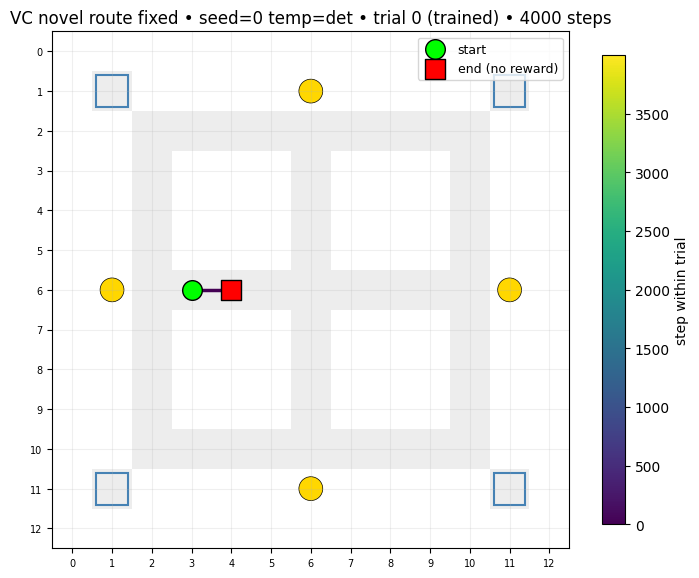

  wrote /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures/attention_summary.png


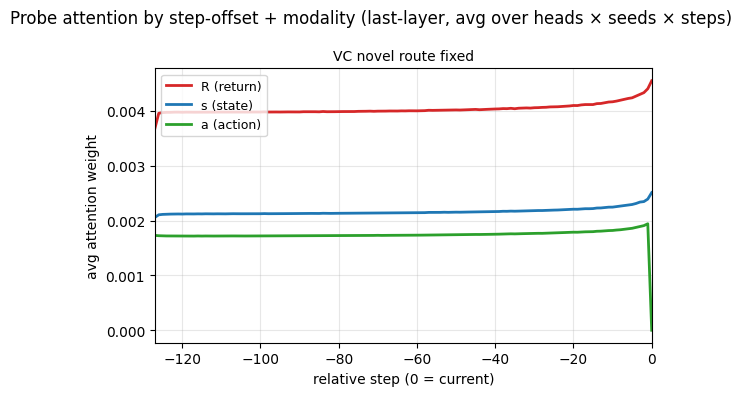

  wrote /Users/ryangrgurich/Code/python-dev/corner-maze-rl/data/runs/dt-vanilla-pi-cm44-pose_visual-epoch-50-kill-5_20260530_051740/figures/attention_heatmap.png


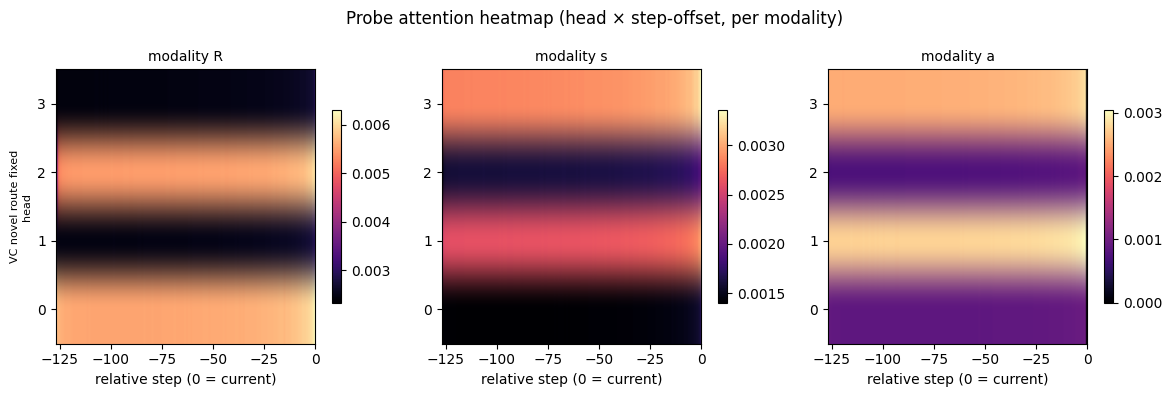

In [77]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from corner_maze_rl.env.constants import WELL_LOCATIONS, CUE_LOCATIONS

# ── Maze layout helper ──────────────────────────────────
def _draw_maze_skeleton(ax):
    """Draw the 13×13 maze skeleton (valid floor cells, wells, cues)."""
    # Valid floor cells: 3 horizontal corridors (y=2,6,10) and 4 arms
    valid = set()
    for j in range(9):
        for ay in (2, 6, 10):
            valid.add((j + 2, ay))
    for ax_off in (2, 6, 10):
        for j in range(3):
            valid.add((ax_off, j + 3))
            valid.add((ax_off, j + 7))
    # The four well corners
    for wx, wy in WELL_LOCATIONS:
        valid.add((wx, wy))
    # Plot floor as light cells
    for (x, y) in valid:
        ax.add_patch(mpatches.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                         facecolor='lightgray', alpha=0.4, edgecolor='none'))
    # Wells
    for wx, wy in WELL_LOCATIONS:
        ax.add_patch(mpatches.Rectangle((wx - 0.4, wy - 0.4), 0.8, 0.8,
                                         facecolor='none', edgecolor='steelblue', lw=1.5))
    # Cues (the four cardinal cue display positions)
    for cx, cy in CUE_LOCATIONS:
        ax.add_patch(mpatches.Circle((cx, cy), 0.3, facecolor='gold', edgecolor='black', lw=0.5))
    ax.set_xlim(-0.5, 12.5); ax.set_ylim(12.5, -0.5)  # y-down for screen coords
    ax.set_aspect('equal')
    ax.set_xticks(range(13)); ax.set_yticks(range(13))
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)


# ── Path replay ─────────────────────────────────────────
def plot_path_replay(run_root: Path | None = None,
                     probe: str | None = None,
                     temp_label: str = 'det',
                     seed: int | None = None,
                     trial_idx: int | None = None,
                     show: bool = True):
    """Plot one trial's grid trajectory. Defaults pick the first completed (or first) trial."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    paths = sorted(run_root.glob('*/seed_*/probe_trajectory.parquet'))
    if not paths:
        print('no probe_trajectory.parquet — skipping plot_path_replay')
        return
    traj = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)

    if seed is None:       seed       = int(traj['seed'].min())
    if probe is None:      probe      = sorted(traj['probe_session_type'].unique())[0]
    # Filter to (seed, probe, temp, repeat_idx=0)
    sub = traj[(traj['seed'] == seed) & (traj['probe_session_type'] == probe)
               & (traj['temp_label'] == temp_label) & (traj['repeat_idx'] == 0)]
    if sub.empty:
        print(f'no trajectory for seed={seed} probe={probe!r} temp={temp_label!r} — skipping')
        return
    # Pick the trial: first completed, else first
    if trial_idx is None:
        completed_trials = sub[sub['env_reward'] > 0.5]['trial_id'].unique()
        trial_idx = int(completed_trials[0]) if len(completed_trials) else int(sub['trial_id'].min())
    trial = sub[sub['trial_id'] == trial_idx].sort_values('step').reset_index(drop=True)
    if trial.empty:
        print(f'no trial_id={trial_idx} — skipping')
        return

    fig, ax = plt.subplots(figsize=(7, 7))
    _draw_maze_skeleton(ax)

    xs, ys = trial['grid_x'].values, trial['grid_y'].values
    # Color trajectory by step (viridis)
    segs = np.array([[xs[:-1], ys[:-1]], [xs[1:], ys[1:]]]).transpose(2, 0, 1)
    lc = LineCollection(segs, cmap='viridis', linewidths=2.5)
    lc.set_array(np.arange(len(xs) - 1))
    ax.add_collection(lc)
    plt.colorbar(lc, ax=ax, shrink=0.7, label='step within trial')
    # Start (green) and end (red)
    ax.scatter([xs[0]], [ys[0]], s=200, c='lime', edgecolors='black', zorder=5, label='start')
    ax.scatter([xs[-1]], [ys[-1]], s=200, c='red', edgecolors='black', zorder=5,
               marker='X' if (trial['env_reward'].iloc[-1] > 0.5) else 's',
               label='reward' if (trial['env_reward'].iloc[-1] > 0.5) else 'end (no reward)')
    ax.legend(loc='upper right', fontsize=9)
    tag = trial['trial_tag'].iloc[0]
    ax.set_title(f'{probe} • seed={seed} temp={temp_label} • trial {trial_idx} ({tag}) • '
                 f'{len(trial)} steps')
    fig.tight_layout()
    out = FIGURES_DIR / 'path_replay.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


# ── Attention aggregation ───────────────────────────────
def _load_probe_attention_files(run_root: Path) -> list[dict]:
    """Load all saved probe attention .pt files. Returns list of dicts."""
    out = []
    for p in sorted(run_root.glob('*/seed_*/attention/probe_*.pt')):
        try:
            data = torch.load(p, weights_only=False)
            data['_path'] = p
            out.append(data)
        except Exception as e:
            print(f'  [warn] failed to load {p}: {e}')
    return out


def _decode_attention_to_modality_grid(saved: dict) -> np.ndarray | None:
    """From a saved attention dict, return a (n_heads, K, 3) array averaged over steps.

    The saved 'episode_attention' is a list (per env step) of (n_heads, ctx_K * 3) tensors.
    Each column j is at relative step_offset = (j // 3) - (ctx_K - 1), modality = j % 3.
    We aggregate over time by averaging across all per-step rows, binning by (offset, modality).
    Modality index: 0=R, 1=s, 2=a.
    Returns array of shape (n_heads, K, 3) where K = (max step_offset range) = full K context.
    """
    ep_attn = saved.get('episode_attention', [])
    if not ep_attn:
        return None
    n_heads = ep_attn[0].shape[0]
    # Aggregate
    sum_grid = np.zeros((n_heads, K, 3), dtype=np.float64)
    cnt_grid = np.zeros((n_heads, K, 3), dtype=np.int64)
    for step_attn in ep_attn:
        arr = step_attn.numpy() if hasattr(step_attn, 'numpy') else np.asarray(step_attn)
        ctx_len = arr.shape[1] // 3
        for j in range(arr.shape[1]):
            offset = (j // 3) - (ctx_len - 1)   # in [-(ctx_len-1), 0]
            modality = j % 3
            offset_idx = offset + (K - 1)        # remap to [0, K-1]
            if 0 <= offset_idx < K:
                sum_grid[:, offset_idx, modality] += arr[:, j]
                cnt_grid[:, offset_idx, modality] += 1
    with np.errstate(invalid='ignore'):
        mean_grid = np.where(cnt_grid > 0, sum_grid / np.maximum(cnt_grid, 1), 0.0)
    return mean_grid


def plot_attention_summary(run_root: Path | None = None, show: bool = True):
    """Per-probe: avg attention by step_offset, split by modality (R/s/a). Averaged over heads."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    attns = _load_probe_attention_files(run_root)
    if not attns:
        print('no probe attention .pt files — skipping plot_attention_summary')
        return

    # Group by probe; average across all (seed × probe attention files)
    probes = sorted({d['probe_session_type'] for d in attns})
    fig, axes = plt.subplots(1, len(probes), figsize=(max(4 * len(probes), 6), 4),
                              sharey=True, squeeze=False)
    axes = axes[0]
    offsets = np.arange(-(K - 1), 1)
    mod_names = ['R (return)', 's (state)', 'a (action)']
    mod_colors = ['tab:red', 'tab:blue', 'tab:green']

    for ax, probe in zip(axes, probes):
        grids = [g for d in attns if d['probe_session_type'] == probe
                 and (g := _decode_attention_to_modality_grid(d)) is not None]
        if not grids:
            ax.set_title(f'{probe}\n(no attention data)')
            continue
        # Average over (files × heads): (K, 3)
        avg = np.stack(grids).mean(axis=0).mean(axis=0)
        for m in range(3):
            ax.plot(offsets, avg[:, m], color=mod_colors[m], lw=2, label=mod_names[m])
        ax.set_xlabel('relative step (0 = current)')
        ax.set_xlim(-(K - 1), 0)
        ax.set_title(probe, fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('avg attention weight')
    axes[0].legend(loc='upper left', fontsize=9)
    fig.suptitle(f'Probe attention by step-offset + modality (last-layer, avg over heads × seeds × steps)')
    fig.tight_layout()
    out = FIGURES_DIR / 'attention_summary.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


def plot_attention_heatmap(run_root: Path | None = None, show: bool = True):
    """Per-(probe × modality): head × step_offset heatmap (averaged over files + steps)."""
    if run_root is None: run_root = RUN_ROOT
    run_root = Path(run_root)
    attns = _load_probe_attention_files(run_root)
    if not attns:
        print('no probe attention .pt files — skipping plot_attention_heatmap')
        return

    probes = sorted({d['probe_session_type'] for d in attns})
    mod_names = ['R', 's', 'a']
    fig, axes = plt.subplots(len(probes), 3, figsize=(12, max(2.8 * len(probes), 4)),
                              squeeze=False)
    offsets = np.arange(-(K - 1), 1)

    for ri, probe in enumerate(probes):
        grids = [g for d in attns if d['probe_session_type'] == probe
                 and (g := _decode_attention_to_modality_grid(d)) is not None]
        if not grids:
            for ci in range(3):
                axes[ri, ci].axis('off')
            continue
        avg = np.stack(grids).mean(axis=0)   # (n_heads, K, 3)
        n_heads = avg.shape[0]
        for ci in range(3):
            ax = axes[ri, ci]
            im = ax.imshow(avg[:, :, ci], aspect='auto', origin='lower',
                            extent=[offsets[0], offsets[-1], -0.5, n_heads - 0.5],
                            cmap='magma')
            ax.set_yticks(range(n_heads))
            if ci == 0:
                ax.set_ylabel(f'{probe}\nhead', fontsize=8)
            if ri == 0:
                ax.set_title(f'modality {mod_names[ci]}', fontsize=10)
            if ri == len(probes) - 1:
                ax.set_xlabel('relative step (0 = current)')
            plt.colorbar(im, ax=ax, shrink=0.7)
    fig.suptitle('Probe attention heatmap (head × step-offset, per modality)')
    fig.tight_layout()
    out = FIGURES_DIR / 'attention_heatmap.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    print(f'  wrote {out}')
    if show: plt.show()
    else:    plt.close(fig)


# ── Auto-execute ──────────────────────────────────────────
print(f'=== DT diagnostics → {FIGURES_DIR} ===')
plot_path_replay()
plot_attention_summary()
plot_attention_heatmap()


## 14. Session playback (animate one inference trial)

`playback_trial(...)` reconstructs one DT inference trial into an animated GIF — like `02_explore_yoked_data.ipynb`'s replay but for the DT's behavior on probes (or acquisition). Useful for: "why did this rollout fail?" / "what was the agent doing on step 47?" / "how does sampled DT differ from argmax DT on the same trial conditions?"

**Each frame shows**:
- Left panel: 13×13 maze skeleton (floor cells, wells, cues) with the agent's path so far (blue line, growing) + current position (red dot) + start position (green dot).
- Right panel: per-step monospace info — action being taken, env reward this step, model's `rtg_before_action`, trial id/tag/timestep, and the canonical pose_label.

**Defaults**: first completed trial of first seed's first probe paradigm at deterministic temp. Override via kwargs for drill-down:
```python
playback_trial(probe='PI+VC f2 novel route', seed=2, temp_label='T1', trial_idx=15)
playback_trial(source='acq', trial_idx=8)            # acquisition trial
```

**Output**: GIF saved to `RUN_ROOT/figures/playback_*.gif`, displayed inline.

**Cost**: ~3-10 sec per trial to generate (depends on `fps` and trial length). Default `fps=8` gives a watchable ~5 sec animation for a ~40-step trial.

**Requires**: `*_trajectory.parquet` files (from Cell 10). If you haven't run the full pipeline yet, this cell prints a "no data" notice and does nothing.

In [78]:
import asyncio
import io
import json

import ipywidgets as widgets
from PIL import Image as PILImage
from IPython.display import display

from corner_maze_rl.env.constants import EYE_IMG_SIZE, WELL_LOCATIONS


# ── Theme + sizing ────────────────────────────────────────
BG_COLOR    = "#333333"
TEXT_COLOR  = "#ffffff"
MUTED_COLOR = "#aaaaaa"
IMG_SIZE    = 299              # 13 * 23
FIELD_W     = "320px"
ACTION_NAMES = {0: 'Left', 1: 'Right', 2: 'Forward', 3: 'Enter Well', 4: 'Pause'}

style_widget = widgets.HTML(f"""<style>
.dt-ui, .dt-ui * {{
    background-color: {BG_COLOR} !important;
    color: {TEXT_COLOR} !important;
    border-color: {BG_COLOR} !important;
}}
.dt-ui {{ padding: 15px !important; }}
.dt-ui .widget-image {{ background-color: transparent !important; }}
.dt-ui .form-input select,
.dt-ui .form-input input {{
    background-color: #4a4a4a !important;
    color: #ffffff !important;
    border: 1px solid #888 !important;
    border-radius: 4px !important;
    padding: 2px 6px !important;
}}
.dt-ui .form-button,
.dt-ui .form-button > button {{
    background: #6a6a6a !important;
    background-color: #6a6a6a !important;
    color: #ffffff !important;
    border: 1px solid #d0d0d0 !important;
    border-radius: 4px !important;
    box-shadow: inset 0 0 0 1px #d0d0d0 !important;
    font-weight: 500 !important;
    padding: 4px 12px !important;
}}
.dt-ui .form-field-label {{
    font-size: 12px !important;
    font-weight: 600 !important;
    color: #c8c8c8 !important;
    margin: 6px 0 2px 0 !important;
}}
.dt-ui .form-status {{
    font-size: 12px !important;
    color: #c8c8c8 !important;
    margin: 8px 0 0 0 !important;
    line-height: 1.5 !important;
}}
.dt-ui select option {{ background-color: #4a4a4a !important; color: #ffffff !important; }}
.dt-ui .form-rollout-picker select {{
    font-family: monospace !important;
    font-size: 12px !important;
    background-color: #4a4a4a !important;
    color: #ffffff !important;
    border: 1px solid #888 !important;
    border-radius: 4px !important;
}}
.dt-ui .form-rollout-picker option {{
    font-family: monospace !important;
    background-color: #4a4a4a !important;
    color: #ffffff !important;
    padding: 2px 6px !important;
}}
.dt-ui .form-rollout-picker option:checked {{
    background-color: #6680b0 !important;
    color: #ffffff !important;
}}
</style>""")


# ── Image helpers ─────────────────────────────────────────
zero_eye   = np.zeros((EYE_IMG_SIZE, EYE_IMG_SIZE), dtype=np.float64)
blank_maze = np.full((23 * 13, 23 * 13, 3), 30, dtype=np.uint8)

def _frame_to_png(frame):
    img = PILImage.fromarray(frame).resize((IMG_SIZE, IMG_SIZE), PILImage.NEAREST)
    buf = io.BytesIO(); img.save(buf, format="PNG"); return buf.getvalue()

def _eye_to_png(eye_arr):
    gray = (np.asarray(eye_arr, dtype=np.float64) * 255).astype(np.uint8)
    img  = PILImage.fromarray(gray).resize((IMG_SIZE, IMG_SIZE), PILImage.NEAREST)
    buf  = io.BytesIO(); img.save(buf, format="PNG"); return buf.getvalue()


# ── Load all DT trajectories from RUN_ROOT ────────────────
def _load_dt_trajectories(run_root: Path) -> pd.DataFrame:
    frames = []
    for fname in ('acq_trajectory.parquet', 'probe_trajectory.parquet'):
        for p in sorted(Path(run_root).glob(f'*/seed_*/{fname}')):
            df = pd.read_parquet(p)
            # Normalize session-type column across acq (`paradigm`) and probe (`probe_session_type`).
            if 'paradigm' in df.columns:
                df['_session_type'] = df['paradigm']
            elif 'probe_session_type' in df.columns:
                df['_session_type'] = df['probe_session_type']
            else:
                df['_session_type'] = '(unknown)'
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


TRAJ = _load_dt_trajectories(RUN_ROOT)


if TRAJ.empty:
    print(f'No DT trajectory parquets found under {RUN_ROOT}. Run Cell 10 first.')
else:
    # ── Mutable state shared across callbacks ────────────
    state = {
        'env':          None,
        'actions':      None,
        'n_steps':      0,
        'current_step': 0,
        'has_eyes':     False,
        'seed':         0,
        'label_str':    '(no rollout loaded)',
    }
    play_state = {'running': False}

    # ── Display widgets ──────────────────────────────────
    maze_widget      = widgets.Image(format='png', width=IMG_SIZE, height=IMG_SIZE,
                                     value=_frame_to_png(blank_maze))
    left_eye_widget  = widgets.Image(format='png', width=IMG_SIZE, height=IMG_SIZE,
                                     value=_eye_to_png(zero_eye))
    right_eye_widget = widgets.Image(format='png', width=IMG_SIZE, height=IMG_SIZE,
                                     value=_eye_to_png(zero_eye))
    label_widget     = widgets.HTML(value='')
    info_widget      = widgets.HTML(value='')
    status_label     = widgets.HTML(value='')
    status_label.add_class('form-status')

    def _render():
        env = state['env']
        if env is not None:
            maze_widget.value = _frame_to_png(env.get_allocentric_frame(tile_size=23))
            if state['has_eyes']:
                try:
                    pose = env.get_pose_label()
                    le   = env._pose_to_left_eye.get(pose, zero_eye)
                    re   = env._pose_to_right_eye.get(pose, zero_eye)
                except Exception:
                    le = re = zero_eye
            else:
                le = re = zero_eye
            left_eye_widget.value  = _eye_to_png(le)
            right_eye_widget.value = _eye_to_png(re)
        else:
            maze_widget.value      = _frame_to_png(blank_maze)
            left_eye_widget.value  = _eye_to_png(zero_eye)
            right_eye_widget.value = _eye_to_png(zero_eye)
        label_widget.value = (
            f'<div style="font-size:13px; text-align:center; margin-top:4px;">'
            f'<b>{state["label_str"]}</b></div>'
        )

        # Info panel: trial, step, pose, action, session score, RTG
        actions = state['actions']
        if env is not None and actions is not None and state['n_steps'] > 0:
            cs = state['current_step']
            n  = state['n_steps']
            total_trials = int(actions['trial_id'].max()) + 1
            cum_reward   = float(actions.iloc[:cs]['env_reward'].sum()) if cs > 0 else 0.0
            if cs < n:
                row          = actions.iloc[cs]
                trial_num    = int(row['trial_id']) + 1
                pose_str     = str(row['pose_label'])
                act_idx      = int(row['action'])
                action_str   = f"{ACTION_NAMES.get(act_idx, '?')} ({act_idx})"
                rtg_str      = f"{float(row['rtg_before_action']):.4f}"
            else:
                last         = actions.iloc[-1]
                trial_num    = int(last['trial_id']) + 1
                pose_str     = '—'
                action_str   = '— (done)'
                rtg_str      = f"{float(last['rtg_before_action']):.4f}"
            info_widget.value = (
                f'<div style="font-size:13px; line-height:1.7; font-family:monospace; '
                f'text-align:center; margin-top:4px;">'
                f'<b>Trial:</b> {trial_num} / {total_trials} &nbsp; '
                f'<b>Step:</b> {cs} / {n}<br>'
                f'<b>Pose:</b> <code>{pose_str}</code><br>'
                f'<b>Action:</b> {action_str} &nbsp; '
                f'<b>Score:</b> {cum_reward:+.4f} &nbsp; '
                f'<b>RTG:</b> {rtg_str}'
                f'</div>'
            )
        else:
            info_widget.value = (
                f'<div style="font-size:13px; color:{MUTED_COLOR}; '
                f'text-align:center; margin-top:4px;">—</div>'
            )

    # ── Rollout picker (scrollable table) ────────────────
    _PICKER_COLS = ['source', '_session_type', 'temp_label', 'seed', 'repeat_idx']
    # Correct trial = the agent reached the goal well (env_reward > 0.5) AND never
    # entered any well cell that was not the goal earlier in the same trial.
    # Wrong-well visits don't show up in env_reward (the env only sets trial_score=0
    # internally), so we detect them from position transitions onto WELL_LOCATIONS.
    # Restricted to trial-phase steps (pose_label starts with 'trl_'): corner cells
    # are well objects always, and ITI/pretrial traversal of them is not an error.
    _WELL_LOCS = {tuple(map(int, loc)) for loc in WELL_LOCATIONS}

    def _count_correct_trials(sub: pd.DataFrame) -> int:
        n_correct = 0
        for _tid, trial in sub.groupby('trial_id', sort=False):
            rewards = trial['env_reward'].to_numpy()
            if not (rewards > 0.5).any():
                continue
            xs    = trial['grid_x'].to_numpy()
            ys    = trial['grid_y'].to_numpy()
            poses = trial['pose_label'].to_numpy()
            prev_at_well = False
            wrong_entry  = False
            for x, y, r, p in zip(xs, ys, rewards, poses):
                if not str(p).startswith('trl_'):
                    continue
                cur_at_well = (int(x), int(y)) in _WELL_LOCS
                if cur_at_well and not prev_at_well and r < 0.5:
                    wrong_entry = True
                    break
                prev_at_well = cur_at_well
            if not wrong_entry:
                n_correct += 1
        return n_correct

    _rollout_rows = []
    for keys, sub in TRAJ.groupby(_PICKER_COLS, sort=True):
        n_total   = int(sub['trial_id'].nunique())
        n_correct = _count_correct_trials(sub)
        _rollout_rows.append({
            'source':     keys[0], 'paradigm':   keys[1],
            'temp_label': keys[2], 'seed':       int(keys[3]),
            'repeat_idx': int(keys[4]),
            'n_correct':  n_correct, 'n_total': n_total,
        })
    ROLLOUTS = pd.DataFrame(_rollout_rows)

    _COL_W = {'source': 7, 'paradigm': 26, 'temp_label': 7, 'seed': 6, 'repeat_idx': 8, 'correct': 14}

    def _fmt_row(r) -> str:
        return (
            f"{str(r['source']):<{_COL_W['source']}}"
            f"{str(r['paradigm']):<{_COL_W['paradigm']}}"
            f"{str(r['temp_label']):<{_COL_W['temp_label']}}"
            f"{str(int(r['seed'])):<{_COL_W['seed']}}"
            f"{str(int(r['repeat_idx'])):<{_COL_W['repeat_idx']}}"
            f"{int(r['n_correct'])}/{int(r['n_total'])}"
        )

    _picker_header_txt = (
        f"{'Source':<{_COL_W['source']}}"
        f"{'Paradigm':<{_COL_W['paradigm']}}"
        f"{'Temp':<{_COL_W['temp_label']}}"
        f"{'Seed':<{_COL_W['seed']}}"
        f"{'Repeat':<{_COL_W['repeat_idx']}}"
        f"Correct/Total"
    )
    picker_header = widgets.HTML(
        f'<pre style="margin:0 0 4px 0; font-family:monospace; font-size:12px; '
        f'font-weight:600; color:#c8c8c8; white-space:pre;">{_picker_header_txt}</pre>'
    )
    _picker_options = [(_fmt_row(r), int(idx)) for idx, r in ROLLOUTS.iterrows()]
    rollout_picker = widgets.Select(
        options=_picker_options,
        value=_picker_options[0][1] if _picker_options else None,
        rows=14,
        layout=widgets.Layout(width='640px'),
    )
    rollout_picker.add_class('form-rollout-picker')

    def _filtered() -> pd.DataFrame:
        idx = rollout_picker.value
        if idx is None or idx not in ROLLOUTS.index:
            return TRAJ.iloc[0:0]
        r = ROLLOUTS.loc[idx]
        df = TRAJ
        df = df[df['source']        == r['source']]
        df = df[df['_session_type'] == r['paradigm']]
        df = df[df['temp_label']    == r['temp_label']]
        df = df[df['seed']          == r['seed']]
        df = df[df['repeat_idx']    == r['repeat_idx']]
        return df

    # ── Playback controls ────────────────────────────────
    speed_slider = widgets.IntSlider(value=20, min=1, max=120, step=1,
                                     description='Steps/sec', continuous_update=True,
                                     layout=widgets.Layout(width=FIELD_W))
    progress     = widgets.IntProgress(value=0, min=0, max=1,
                                       layout=widgets.Layout(width=FIELD_W))
    run_button     = widgets.Button(description='Run',     layout=widgets.Layout(height='34px', width='120px'))
    reset_button   = widgets.Button(description='Reset',   icon='undo',
                                                            layout=widgets.Layout(height='34px', width='120px'))
    play_button    = widgets.Button(description='▶ Play',  layout=widgets.Layout(height='34px', width='120px'))
    back_button    = widgets.Button(description='← Back',  layout=widgets.Layout(height='34px', width='90px'))
    forward_button = widgets.Button(description='Step →',  layout=widgets.Layout(height='34px', width='90px'))
    for b in (run_button, reset_button, play_button, back_button, forward_button):
        b.add_class('form-button')

    def _set_status(html, color=MUTED_COLOR):
        status_label.value = f'<div style="color:{color};">{html}</div>'

    def _stop_play():
        play_state['running'] = False
        play_button.description = '▶ Play'

    def _advance_one_step() -> bool:
        if state['env'] is None or state['actions'] is None: return False
        if state['current_step'] >= state['n_steps']:        return False
        row = state['actions'].iloc[state['current_step']]
        try:
            _obs, _r, terminated, truncated, _info = state['env'].step(int(row['action']))
        except Exception as exc:
            _set_status(f"env.step failed at step {state['current_step']}: {exc}", color='#f88')
            return False
        state['current_step'] += 1
        # Sanity: env's post-step pose should match the parquet's next pre-action row.
        cs = state['current_step']
        if cs < state['n_steps']:
            r2 = state['actions'].iloc[cs]
            x, y = state['env'].agent_pos
            d    = state['env'].agent_dir
            env_pose    = (int(x), int(y), int(d))
            parquet_pose = (int(r2['grid_x']), int(r2['grid_y']), int(r2['direction']))
            if env_pose != parquet_pose:
                _set_status(
                    f'env diverged from parquet at step {cs}: '
                    f'env={env_pose} vs parquet={parquet_pose}',
                    color='#fa8')
        if terminated or truncated:
            return False
        return True

    def _replay_to(target_step: int):
        env = state['env']
        if env is None or state['actions'] is None: return
        target_step = max(0, min(target_step, state['n_steps']))
        env.reset(seed=state['seed'])
        state['current_step'] = 0
        while state['current_step'] < target_step:
            if not _advance_one_step(): break

    async def _play_loop():
        while play_state['running']:
            advanced = _advance_one_step()
            progress.value = state['current_step']
            _render()
            if not advanced: break
            sps = max(1, int(speed_slider.value))
            await asyncio.sleep(1.0 / sps)
        _stop_play()

    def on_run_click(_b):
        _stop_play()
        df = _filtered()
        if df.empty:
            _set_status('No rows for that selection.', color='#f88'); return
        actions = df.sort_values('step').reset_index(drop=True)
        subject      = str(actions['subject'].iloc[0])
        session_type = str(actions['_session_type'].iloc[0])
        rep_seed     = int(actions['rep_seed'].iloc[0])
        unit_label   = str(actions['unit_label'].iloc[0])
        seed_val     = int(actions['seed'].iloc[0])
        repeat_idx   = int(actions['repeat_idx'].iloc[0])
        temp_label_v = str(actions['temp_label'].iloc[0])

        if subject not in _SUBJECT_META:
            _set_status(f'No subject metadata for {subject!r}.', color='#f88'); return
        cgo = _SUBJECT_META[subject]['cue_goal_orientation']
        sgl = _trained_goal_for_subject(subject)

        # Load trial_configs sidecar so env reproduces inference's actual trial pool
        # (gen_grid_configuration_sequence uses stdlib random, so seed alone isn't enough).
        src_name = str(actions['source'].iloc[0])
        sidecar_name = 'acq_trial_configs.json' if src_name == 'acq' else 'probes_trial_configs.json'
        sidecar_path = Path(RUN_ROOT) / unit_label / f'seed_{seed_val}' / sidecar_name
        trial_configs = None
        if sidecar_path.is_file():
            with open(sidecar_path) as _f:
                configs_map = json.load(_f)
            key = (f'{temp_label_v}__{repeat_idx}' if src_name == 'acq'
                   else f'{session_type}__{temp_label_v}__{repeat_idx}')
            trial_configs = configs_map.get(key)
            if trial_configs is None:
                _set_status(f'No trial_configs entry for key {key!r} in {sidecar_path.name}.', color='#fa8')
        else:
            _set_status(f'No {sidecar_name} found — env may diverge. Re-run Cell 10.', color='#fa8')

        try:
            env = CornerMazeEnv(
                max_steps=max(10000, len(actions) + 100),
                session_type=session_type,
                agent_cue_goal_orientation=cgo,
                start_goal_location=sgl,
                obs_mode='view',
                render_mode='rgb_array',
                trial_configs=trial_configs,
            )
            env.reset(seed=rep_seed)
        except Exception as exc:
            _set_status(f'Could not build env: {type(exc).__name__}: {exc}', color='#f88'); return

        has_eyes = False
        try:
            env._load_embeddings(); has_eyes = True
        except Exception:
            pass

        state['env']          = env
        state['actions']      = actions
        state['n_steps']      = len(actions)
        state['current_step'] = 0
        state['has_eyes']     = has_eyes
        state['seed']         = rep_seed
        state['label_str']    = (
            f'{subject} · {src_name} · {session_type} · '
            f'seed={seed_val}  {temp_label_v}  rep={repeat_idx}'
        )
        progress.value = 0
        progress.max   = max(1, state['n_steps'])
        _set_status(f'Loaded {state["n_steps"]:,} steps. Press Play.')
        _render()

    def on_play_click(_b):
        if state['env'] is None:
            _set_status('Run a rollout first.', color='#f88'); return
        if play_state['running']:
            _stop_play(); return
        if state['current_step'] >= state['n_steps']:
            on_reset_click(None)
        play_state['running'] = True
        play_button.description = '⏸ Pause'
        asyncio.ensure_future(_play_loop())

    def on_forward_click(_b):
        if state['env'] is None:
            _set_status('Run a rollout first.', color='#f88'); return
        _stop_play()
        _advance_one_step()
        progress.value = state['current_step']
        _render()

    def on_back_click(_b):
        if state['env'] is None:
            _set_status('Run a rollout first.', color='#f88'); return
        _stop_play()
        if state['current_step'] == 0: return
        target = state['current_step'] - 1
        if target > 200:
            _set_status(f'Rewinding to step {target}…')
        _replay_to(target)
        progress.value = state['current_step']
        _set_status(f'At step {state["current_step"]}.')
        _render()

    def on_reset_click(_b):
        if state['env'] is None: return
        _stop_play()
        state['env'].reset(seed=state['seed'])
        state['current_step'] = 0
        progress.value = 0
        _set_status('Reset to step 0.')
        _render()

    run_button.on_click(on_run_click)
    reset_button.on_click(on_reset_click)
    play_button.on_click(on_play_click)
    back_button.on_click(on_back_click)
    forward_button.on_click(on_forward_click)

    # ── Layout ──────────────────────────────────────────
    col_style = widgets.Layout(width=f'{IMG_SIZE}px', align_items='center')
    maze_col  = widgets.VBox([widgets.HTML('<b>Maze</b>'), maze_widget, label_widget],
                             layout=col_style)
    le_col    = widgets.VBox([widgets.HTML('<b>Left Eye</b>'),  left_eye_widget],  layout=col_style)
    re_col    = widgets.VBox([widgets.HTML('<b>Right Eye</b>'), right_eye_widget], layout=col_style)
    eye_pair  = widgets.HBox([le_col, re_col])
    images_row = widgets.HBox([maze_col, eye_pair],
                              layout=widgets.Layout(margin='0 0 6px 0'))

    def _label(t):
        h = widgets.HTML(f'<div>{t}</div>'); h.add_class('form-field-label'); return h

    picker_col = widgets.VBox(
        [
            widgets.HTML('<div style="font-size:14px;"><b>Pick a rollout</b></div>'),
            picker_header,
            rollout_picker,
        ],
        layout=widgets.Layout(flex='1 1 0%', padding='10px', align_items='flex-start'),
    )

    controls_col = widgets.VBox(
        [
            widgets.HTML(
                f'<div style="font-size:12px; color:{MUTED_COLOR}; margin-bottom:8px;">'
                'Pick a rollout on the right, click Run, then press Play.</div>'
            ),
            widgets.HBox([run_button, reset_button],
                         layout=widgets.Layout(margin='0 0 6px 0', justify_content='flex-start')),
            widgets.HBox([back_button, play_button, forward_button],
                         layout=widgets.Layout(margin='0 0 6px 0', justify_content='flex-start')),
            _label('Progress'), progress,
            speed_slider,
            status_label,
        ],
        layout=widgets.Layout(flex='1 1 0%', padding='10px', align_items='flex-start'),
    )

    info_row = widgets.HBox([info_widget],
                            layout=widgets.Layout(justify_content='center',
                                                   width='100%', margin='0 0 6px 0'))

    info_panel = widgets.HBox([controls_col, picker_col],
                              layout=widgets.Layout(width='100%'))

    ui = widgets.VBox([style_widget, images_row, info_row, info_panel])
    ui.add_class('dt-ui')
    _render()
    display(ui)



/var/folders/qt/zv138w997kq5m4sbp80ysg1h0000gn/T/ipykernel_11103/3800338140.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True)


## 15. Recipes — preset run configurations

Reference table for the three most-common ways to run this notebook. Each recipe is a set of Cell 1 values that together produce a run at a particular scale. **To apply**: read off the values and edit Cell 1, then re-run the notebook top-to-bottom. (The `RECIPES` dict below is for reference; it doesn't auto-apply because mutating Cell 1's globals from down here would be too easy to do by mistake.)

| | **Smoke** | **Iteration** | **Headline** (current default) |
|---|---|---|---|
| Purpose | pipeline sanity check — does it run end-to-end? | development pace — see signal, iterate quickly | the real run — publication / cohort comparison |
| `N_RUNS` | 1 | 3 | 5 |
| `N_EPOCHS` | 2 | 15 | 50 |
| `ACQ_INFERENCE_TEMPS` | `[None]` | `[None, 1.0]` | `[None, 1.0]` |
| `PROBE_INFERENCE_TEMPS` | `[None]` | `[None]` | `[None, 1.0]` |
| `ACQ_INFERENCE_PROBA_REPEATS` | 1 | 2 | 5 |
| `PROBE_INFERENCE_PROBA_REPEATS` | 1 | 2 | 5 |
| Est. wall time (MPS, M3 Max) | ~3 min | ~25 min | ~90 min |
| Est. wall time (CPU) | ~10 min | ~90 min | ~6 hours |
| What it answers | "Pipeline works." | "Did this code change move the needle?" | "What does this DT actually learn? Are the cohorts different?" |

**Why these settings**:
- `N_RUNS` is the seed count — drives statistical power on cross-seed plots. Headline (5) gives meaningful IQR on rliable bootstrap CIs.
- `N_EPOCHS` drives training quality. Smoke (2) is barely-trained; iteration (15) lets the loss find a real minimum; headline (50) trains to convergence with early stop available.
- `*_TEMPS` lists determine which inference modes get evaluated. `None` = argmax (deterministic); `1.0` = paper-faithful sampled at T=1.
- `*_PROBA_REPEATS` controls how many sampled rollouts per temp. Headline (5) is enough for stratified bootstrap CI to be meaningful.

**Why at the bottom**: the recipes are shortcuts, not substitutes for understanding Cell 1. Anyone reading the notebook top-to-bottom learns the knobs in Cell 1 first; recipes at the bottom serve as quick-reference once you already know what you're tweaking.

In [79]:
# Reference dict — does NOT auto-apply. To use a recipe, read the values and
# edit Cell 1 by hand, then re-run the notebook from the top.
RECIPES = {
    'smoke': {
        'description':                  'pipeline sanity check; fastest possible run',
        'N_RUNS':                       1,
        'N_EPOCHS':                     2,
        'ACQ_INFERENCE_TEMPS':          [None],
        'PROBE_INFERENCE_TEMPS':        [None],
        'ACQ_INFERENCE_PROBA_REPEATS':  1,
        'PROBE_INFERENCE_PROBA_REPEATS': 1,
        'est_wall_time_mps':            '~3 min',
        'est_wall_time_cpu':            '~10 min',
    },
    'iteration': {
        'description':                  'development pace — see signal, iterate quickly',
        'N_RUNS':                       3,
        'N_EPOCHS':                     15,
        'ACQ_INFERENCE_TEMPS':          [None, 1.0],
        'PROBE_INFERENCE_TEMPS':        [None],
        'ACQ_INFERENCE_PROBA_REPEATS':  2,
        'PROBE_INFERENCE_PROBA_REPEATS': 2,
        'est_wall_time_mps':            '~25 min',
        'est_wall_time_cpu':            '~90 min',
    },
    'headline': {
        'description':                  'full run with all distributions; default Cell 1 config',
        'N_RUNS':                       5,
        'N_EPOCHS':                     50,
        'ACQ_INFERENCE_TEMPS':          [None, 1.0],
        'PROBE_INFERENCE_TEMPS':        [None, 1.0],
        'ACQ_INFERENCE_PROBA_REPEATS':  5,
        'PROBE_INFERENCE_PROBA_REPEATS': 5,
        'est_wall_time_mps':            '~90 min',
        'est_wall_time_cpu':            '~6 hours',
    },
}


def _format_value(v):
    """Compact repr for print_recipe — strip None to keep table readable."""
    if isinstance(v, list):
        return '[' + ', '.join('det' if x is None else f'T={x}' for x in v) + ']'
    return repr(v)


def print_recipe(name: str | None = None):
    """Print recipe(s) side-by-side with the currently-active Cell 1 values."""
    active = {
        'N_RUNS':                       N_RUNS,
        'N_EPOCHS':                     N_EPOCHS,
        'ACQ_INFERENCE_TEMPS':          ACQ_INFERENCE_TEMPS,
        'PROBE_INFERENCE_TEMPS':        PROBE_INFERENCE_TEMPS,
        'ACQ_INFERENCE_PROBA_REPEATS':  ACQ_INFERENCE_PROBA_REPEATS,
        'PROBE_INFERENCE_PROBA_REPEATS': PROBE_INFERENCE_PROBA_REPEATS,
    }
    keys_to_show = list(active.keys())
    recipes = [name] if name else list(RECIPES.keys())

    # Build a table: rows = knobs, cols = (current, *recipes)
    cols = ['knob', 'current'] + recipes
    rows = []
    for k in keys_to_show:
        row = [k, _format_value(active[k])]
        for r in recipes:
            row.append(_format_value(RECIPES[r][k]))
        rows.append(row)
    # Pretty print
    widths = [max(len(str(r[i])) for r in [cols] + rows) for i in range(len(cols))]
    fmt = '  ' + '  '.join('{{:<{w}}}'.format(w=w) for w in widths)
    print(fmt.format(*cols))
    print('  ' + '-' * (sum(widths) + 2 * (len(widths) - 1)))
    for row in rows:
        print(fmt.format(*row))
    print()
    # Show descriptions + wall time
    for r in recipes:
        rec = RECIPES[r]
        match = all(active[k] == rec[k] for k in keys_to_show)
        marker = ' ← matches current Cell 1' if match else ''
        print(f"  {r:10s}  {rec['description']}{marker}")
        print(f"  {'':10s}  est wall time:  MPS {rec['est_wall_time_mps']}    CPU {rec['est_wall_time_cpu']}")


# To swap recipes:
#   1. Read the table below for which knobs to change.
#   2. Edit Cell 1 by hand.
#   3. Re-run the notebook from the top (or at least from Cell 1).

print('=== run configuration: current Cell 1 vs available recipes ===')
print_recipe()


=== run configuration: current Cell 1 vs available recipes ===
  knob                           current       smoke  iteration     headline    
  ------------------------------------------------------------------------------
  N_RUNS                         1             1      3             5           
  N_EPOCHS                       50            2      15            50          
  ACQ_INFERENCE_TEMPS            [det, T=1.0]  [det]  [det, T=1.0]  [det, T=1.0]
  PROBE_INFERENCE_TEMPS          [det, T=1.0]  [det]  [det]         [det, T=1.0]
  ACQ_INFERENCE_PROBA_REPEATS    5             1      2             5           
  PROBE_INFERENCE_PROBA_REPEATS  5             1      2             5           

  smoke       pipeline sanity check; fastest possible run
              est wall time:  MPS ~3 min    CPU ~10 min
  iteration   development pace — see signal, iterate quickly
              est wall time:  MPS ~25 min    CPU ~90 min
  headline    full run with all distributions; default C